# 04. Agrupamiento de empresas - Fashion Transparency Index 2023

### Objetivo del notebook

Identificar y caracterizar perfiles de transparencia corporativa entre las empresas analizadas mediante técnicas de agrupamiento no supervisado, utilizando la matriz empresa–indicador construida a partir de los indicadores binarios del Fashion Transparency Index 2023, y evaluar si esta segmentación permite identificar patrones y diferencias entre empresas que no son visibles mediante resultados agregados.

### Descripción general

En esta etapa se evaluaron distintos métodos de agrupamiento con el propósito de identificar grupos de empresas que presenten patrones similares de divulgación. Como punto de partida, se analizaron **K-Means** y **clustering jerárquico**.

En **K-Means**, el número de grupos se exploró mediante el **método del codo (Elbow Method)** y el **coeficiente de Silhouette**, y posteriormente se evaluó la estabilidad de la solución candidata ante distintas inicializaciones. En el **clustering jerárquico**, se compararon diferentes criterios de enlace (*linkage*), se examinó la estructura del agrupamiento mediante un dendrograma y se utilizó también el coeficiente de Silhouette para evaluar distintas configuraciones.

La selección de las soluciones candidatas de cada método considera tanto los resultados cuantitativos como la capacidad de los grupos identificados para representar perfiles de transparencia diferenciados e interpretables. Posteriormente, ambas soluciones podrán compararse para determinar cuál aporta la caracterización más útil para el objetivo del análisis.

In [1]:
# Importamos las librerías necesarias

# Manipulación y análisis de datos
import pandas as pd
import numpy as np
from pathlib import Path

# Formato de texto
import textwrap

# Visualización
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import plotly.graph_objects as go

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# Evaluación de clusters y estabilidad
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Clustering jerárquico
from scipy.cluster.hierarchy import linkage, dendrogram


# Configuración general de pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


# Definimos una semilla para asegurar que los resultados
# puedan reproducirse al volver a ejecutar el notebook
SEMILLA = 22

# Definimos las rutas principales del proyecto
ruta_proyecto = Path(
    "/Users/avrilsalazar/Documents/FashionTransparency2023"
)

ruta_datos = ruta_proyecto / "processed"
ruta_figuras = ruta_proyecto / "docs"


# Verificamos que la carpeta de datos procesados exista
if not ruta_datos.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de datos procesados: {ruta_datos}"
    )

# Creamos la carpeta de figuras si todavía no existe
ruta_figuras.mkdir(
    parents=True,
    exist_ok=True
)

print("Rutas del proyecto configuradas correctamente.")


# Definimos la misma paleta utilizada en el análisis exploratorio
AZUL_MARINO = "#17324D"
AZUL_SECUNDARIO = "#506B84"
GRIS_OSCURO = "#4A4A4A"
GRIS_MEDIO = "#A7ADB4"
GRIS_CLARO = "#E6E9ED"
NEGRO = "#1A1A1A"


# Establecemos la misma configuración visual utilizada
# en las figuras del análisis exploratorio
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRIS_MEDIO,
    "axes.labelcolor": NEGRO,
    "axes.titlecolor": NEGRO,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.color": GRIS_OSCURO,
    "ytick.color": GRIS_OSCURO,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10
})

Rutas del proyecto configuradas correctamente.


In [2]:
# Función para guardar las figuras del análisis

def guardar_figura(fig, nombre_archivo):
    """
    Guarda una figura en alta resolución dentro de la carpeta docs.
    """

    fig.savefig(
        ruta_figuras / f"{nombre_archivo}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

### Preparación de la matriz para el agrupamiento

La matriz utilizada para el análisis contiene **250 empresas y 109 indicadores binarios de transparencia**. Cada fila representa una empresa y cada columna corresponde a un indicador del Fashion Transparency Index 2023, codificado como **1 cuando la empresa divulga la información evaluada y 0 cuando no la divulga**.

Antes de iniciar el agrupamiento, se verifica nuevamente que la matriz no contenga valores faltantes y que todos los indicadores conserven la codificación binaria esperada. Estas comprobaciones permiten asegurar que la información utilizada en los modelos corresponde a la matriz validada durante la etapa de limpieza y selección de variables.

In [3]:
# Cargamos la matriz empresa-indicador construida
# en la etapa de limpieza y selección de variables

matriz = pd.read_csv(
    ruta_datos / "matriz_empresas_clustering.csv"
)

display(matriz.head())

,Company,Pais_sede,Fashion Revolution+1.5 Verified Sustainability Report,Fashion Revolution+Accountable Board Member Identified,Fashion Revolution+Affected Stakeholder Engagement in Remediation,Fashion Revolution+Approach to Defining Sustainable Materials,Fashion Revolution+Approach to Involving Women in Human Rights Due Diligence,Fashion Revolution+Commitment to Degrowth,Fashion Revolution+Commitment to Eliminate Hazardous Chemicals,Fashion Revolution+Decarbonisation Commitment,Fashion Revolution+Decarbonisation Progress,Fashion Revolution+Describes Environmental Due Diligence Process,Fashion Revolution+Describes Human Rights Due Diligence Process,Fashion Revolution+Discloses % of Circular Products,Fashion Revolution+Discloses Annual Investment in Decarbonisation,Fashion Revolution+Discloses Approach to Living Wage,Fashion Revolution+Discloses Approach to Recruitment Fees,Fashion Revolution+Discloses Breakdown of Reuse/Recyling of Pre-consumer Waste,Fashion Revolution+Discloses Coal Use,"Fashion Revolution+Discloses Content of Scope 1, 2 and 3 Emissions",Fashion Revolution+Discloses Data on Modern Slavery Prevalence,Fashion Revolution+Discloses Efforts to Invest in Supply Chain Workers,Fashion Revolution+Discloses Evidence of Developing Circular Solutions,Fashion Revolution+Discloses Free on Board (FOB) Price Changes (COVID-19 Response),Fashion Revolution+Discloses Gender Equality Actions in Supplier Facilities,Fashion Revolution+Discloses Living Wage Estimates Used for Benchmarking,Fashion Revolution+Discloses Number of Collective Bargaining Agreements Providing Wages Above Legal Minimum,Fashion Revolution+Discloses Number of Workers Affected by Recruitment Fees,Fashion Revolution+Discloses Percentage of Workers Paid By Piece Rate,Fashion Revolution+Discloses Percentage of Workers Receiving Wage Payments Digitally,Fashion Revolution+Discloses Policy on Up-Front Supplier Payments,Fashion Revolution+Discloses Prevalance of Collective Bargaining Violations,Fashion Revolution+Discloses Progress on Sustainable Materials Strategy,Fashion Revolution+Discloses Progress to Eliminate Hazardous Chemicals,Fashion Revolution+Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels,Fashion Revolution+Discloses Progress to Reducing Virgin Plastics,Fashion Revolution+Discloses Progress toward the payment of a Living Wage to workers in the supply chain,Fashion Revolution+Discloses Proportion of Workers Paid Minimum Wage,Fashion Revolution+Discloses Quantity of Orders Changed After Original Agreement,Fashion Revolution+Discloses Quantity of Orders with Labor Cost Protection,Fashion Revolution+Discloses Quantity of Post-production Waste Generated,Fashion Revolution+Discloses Quantity of Pre-Production Waste Generated,Fashion Revolution+Discloses Quantity of Products Destroyed,Fashion Revolution+Discloses Quantity of Products Produced,Fashion Revolution+Discloses Sourced Fibre Breakdown,Fashion Revolution+Discloses Strategy to Achieving Living Wage,Fashion Revolution+Discloses Take-back Scheme Outcomes,Fashion Revolution+Discloses Time Taken to Pay Purchase Orders,Fashion Revolution+Discloses Water-Related Risk Assessment Process,Fashion Revolution+Discloses number or % of Workers covered by Collective Bargaining Agreements,"Fashion Revolution+Discloses number or % of supplier facilities that have independent, democratically elected trade unions",Fashion Revolution+Employee Incentives to Improve Impacts,Fashion Revolution+Environmental Profit and Loss Statement,Fashion Revolution+Environmental Risk Prevention and Remediation Outcomes Published,Fashion Revolution+Environmental Risks Impacts and Violations Identified,Fashion Revolution+Executive Incentives to Improve Impacts,Fashion Revolution+Executive Pay Linked to Environmental and Social Targets,Fashion Revolution+Exit Strategy,Fashion Revolution+Grievance Mechanism - Direct Employees,Fashion Revolution+Grievance Mechanism - Supply Chain Workers,Fashion Revolution+Grievance Me

Las variables **Company** y **Pais_sede** se conservan únicamente como información descriptiva para identificar e interpretar posteriormente a las empresas. Por lo tanto, ninguna de estas variables se utiliza como entrada para la formación de los clusters.

Asimismo, dado que los **109 indicadores** comparten la misma escala binaria (0/1), no se aplica una estandarización adicional. Cada indicador contribuye con el mismo peso al agrupamiento. El porcentaje general de divulgación se calcula únicamente después de formar los clusters y se utiliza como una medida descriptiva para caracterizar e interpretar los perfiles obtenidos.

In [4]:
# Separamos la información descriptiva de las variables
# que serán utilizadas para el agrupamiento

informacion_empresas = matriz[
    ["Company", "Pais_sede"]
].copy()

X = matriz.drop(
    columns=["Company", "Pais_sede"]
)

print(f"Número de empresas: {X.shape[0]}")
print(f"Número de indicadores: {X.shape[1]}")

Número de empresas: 250
Número de indicadores: 109


In [5]:
# Verificamos los tipos de dato

print("Tipos de dato:")
display(X.dtypes.value_counts())

# Verificamos que no existan valores faltantes

print(
    "Valores faltantes:",
    X.isna().sum().sum()
)

# Verificamos que los indicadores conserven
# únicamente la codificación binaria 0/1

valores_matriz = sorted(
    pd.unique(X.to_numpy().ravel())
)

print(
    "Valores presentes en la matriz:",
    valores_matriz
)

Tipos de dato:


int64    109
Name: count, dtype: int64

Valores faltantes: 0
Valores presentes en la matriz: [0, 1]


## K-Means

El primer método evaluado es **K-Means**, un algoritmo de agrupamiento no supervisado que divide las observaciones en un número previamente definido de grupos o *clusters*. El método busca formar grupos internamente similares mediante la **minimización de la suma de las distancias cuadradas entre cada observación y el centroide del cluster al que pertenece** (MacQueen, 1967).

Cada cluster se encuentra representado por un **centroide**, calculado a partir del promedio de las observaciones que forman parte del grupo. En este análisis, debido a que los indicadores están codificados como 0 y 1, el valor del centroide para cada indicador puede interpretarse como la **proporción de empresas del cluster que divulga esa información**.

Una decisión necesaria en K-Means es determinar el número de clusters que se utilizará. Debido a que este número no se conoce previamente, se evalúan distintas configuraciones de **k**, donde *k* representa el número de grupos en los que se dividirán las empresas.

Para explorar un número adecuado de clusters se utilizan dos criterios. El primero es el **método del codo (Elbow Method)**, basado en la reducción de la inercia conforme aumenta *k*. La inercia corresponde a la suma de las distancias cuadradas entre las observaciones y el centroide del cluster al que pertenecen. El método busca identificar un punto a partir del cual incorporar nuevos grupos produce reducciones cada vez menores. Sin embargo, la identificación del codo constituye un **criterio heurístico que puede resultar ambiguo**, por lo que en este análisis se utiliza como una referencia exploratoria y no como el único criterio para seleccionar el número de clusters (Schubert, 2023).

El segundo criterio es el **coeficiente de Silhouette**, propuesto por Rousseeuw (1987), que compara la cohesión de las observaciones dentro de su propio cluster con su separación respecto a los demás grupos. El coeficiente toma valores entre **-1 y 1**; valores más cercanos a 1 indican, en términos generales, una mejor correspondencia de las observaciones con su propio cluster y una mayor separación respecto a los clusters vecinos.

Por lo tanto, estos criterios no se utilizan de manera aislada para seleccionar la solución final. Sus resultados permiten identificar configuraciones candidatas que posteriormente se comparan considerando también la estabilidad del agrupamiento y la utilidad interpretativa de los perfiles obtenidos.

### Evaluación del número de clusters

Para explorar el número de clusters más adecuado, se evalúan configuraciones de **k = 1 a k = 10**. Para cada configuración se registra la inercia del modelo y, a partir de dos clusters, el coeficiente de Silhouette. Estos resultados se utilizan posteriormente para comparar las configuraciones mediante el método del codo y el coeficiente de Silhouette.

In [6]:
# Evaluamos distintas configuraciones de K-Means para explorar
# qué número de clusters podría representar mejor la estructura de los datos.

# Creamos una lista vacía donde iremos guardando los resultados
# obtenidos para cada número de clusters evaluado
resultados_kmeans = []

# Probamos valores de k desde 1 hasta 10
# En K-Means, k representa el número de clusters que queremos formar
# range(1, 11) genera los valores:
# 1, 2, 3, ..., 10.
for k in range(1, 11):

    # Creamos un modelo K-Means para el número de clusters
    # correspondiente a la iteración actual
    modelo = KMeans(

        # Indicamos cuántos clusters debe formar el modelo
        n_clusters=k,

        # Fijamos una semilla para que los resultados puedan
        # reproducirse al volver a ejecutar el notebook
        random_state=SEMILLA,

        # K-Means depende de la posición inicial de los centroides.
        # Con n_init=20 el algoritmo se ejecuta 20 veces utilizando
        # diferentes inicializaciones y conserva la mejor solución.
        n_init=20
    )

    # Ajustamos el modelo utilizando los 109 indicadores binarios
    # de las 250 empresas.
    
    # fit_predict realiza dos operaciones:
    # 1. ajusta el modelo a los datos;
    # 2. devuelve el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Recuperamos la inercia del modelo
    # La inercia corresponde a la suma de las distancias cuadradas
    # entre cada empresa y el centroide del cluster al que pertenece
    # Este valor será utilizado posteriormente para construir
    # la gráfica del método del codo
    inercia = modelo.inertia_

    # El coeficiente de Silhouette solamente puede calcularse
    # cuando existen al menos dos clusters
    if k >= 2:

        # Calculamos el coeficiente de Silhouette utilizando:
        # X = los indicadores de las empresas;
        # etiquetas = el cluster asignado a cada empresa
        silhouette = silhouette_score(
            X,
            etiquetas
        )

    else:

        # Para k = 1 no es posible calcular Silhouette,
        # porque todas las empresas pertenecen al mismo grupo
        # y no existe otro cluster con el cual comparar su separación.
        # Por ello registramos un valor faltante (NaN).
        silhouette = np.nan

    # Guardamos los resultados obtenidos para esta configuración
    # antes de pasar al siguiente valor de k.
    resultados_kmeans.append({

        # Número de clusters evaluado.
        "Clusters": k,

        # Inercia obtenida por el modelo.
        "Inercia": inercia,

        # Coeficiente de Silhouette obtenido.
        "Silhouette": silhouette
    })

# Una vez evaluados todos los valores de k,
# convertimos la lista de resultados en un DataFrame
# para facilitar su revisión y posterior visualización.
resultados_kmeans = pd.DataFrame(
    resultados_kmeans
)

# Mostramos la tabla completa con los resultados obtenidos
# para cada número de clusters evaluado
display(resultados_kmeans)

,Clusters,Inercia,Silhouette
0,1,"4,081.880",NaN
1,2,"3,041.101",0.251
2,3,"2,718.026",0.190
3,4,"2,597.906",0.165
4,5,"2,505.350",0.169
5,6,"2,439.955",0.183
6,7,"2,390.699",0.179
7,8,"2,335.548",0.180
8,9,"2,291.944",0.161
9,10,"2,267.153",0.141


### Método del codo

A partir de los valores de inercia obtenidos, se analiza su reducción conforme aumenta el número de clusters para identificar el punto a partir del cual agregar nuevos grupos produce mejoras cada vez menores.

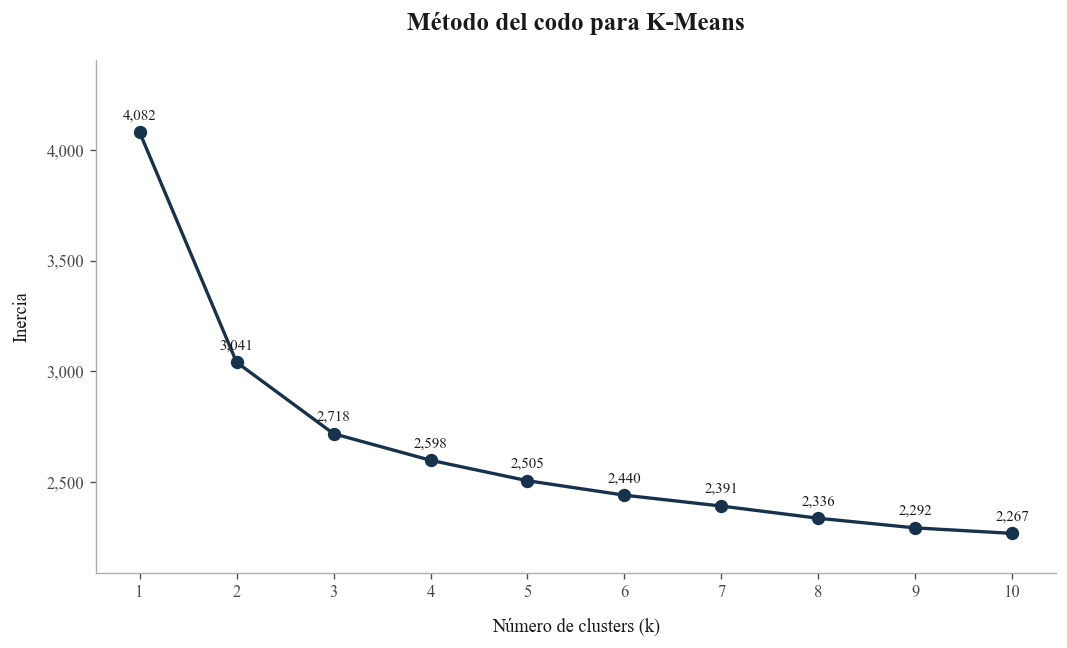

In [7]:
# Visualizamos la inercia obtenida para cada número de clusters
# con el propósito de construir el método del codo (Elbow Method)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters evaluado
# y en el eje vertical la inercia obtenida por K-Means.
ax.plot(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Método del codo para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Inercia",
    labelpad=10
)

# Indicamos explícitamente todos los valores de k evaluados
# para facilitar la lectura de la gráfica
ax.set_xticks(
    resultados_kmeans["Clusters"]
)

# Aplicamos separadores de miles al eje vertical
# para facilitar la lectura de los valores de inercia
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:,.0f}")
)

# Eliminamos los bordes que no aportan información
# para mantener el mismo estilo visual utilizado en el EDA
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el valor de la inercia junto a cada punto
# para mostrar con claridad el resultado obtenido para cada k
for k, inercia in zip(
    resultados_kmeans["Clusters"],
    resultados_kmeans["Inercia"]
):
    ax.text(
        k,
        inercia + 45,
        f"{inercia:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )

# Dejamos un pequeño espacio adicional en la parte superior
# para que las etiquetas no queden pegadas al límite de la figura
ax.set_ylim(
    resultados_kmeans["Inercia"].min() * 0.92,
    resultados_kmeans["Inercia"].max() * 1.08
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_metodo_codo"
)

# Mostramos la figura
plt.show()

**Interpretación del método del codo (K-Means)**

La gráfica muestra que la mayor reducción de la inercia ocurre al pasar de **1 a 2 clusters**, disminuyendo de 4,081.88 a 3,041.10. A partir de este punto, la reducción continúa, pero de manera considerablemente menor. Por ello, el método del codo sugiere que **2 clusters constituye una alternativa razonable**, ya que aumentar el número de grupos produce mejoras cada vez más pequeñas en la compactación de las empresas.

### Coeficiente de Silhouette

Como segundo criterio, se comparan los coeficientes de Silhouette obtenidos para las configuraciones de **k = 2 a k = 10**, con el propósito de evaluar la cohesión interna y la separación entre los grupos identificados.

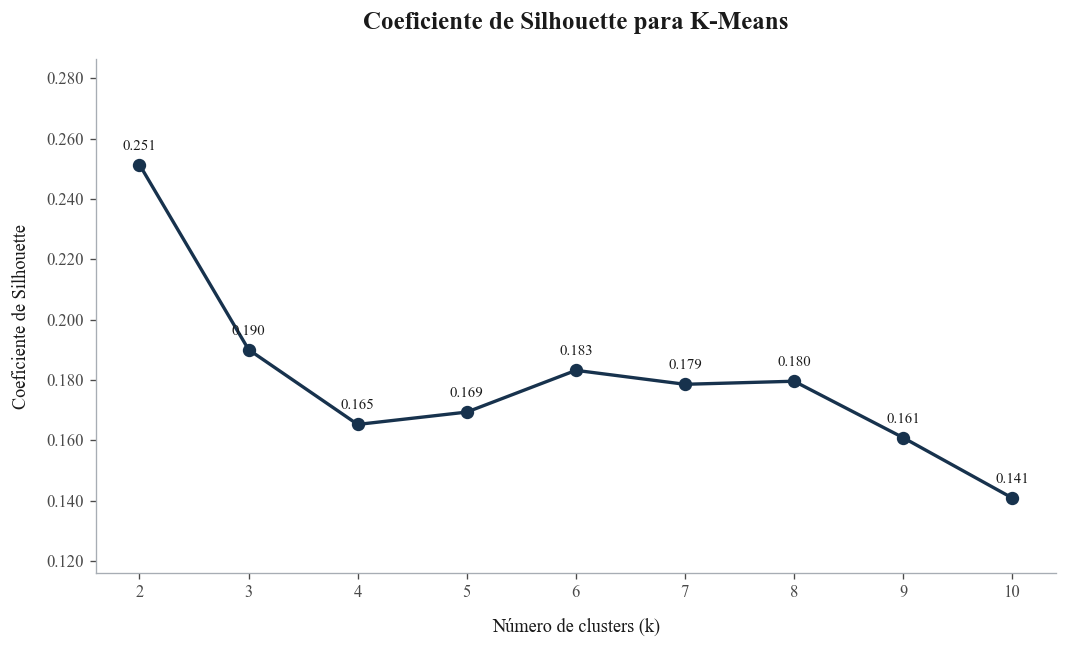

In [8]:
# Preparamos los resultados utilizados en la gráfica de Silhouette.
# Se excluye k = 1 porque el coeficiente requiere
# la existencia de al menos dos clusters.

resultados_silhouette = (
    resultados_kmeans
    .dropna(subset=["Silhouette"])
    .copy()
)

# Visualizamos el coeficiente de Silhouette obtenido
# para cada número de clusters evaluado

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea.
# En el eje horizontal se representa el número de clusters
# y en el eje vertical el coeficiente de Silhouette.
ax.plot(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Coeficiente de Silhouette para K-Means",
    pad=18
)

ax.set_xlabel(
    "Número de clusters (k)",
    labelpad=10
)

ax.set_ylabel(
    "Coeficiente de Silhouette",
    labelpad=10
)

# Indicamos explícitamente los valores de k evaluados
ax.set_xticks(
    resultados_silhouette["Clusters"]
)

# Mostramos tres decimales en el eje vertical
# para facilitar la comparación entre configuraciones
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:.3f}")
)

# Eliminamos los bordes que no aportan información
# manteniendo el mismo formato utilizado en las demás figuras
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el coeficiente obtenido junto a cada punto
# para mostrar con claridad las diferencias entre valores de k
for k, silhouette in zip(
    resultados_silhouette["Clusters"],
    resultados_silhouette["Silhouette"]
):
    ax.text(
        k,
        silhouette + 0.004,
        f"{silhouette:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )


# Dejamos un pequeño espacio adicional alrededor de los valores
# para evitar que las etiquetas queden pegadas a los límites
ax.set_ylim(
    resultados_silhouette["Silhouette"].min() - 0.025,
    resultados_silhouette["Silhouette"].max() + 0.035
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "kmeans_coeficiente_silhouette"
)

# Mostramos la figura
plt.show()

**Interpretación del coeficiente de Silhouette (K-Means)**

El coeficiente de Silhouette alcanza su valor más alto con **2 clusters (0.251)**. Para configuraciones con un mayor número de grupos, el coeficiente disminuye y no vuelve a alcanzar este nivel. Esto indica que, entre las configuraciones evaluadas, la solución con **2 clusters presenta la mejor combinación de cohesión interna y separación entre grupos**. Sin embargo, el valor obtenido se encuentra lejos del valor máximo de 1, por lo que no sugiere una separación completamente marcada entre los grupos.

**Configuraciones candidatas**

En conjunto, tanto el método del codo como el coeficiente de Silhouette señalan a **k = 2** como la configuración cuantitativamente más favorable entre las evaluadas. Sin embargo, la validación de un agrupamiento puede considerar **distintas características relevantes para el objetivo del análisis**, en lugar de depender exclusivamente de un único índice global de calidad (Hennig, 2017). Por ello, dado que el objetivo de este análisis también consiste en identificar perfiles de divulgación útiles e interpretables, se examinan adicionalmente las soluciones con **k = 3 y k = 4**.

Esta comparación permite evaluar si incorporar grupos adicionales revela perfiles de empresas que no son visibles con dos clusters, particularmente empresas con niveles muy bajos de divulgación.

### Comparación de las soluciones con 2, 3 y 4 clusters

Para complementar los criterios cuantitativos anteriores, se comparan las soluciones obtenidas con **2, 3 y 4 clusters**. Para cada configuración se revisa el número de empresas asignadas a cada grupo y su nivel general de divulgación.

In [9]:
# Comparamos las soluciones de K-Means con 2, 3 y 4 clusters
# para evaluar si un mayor número de grupos aporta perfiles
# adicionales que resulten útiles para la interpretación.

# Creamos una lista donde almacenaremos los resultados
comparacion_configuraciones = []

# Conservamos también los modelos y sus etiquetas
# para poder recuperarlos posteriormente si es necesario
modelos_configuraciones = {}
etiquetas_configuraciones = {}

# Evaluamos las tres configuraciones de interés
for k in [2, 3, 4]:

    # Ajustamos K-Means utilizando la misma configuración
    # empleada durante la evaluación anterior
    modelo = KMeans(
        n_clusters=k,
        random_state=SEMILLA,
        n_init=20
    )

    # Recuperamos el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Guardamos el modelo y las etiquetas
    modelos_configuraciones[k] = modelo
    etiquetas_configuraciones[k] = etiquetas

    # Calculamos el coeficiente de Silhouette
    silhouette = silhouette_score(
        X,
        etiquetas
    )

    # Calculamos el porcentaje general de divulgación
    # de cada empresa
    porcentaje_empresa = (
        X
        .mean(axis=1)
        .mul(100)
    )

    # Creamos una tabla auxiliar para resumir cada cluster
    resumen_auxiliar = pd.DataFrame({
        "Cluster": etiquetas,
        "Porcentaje_divulgacion": porcentaje_empresa.values
    })

    # Calculamos el tamaño y el nivel general
    # de divulgación de cada cluster
    resumen_auxiliar = (
        resumen_auxiliar
        .groupby(
            "Cluster",
            as_index=False
        )
        .agg(
            Empresas=(
                "Porcentaje_divulgacion",
                "size"
            ),
            Promedio_divulgacion=(
                "Porcentaje_divulgacion",
                "mean"
            ),
            Mediana_divulgacion=(
                "Porcentaje_divulgacion",
                "median"
            ),
            Minimo_divulgacion=(
                "Porcentaje_divulgacion",
                "min"
            ),
            Maximo_divulgacion=(
                "Porcentaje_divulgacion",
                "max"
            )
        )
    )

    # Incorporamos el número de clusters evaluado
    # y su coeficiente de Silhouette
    resumen_auxiliar.insert(
        0,
        "k",
        k
    )

    resumen_auxiliar[
        "Silhouette"
    ] = silhouette

    # Guardamos el resultado
    comparacion_configuraciones.append(
        resumen_auxiliar
    )

# Unimos los resultados de las tres configuraciones
comparacion_configuraciones = pd.concat(
    comparacion_configuraciones,
    ignore_index=True
)

# Redondeamos los valores para facilitar su lectura
columnas_redondear = [
    "Promedio_divulgacion",
    "Mediana_divulgacion",
    "Minimo_divulgacion",
    "Maximo_divulgacion",
    "Silhouette"
]

comparacion_configuraciones[
    columnas_redondear
] = (
    comparacion_configuraciones[
        columnas_redondear
    ]
    .round(3)
)

# Mostramos la comparación
display(
    comparacion_configuraciones
)

,k,Cluster,Empresas,Promedio_divulgacion,Mediana_divulgacion,Minimo_divulgacion,Maximo_divulgacion,Silhouette
0,2,0,108,44.512,40.826,25.688,80.734,0.251
1,2,1,142,10.815,9.174,0.000,28.440,0.251
2,3,0,91,5.232,4.587,0.000,15.596,0.190
3,3,1,52,55.928,52.294,38.532,80.734,0.190
4,3,2,107,27.652,26.606,14.679,45.872,0.190
5,4,0,76,22.767,22.018,11.927,35.780,0.165
6,4,1,87,4.809,3.670,0.000,13.761,0.165
7,4,2,31,62.208,65.138,46.789,80.734,0.165
8,4,3,56,40.465,38.991,29.358,50.459,0.165


La comparación muestra una **gradación clara en el nivel general de divulgación** dentro de las tres configuraciones evaluadas. Con **k = 2** se identifican dos grupos amplios, con promedios de **10.82% y 44.51%**. Al utilizar **k = 3**, la separación se vuelve más detallada y permite distinguir un perfil de **muy baja divulgación** (5.23%, 91 empresas), uno de **divulgación intermedia** (27.65%, 107 empresas) y uno de **mayor divulgación** (55.93%, 52 empresas).

Con **k = 4**, el nivel general de divulgación se subdivide en cuatro grupos, con promedios de **4.81%, 22.77%, 40.47% y 62.21%**. Esta configuración ofrece una segmentación todavía más detallada del mismo gradiente general de divulgación.

Aunque **k = 2 presenta el coeficiente de Silhouette más alto (0.251)**, seguido de **k = 3 (0.190)** y **k = 4 (0.165)**, la solución con **k = 3** aporta una segmentación más detallada al identificar específicamente un grupo de empresas con niveles muy bajos de divulgación. Por esta razón, **k = 3 se conserva como solución candidata para continuar evaluando su estabilidad y utilidad interpretativa**.

### Evaluación de la estabilidad de K-Means

Una vez seleccionado **k = 3** como solución candidata para continuar el análisis, se evalúa su estabilidad ante distintas inicializaciones del algoritmo. K-Means puede producir resultados diferentes dependiendo de la posición inicial de los centroides, por lo que se repite el agrupamiento utilizando distintas semillas aleatorias.

Para comparar las asignaciones obtenidas se utiliza el **Adjusted Rand Index (ARI)**, una medida de similitud entre dos particiones que evalúa el grado de coincidencia entre sus agrupamientos y ajusta dicha coincidencia por aquella que podría esperarse por azar (Romano et al., 2016). Valores cercanos a 1 indican una correspondencia muy alta entre ambas soluciones, independientemente de las etiquetas numéricas utilizadas para identificar los clusters.

La solución obtenida con la semilla definida para el análisis se utiliza como referencia y se compara con los resultados generados mediante distintas semillas.

In [10]:
# Evaluamos la estabilidad de la solución candidata de K-Means
# utilizando distintas semillas aleatorias

# Definimos el número de clusters seleccionado como candidato
# a partir de la comparación cuantitativa e interpretativa
K_CANDIDATO = 3

# Construimos primero una solución de referencia utilizando
# la semilla definida al inicio del notebook
modelo_referencia = KMeans(

    # Utilizamos k = 3 como número de clusters candidato
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija del análisis
    random_state=SEMILLA,

    # Ejecutamos K-Means 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo de referencia a los 109 indicadores
# y recuperamos el cluster asignado a cada empresa
etiquetas_referencia = modelo_referencia.fit_predict(X)

# Definimos distintas semillas para comprobar si la estructura
# de los grupos cambia ante diferentes inicializaciones
semillas_estabilidad = [
    1, 5, 10, 15, 20,
    25, 30, 35, 40, 45
]

# Creamos una lista vacía donde almacenaremos
# el resultado correspondiente a cada semilla
resultados_estabilidad = []

# Repetimos K-Means utilizando cada una de las semillas definidas
for semilla in semillas_estabilidad:

    # Construimos un nuevo modelo manteniendo exactamente
    # k = 3 y modificando únicamente la semilla aleatoria
    modelo = KMeans(

        # Mantenemos fijo el número de clusters candidato
        n_clusters=K_CANDIDATO,

        # Cambiamos la semilla en cada repetición
        random_state=semilla,

        # Mantenemos el mismo número de inicializaciones
        # utilizado durante la evaluación anterior
        n_init=20
    )

    # Ajustamos el modelo y recuperamos el cluster
    # asignado a cada una de las 250 empresas
    etiquetas = modelo.fit_predict(X)

    # Calculamos el Adjusted Rand Index (ARI) comparando
    # esta solución con la solución de referencia
    # Un valor cercano a 1 indica que ambas soluciones
    # agrupan a las empresas prácticamente de la misma manera.
    ari = adjusted_rand_score(
        etiquetas_referencia,
        etiquetas
    )

    # Guardamos la semilla utilizada y el nivel
    # de coincidencia obtenido respecto a la referencia
    resultados_estabilidad.append({
        "Semilla": semilla,
        "ARI": ari
    })

# Convertimos los resultados en un DataFrame
# para facilitar su revisión
resultados_estabilidad = pd.DataFrame(
    resultados_estabilidad
)

# Mostramos los resultados de la evaluación de estabilidad
display(resultados_estabilidad)

,Semilla,ARI
0,1,0.973
1,5,1.000
2,10,0.973
3,15,1.000
4,20,1.000
5,25,1.000
6,30,1.000
7,35,1.000
8,40,1.000
9,45,1.000


Los valores del **Adjusted Rand Index (ARI)** se encuentran entre **0.973 y 1.000**, lo que indica un nivel muy alto de coincidencia entre las agrupaciones obtenidas con distintas semillas. En **8 de las 10 semillas evaluadas** se reprodujo exactamente la solución de referencia (**ARI = 1.000**), mientras que las dos restantes alcanzaron un valor de **0.973**. Estos resultados muestran que la solución de **K-Means con k = 3 es estable ante diferentes inicializaciones del algoritmo**, por lo que la formación de los tres grupos no depende de manera importante de la semilla utilizada.

### Recuperación de la solución candidata de K-Means

Después de seleccionar **k = 3** como número de clusters candidato y comprobar que la solución es estable ante distintas inicializaciones, se ajusta nuevamente K-Means utilizando la semilla definida para el análisis.

El objetivo de esta etapa es recuperar la asignación correspondiente a la solución candidata de K-Means y conservarla junto con la información descriptiva de las empresas para realizar posteriormente la interpretación de los perfiles identificados.

In [11]:
# Ajustamos nuevamente K-Means utilizando
# la configuración candidata seleccionada

# Construimos la solución candidata de K-Means
# con tres clusters
modelo_kmeans_candidato = KMeans(

    # Utilizamos el número de clusters candidato
    n_clusters=K_CANDIDATO,

    # Utilizamos la semilla fija definida
    # al inicio del notebook
    random_state=SEMILLA,

    # Ejecutamos el algoritmo 20 veces con diferentes
    # inicializaciones y conservamos la mejor solución
    n_init=20
)

# Ajustamos el modelo a los 109 indicadores binarios
# y recuperamos el cluster asignado a cada empresa
clusters_kmeans = modelo_kmeans_candidato.fit_predict(X)

# Creamos una copia de la información descriptiva
# de las empresas para conservar sus nombres y país de sede
resultado_kmeans = informacion_empresas.copy()

# Incorporamos el cluster asignado por K-Means
# a cada una de las 250 empresas
resultado_kmeans["Cluster_KMeans"] = clusters_kmeans

# Mostramos las primeras observaciones para verificar
# que la asignación se haya incorporado correctamente
display(
    resultado_kmeans.head()
)

,Company,Pais_sede,Cluster_KMeans
0,AJIO,India,0
1,ALDO,Canadá,2
2,Abercrombie & Fitch,Estados Unidos,2
3,Adidas AG,Alemania,1
4,Aeropostale Inc.,Estados Unidos,0


In [12]:
# Revisamos el número de empresas asignadas
# a cada uno de los clusters identificados

distribucion_clusters_kmeans = (
    resultado_kmeans["Cluster_KMeans"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Empresas")
)

display(
    distribucion_clusters_kmeans
)

,Cluster,Empresas
0,0,91
1,1,52
2,2,107


In [13]:
# Exportamos la asignación de clusters obtenida
# para conservarla y utilizarla posteriormente
# durante la interpretación de los perfiles.

resultado_kmeans.to_csv(
    ruta_datos / "resultado_kmeans_clusters.csv",
    index=False
)

print(
    "Resultado de K-Means exportado correctamente."
)

Resultado de K-Means exportado correctamente.


### Interpretación de los perfiles obtenidos con K-Means

Una vez recuperada la asignación de las empresas a los tres clusters, se analizan las características de cada grupo con el propósito de identificar los patrones de divulgación que los distinguen. La interpretación se realiza en distintos niveles: primero se compara el nivel general de divulgación y el tamaño de los grupos; posteriormente se analizan las diferencias entre las categorías **Environment, Social y Governance** y, finalmente, se identifican los indicadores que presentan las mayores diferencias entre los clusters. A partir de estos resultados se construye una descripción general de cada perfil de transparencia.

**Distribución y nivel general de divulgación**

In [14]:
# Calculamos el porcentaje general de divulgación de cada empresa

# Como los 109 indicadores están codificados como 0 y 1,
# la media de cada fila representa la proporción de indicadores
# para los que cada empresa divulga información.

porcentaje_divulgacion_empresa = (
    X
    .mean(axis=1)
    .mul(100)
)

# Creamos una copia de la tabla que contiene
# la empresa, su país de sede y el cluster asignado
analisis_perfiles_kmeans = resultado_kmeans.copy()

# Incorporamos el porcentaje general de divulgación
# correspondiente a cada empresa.
analisis_perfiles_kmeans["Porcentaje_divulgacion"] = (
    porcentaje_divulgacion_empresa.values
)

# Calculamos el promedio de divulgación dentro de cada cluster
# y el número de empresas que lo componen
resumen_general_clusters = (
    analisis_perfiles_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False
    )
    .agg(
        Empresas=("Company", "nunique"),
        Porcentaje_promedio_divulgacion=(
            "Porcentaje_divulgacion",
            "mean"
        )
    )
)

# Redondeamos el porcentaje para facilitar su lectura
resumen_general_clusters[
    "Porcentaje_promedio_divulgacion"
] = (
    resumen_general_clusters[
        "Porcentaje_promedio_divulgacion"
    ]
    .round(2)
)

# Mostramos el resultado.
display(resumen_general_clusters)

,Cluster_KMeans,Empresas,Porcentaje_promedio_divulgacion
0,0,91,5.230
1,1,52,55.930
2,2,107,27.650


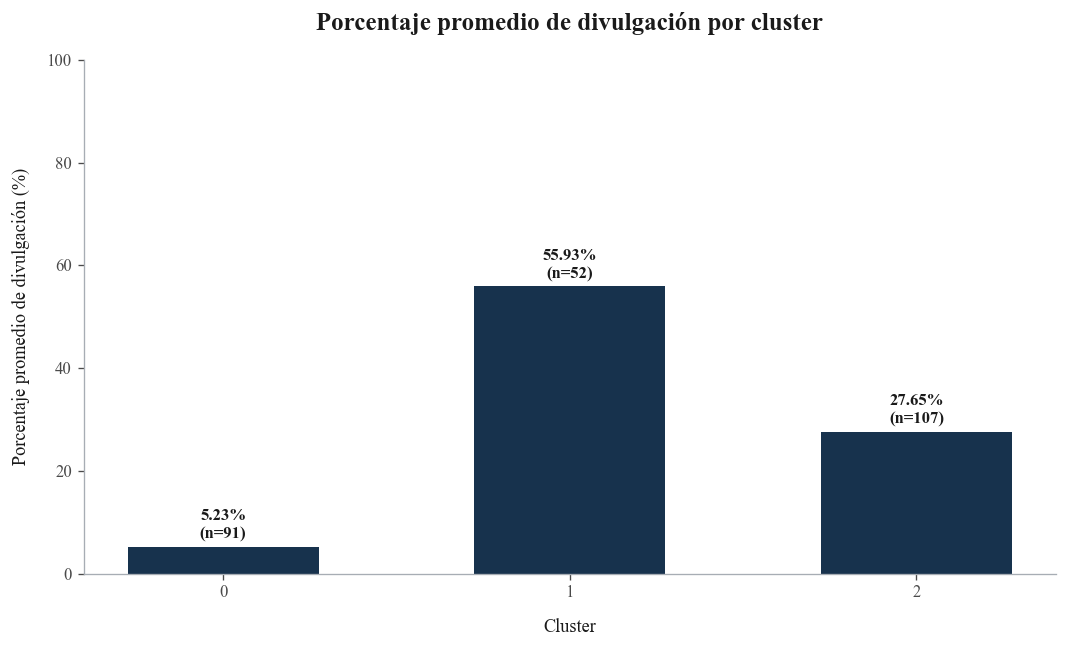

In [15]:
# Visualizamos el porcentaje promedio general de divulgación
# correspondiente a cada cluster identificado por K-Means

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos una gráfica de barras donde cada barra
# representa uno de los tres clusters identificados
barras = ax.bar(
    resumen_general_clusters["Cluster_KMeans"].astype(str),
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    color=AZUL_MARINO,
    width=0.55
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por cluster",
    pad=18
)

ax.set_xlabel(
    "Cluster",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
# para conservar el mismo formato visual utilizado
# en las figuras anteriores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos sobre cada barra el porcentaje promedio
# y el número de empresas que componen el cluster
for barra, porcentaje, empresas in zip(
    barras,
    resumen_general_clusters["Porcentaje_promedio_divulgacion"],
    resumen_general_clusters["Empresas"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{porcentaje:.2f}%\n(n={empresas})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Establecemos el eje vertical entre 0 y 100,
# ya que se representa un porcentaje de divulgación
ax.set_ylim(0, 100)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_divulgacion_promedio_clusters"
)

# Mostramos la figura
plt.show()

Los números asignados a los clusters funcionan únicamente como etiquetas y no representan un orden en el nivel de divulgación. De acuerdo con sus resultados, el **Cluster 0**, integrado por **91 empresas**, presenta el nivel promedio más bajo de divulgación, con **5.23%**. El **Cluster 2**, compuesto por **107 empresas**, registra un nivel intermedio de **27.65%**, mientras que el **Cluster 1**, con **52 empresas**, presenta el nivel más alto, con **55.93%**.

Por lo tanto, la solución con tres clusters permite distinguir tres perfiles generales de transparencia: **muy baja divulgación, divulgación intermedia y mayor divulgación**. A continuación, se analiza si esta gradación también se observa en las categorías **Environment, Social y Governance**.

**Perfil de divulgación por categoría temática**

Para comprender con mayor detalle las diferencias entre los perfiles identificados, se compara el porcentaje promedio de divulgación de cada cluster en las categorías **Environment, Social y Governance**. Este análisis permite determinar si la separación observada entre los grupos responde únicamente a una diferencia general en el nivel de divulgación o si existen patrones distintos entre las categorías temáticas.

In [16]:
# Cargamos el diccionario de indicadores para recuperar
# la categoría temática correspondiente a cada variable

diccionario_indicadores = pd.read_excel(
    ruta_datos / "diccionario_indicadores.xlsx"
)

# Conservamos únicamente la información necesaria:
# el nombre original del indicador y su categoría temática
categorias_indicadores = (
    diccionario_indicadores[
        ["Indicador original", "Categoría temática"]
    ]
    .drop_duplicates()
)

# Creamos un diccionario que relaciona cada indicador
# con su categoría temática
mapa_categorias = dict(
    zip(
        categorias_indicadores["Indicador original"],
        categorias_indicadores["Categoría temática"]
    )
)

# Verificamos que todos los indicadores utilizados en X
# tengan una categoría temática asignada
indicadores_sin_categoria = [
    indicador
    for indicador in X.columns
    if indicador not in mapa_categorias
]

print(
    "Indicadores sin categoría temática:",
    len(indicadores_sin_categoria)
)

# Creamos una copia de la matriz de indicadores
# e incorporamos el cluster asignado a cada empresa
X_clusters = X.copy()

X_clusters["Cluster_KMeans"] = clusters_kmeans

# Transformamos la matriz de formato ancho a formato largo
# De esta manera, cada fila representa la combinación:
# empresa - indicador - cluster
X_largo = (
    X_clusters
    .reset_index()
    .melt(
        id_vars=["index", "Cluster_KMeans"],
        var_name="Indicador",
        value_name="Divulga"
    )
)

# Incorporamos la categoría temática correspondiente
# a cada indicador
X_largo["Categoria"] = (
    X_largo["Indicador"]
    .map(mapa_categorias)
)

# Conservamos únicamente las tres categorías utilizadas
# para la interpretación de los perfiles
X_largo_esg = X_largo[
    X_largo["Categoria"].isin(
        ["Environment", "Social", "Governance"]
    )
].copy()

# Calculamos el porcentaje promedio de divulgación
# de cada cluster dentro de cada categoría temática
perfil_categorias_kmeans = (
    X_largo_esg
    .groupby(
        ["Cluster_KMeans", "Categoria"],
        as_index=False
    )
    ["Divulga"]
    .mean()
)

# Convertimos las proporciones a porcentajes
perfil_categorias_kmeans[
    "Porcentaje_divulgacion"
] = (
    perfil_categorias_kmeans["Divulga"]
    .mul(100)
    .round(2)
)

# Conservamos únicamente las columnas necesarias
# para presentar los resultados
perfil_categorias_kmeans = (
    perfil_categorias_kmeans[
        [
            "Cluster_KMeans",
            "Categoria",
            "Porcentaje_divulgacion"
        ]
    ]
)

# Mostramos los resultados
display(perfil_categorias_kmeans)

Indicadores sin categoría temática: 0


,Cluster_KMeans,Categoria,Porcentaje_divulgacion
0,0,Environment,3.510
1,0,Governance,8.130
2,0,Social,5.490
3,1,Environment,58.860
4,1,Governance,60.000
5,1,Social,51.720
6,2,Environment,29.020
7,2,Governance,35.000
8,2,Social,23.420


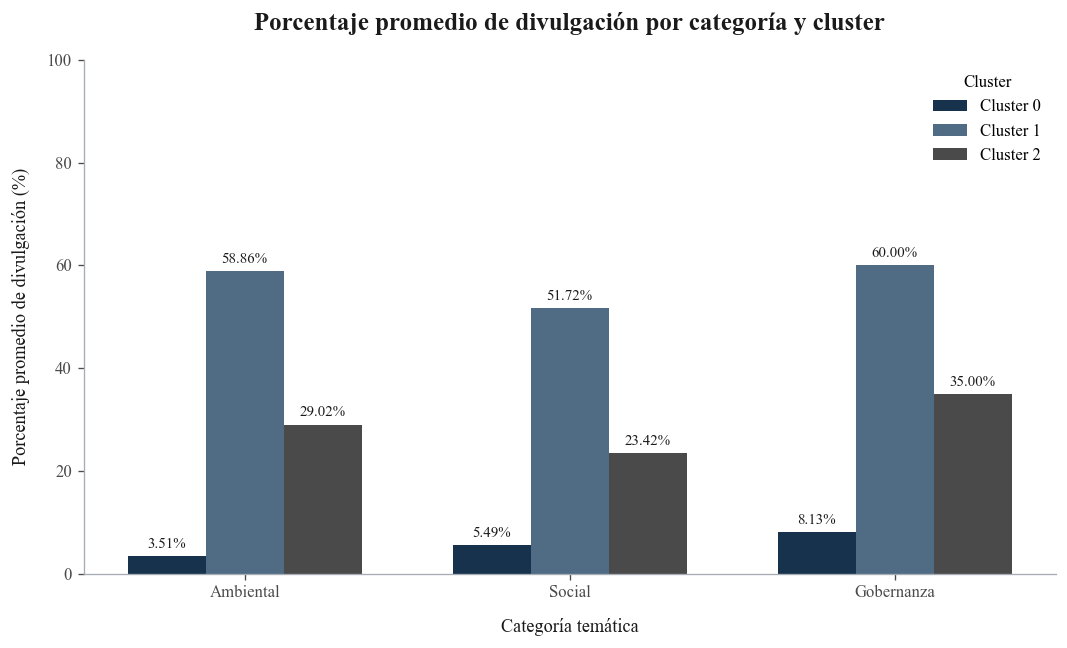

In [17]:
# Visualizamos el porcentaje promedio de divulgación
# de cada cluster por categoría temática

# Reorganizamos la tabla para facilitar la construcción
# de una gráfica de barras agrupadas
perfil_grafica = (
    perfil_categorias_kmeans
    .pivot(
        index="Categoria",
        columns="Cluster_KMeans",
        values="Porcentaje_divulgacion"
    )
    .loc[
        ["Environment", "Social", "Governance"]
    ]
)

# Definimos las posiciones de las categorías
posiciones = np.arange(
    len(perfil_grafica.index)
)

# Definimos el ancho de las barras
# para representar los tres clusters
ancho = 0.24

# Definimos los colores que utilizaremos
# para distinguir los tres grupos
colores_clusters = [
    AZUL_MARINO,
    AZUL_SECUNDARIO,
    GRIS_OSCURO
]

# Construimos la figura
fig, ax = plt.subplots(figsize=(9, 5.5))

# Calculamos las posiciones necesarias para centrar
# las tres barras alrededor de cada categoría
desplazamientos = [
    -ancho,
    0,
    ancho
]

# Guardamos los grupos de barras para poder
# incorporar posteriormente sus etiquetas
barras_clusters = []

# Graficamos los valores correspondientes
# a cada uno de los tres clusters
for cluster, desplazamiento, color in zip(
    [0, 1, 2],
    desplazamientos,
    colores_clusters
):
    barras = ax.bar(
        posiciones + desplazamiento,
        perfil_grafica[cluster],
        width=ancho,
        color=color,
        label=f"Cluster {cluster}"
    )

    barras_clusters.append(barras)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por categoría y cluster",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Incorporamos los nombres de las categorías
# utilizando su traducción al español
ax.set_xticks(posiciones)

ax.set_xticklabels(
    ["Ambiental", "Social", "Gobernanza"]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barras in barras_clusters:
    for barra in barras:
        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            color=NEGRO
        )

# Establecemos el eje vertical entre 0 y 100
# porque los valores representan porcentajes
ax.set_ylim(0, 100)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster"
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_perfil_categorias_clusters"
)

# Mostramos la figura
plt.show()

Los tres clusters mantienen diferencias importantes en el **nivel de divulgación** dentro de las categorías analizadas. El **Cluster 0**, correspondiente al perfil de muy baja divulgación, registra **8.13% en Gobernanza, 5.49% en Social y 3.51% en Ambiental**. El **Cluster 2**, identificado como el perfil intermedio, presenta **35.00% en Gobernanza, 29.02% en Ambiental y 23.42% en Social**. Finalmente, el **Cluster 1**, correspondiente al perfil de mayor divulgación, alcanza **60.00% en Gobernanza, 58.86% en Ambiental y 51.72% en Social**.

En los tres grupos, **Gobernanza presenta el porcentaje de divulgación más alto**. Además, los niveles del Cluster 0 permanecen bajos en las tres categorías, los del Cluster 2 ocupan una posición intermedia y los del Cluster 1 son consistentemente mayores. Por lo tanto, la comparación por categoría refuerza la interpretación de que K-Means distingue principalmente a las empresas por la **intensidad general de su divulgación**, más que por perfiles temáticos opuestos.

**Indicadores que más diferencian los perfiles**

Después de comparar los niveles generales y las categorías temáticas, se analizan los **109 indicadores individuales** utilizados en el agrupamiento. Para cada indicador se compara el porcentaje de divulgación de los tres clusters y se calcula la diferencia entre el grupo con el porcentaje más alto y el grupo con el porcentaje más bajo. De esta manera, se identifican los indicadores en los que los perfiles presentan las mayores diferencias.

In [18]:
# Calculamos el porcentaje de divulgación de cada indicador
# dentro de los tres clusters identificados por K-Means

# Creamos una copia de la matriz de indicadores
# para incorporar la asignación de cluster de cada empresa
perfil_indicadores_kmeans = X.copy()

# Añadimos el cluster correspondiente a cada empresa
perfil_indicadores_kmeans["Cluster_KMeans"] = (
    clusters_kmeans
)

# Calculamos la media de cada indicador dentro de cada cluster
# Debido a que los indicadores están codificados como 0 y 1,
# la media representa la proporción de empresas del cluster
# que divulga la información correspondiente
promedio_indicadores_cluster = (
    perfil_indicadores_kmeans
    .groupby("Cluster_KMeans")
    .mean()
    .T
    .mul(100)
    .reset_index()
)

# Renombramos las columnas para facilitar su interpretación
promedio_indicadores_cluster.columns = [
    "Indicador",
    "Cluster_0",
    "Cluster_1",
    "Cluster_2"
]

# Incorporamos la categoría temática correspondiente
promedio_indicadores_cluster["Categoria"] = (
    promedio_indicadores_cluster["Indicador"]
    .map(mapa_categorias)
)

# Definimos las columnas correspondientes
# a los porcentajes de los tres clusters
columnas_clusters = [
    "Cluster_0",
    "Cluster_1",
    "Cluster_2"
]

# Identificamos, para cada indicador, el porcentaje
# de divulgación más alto y el más bajo
promedio_indicadores_cluster[
    "Porcentaje_maximo"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .max(axis=1)
)

promedio_indicadores_cluster[
    "Porcentaje_minimo"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .min(axis=1)
)

# Calculamos la mayor diferencia observada
# entre los tres clusters para cada indicador
promedio_indicadores_cluster[
    "Diferencia_max_min_pp"
] = (
    promedio_indicadores_cluster[
        "Porcentaje_maximo"
    ]
    -
    promedio_indicadores_cluster[
        "Porcentaje_minimo"
    ]
)

# Identificamos qué cluster presenta
# el porcentaje máximo y cuál el mínimo
promedio_indicadores_cluster[
    "Cluster_mayor"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .idxmax(axis=1)
)

promedio_indicadores_cluster[
    "Cluster_menor"
] = (
    promedio_indicadores_cluster[
        columnas_clusters
    ]
    .idxmin(axis=1)
)

# Ordenamos los indicadores desde la mayor
# hasta la menor diferencia entre perfiles
promedio_indicadores_cluster = (
    promedio_indicadores_cluster
    .sort_values(
        "Diferencia_max_min_pp",
        ascending=False
    )
    .reset_index(drop=True)
)

# Redondeamos los porcentajes y las diferencias
# para facilitar la presentación de los resultados
columnas_redondear = [
    "Cluster_0",
    "Cluster_1",
    "Cluster_2",
    "Porcentaje_maximo",
    "Porcentaje_minimo",
    "Diferencia_max_min_pp"
]

promedio_indicadores_cluster[
    columnas_redondear
] = (
    promedio_indicadores_cluster[
        columnas_redondear
    ]
    .round(2)
)

# Conservamos los diez indicadores
# con mayor diferencia entre los perfiles
top_10_diferencias_kmeans = (
    promedio_indicadores_cluster
    .head(10)
    .copy()
)

# Mostramos los resultados
display(
    top_10_diferencias_kmeans[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Diferencia_max_min_pp",
            "Cluster_mayor",
            "Cluster_menor"
        ]
    ]
)

,Indicador,Categoria,Cluster_0,Cluster_1,Cluster_2,Diferencia_max_min_pp,Cluster_mayor,Cluster_menor
0,Fashion Revolution+Describes Environmental Due...,Environment,2.200,100.000,64.490,97.800,Cluster_1,Cluster_0
1,Fashion Revolution+Discloses Progress on Susta...,Environment,3.300,98.080,48.600,94.780,Cluster_1,Cluster_0
2,"Fashion Revolution+Scope, Process and Accredit...",Environment,5.490,98.080,49.530,92.580,Cluster_1,Cluster_0
3,Fashion Revolution+Prevention Mitigation and R...,Social,0.000,92.310,36.450,92.310,Cluster_1,Cluster_0
4,Fashion Revolution+Human Rights Risks Impacts ...,Social,5.490,96.150,71.030,90.660,Cluster_1,Cluster_0
5,Fashion Revolution+Sustainable Materials Strategy,Environment,9.890,100.000,62.620,90.110,Cluster_1,Cluster_0
6,Fashion Revolution+Environmental Risks Impacts...,Governance,1.100,90.380,42.060,89.290,Cluster_1,Cluster_0
7,Fashion Revolution+Discloses Progress to Reduc...,Environment,0.000,88.460,19.630,88.460,Cluster_1,Cluster_0
8,Fashion Revolution+Reports on Efforts to Impro...,Social,2.200,90.380,47.660,88.190,Cluster_1,Cluster_0
9,Fashion Revolution+Discloses Approach to Recru...,Social,4.400,92.310,47.660,87.910,Cluster_1,Cluster_0


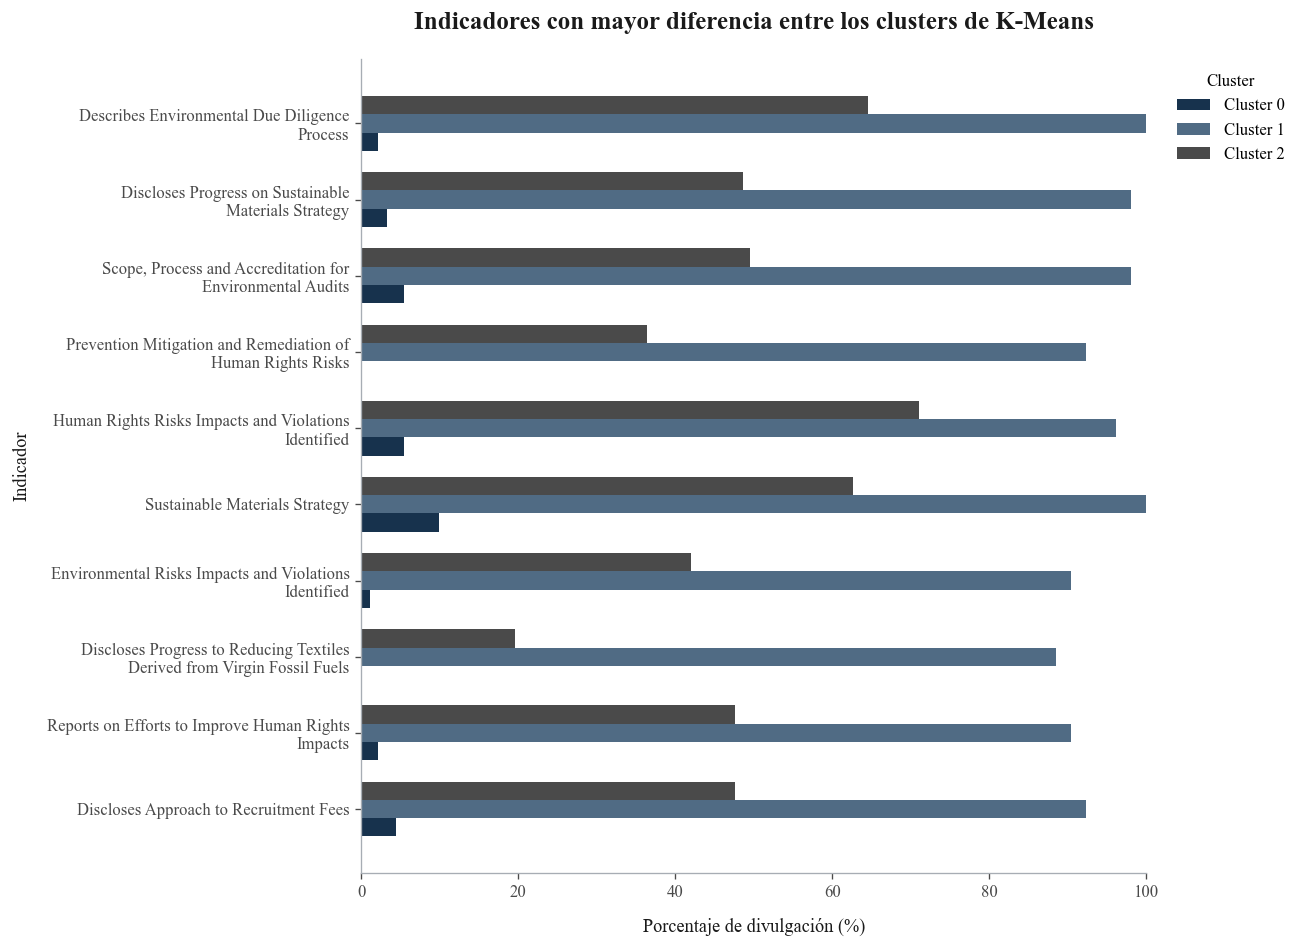

In [19]:
# Visualizamos los diez indicadores con mayor diferencia
# entre los tres perfiles identificados por K-Means

# Creamos una copia para preparar la información
# que será utilizada únicamente en la figura
top_10_grafica_kmeans = (
    top_10_diferencias_kmeans
    .copy()
)

# Eliminamos el prefijo "Fashion Revolution+"
# para hacer más legibles los nombres de los indicadores
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador"]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Dividimos automáticamente los nombres largos
# en varias líneas para facilitar su lectura
top_10_grafica_kmeans["Indicador_visual"] = (
    top_10_grafica_kmeans["Indicador_visual"]
    .apply(
        lambda texto: textwrap.fill(
            texto,
            width=42
        )
    )
)

# Ordenamos los indicadores de acuerdo con la
# diferencia máxima observada entre los clusters
top_10_grafica_kmeans = (
    top_10_grafica_kmeans
    .sort_values(
        "Diferencia_max_min_pp",
        ascending=True
    )
    .reset_index(drop=True)
)

# Definimos las posiciones de los indicadores
posiciones = np.arange(
    len(top_10_grafica_kmeans)
)

# Definimos el alto de cada barra
alto = 0.24

# Construimos la figura
fig, ax = plt.subplots(
    figsize=(11, 8)
)

# Representamos el porcentaje de divulgación
# correspondiente a cada cluster
barras_0 = ax.barh(
    posiciones - alto,
    top_10_grafica_kmeans["Cluster_0"],
    height=alto,
    color=AZUL_MARINO,
    label="Cluster 0"
)

barras_1 = ax.barh(
    posiciones,
    top_10_grafica_kmeans["Cluster_1"],
    height=alto,
    color=AZUL_SECUNDARIO,
    label="Cluster 1"
)

barras_2 = ax.barh(
    posiciones + alto,
    top_10_grafica_kmeans["Cluster_2"],
    height=alto,
    color=GRIS_OSCURO,
    label="Cluster 2"
)

# Incorporamos los nombres de los indicadores
ax.set_yticks(posiciones)

ax.set_yticklabels(
    top_10_grafica_kmeans["Indicador_visual"]
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Indicadores con mayor diferencia entre los clusters de K-Means",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Establecemos el eje horizontal entre 0 y 100
ax.set_xlim(0, 100)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_top_10_diferencias_indicadores"
)

# Mostramos la figura
plt.show()

Los diez indicadores con mayores diferencias entre los perfiles presentan brechas de entre **87.91 y 97.80 puntos porcentuales** entre el cluster con mayor y menor divulgación. De estos indicadores, **cinco pertenecen a Environment, cuatro a Social y uno a Governance**, por lo que las diferencias más amplias se concentran principalmente en información ambiental y social.

Los indicadores que más separan a los perfiles son *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental), *Discloses Progress on Sustainable Materials Strategy* (divulga avances en la estrategia de materiales sostenibles), *Scope, Process and Accreditation for Environmental Audits* (alcance, proceso y acreditación de auditorías ambientales), *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos), *Human Rights Risks Impacts and Violations Identified* (riesgos, impactos y violaciones de derechos humanos identificados), *Sustainable Materials Strategy* (estrategia de materiales sostenibles), *Environmental Risks Impacts and Violations Identified* (riesgos, impactos y violaciones ambientales identificados), *Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels* (divulga avances en la reducción de textiles derivados de combustibles fósiles vírgenes), *Reports on Efforts to Improve Human Rights Impacts* (reporta esfuerzos para mejorar los impactos en derechos humanos) y *Discloses Approach to Recruitment Fees* (divulga su enfoque sobre tarifas de contratación).

En estos diez indicadores, el **Cluster 1**, correspondiente al perfil de mayor divulgación, presenta porcentajes de entre **88.46% y 100%**, mientras que el **Cluster 0**, correspondiente al perfil de muy baja divulgación, registra valores de entre **0% y 9.89%**. Por lo tanto, la diferencia entre ambos perfiles no se limita al porcentaje general de divulgación: las empresas del Cluster 1 publican con mucha mayor frecuencia información relacionada con **debida diligencia, auditorías, identificación de riesgos e impactos, estrategias, medidas de respuesta y seguimiento de avances**, mientras que esta información aparece de manera muy limitada entre las empresas del Cluster 0.

El **Cluster 2** muestra un comportamiento intermedio, pero no uniforme. Dentro de estos diez indicadores, sus porcentajes varían entre **19.63% y 71.03%**. Por ejemplo, alcanza **71.03%** en *Human Rights Risks Impacts and Violations Identified* (riesgos, impactos y violaciones de derechos humanos identificados), **64.49%** en *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental) y **62.62%** en *Sustainable Materials Strategy* (estrategia de materiales sostenibles). En contraste, registra **19.63%** en *Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels* (divulga avances en la reducción de textiles derivados de combustibles fósiles vírgenes) y **36.45%** en *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos). Esto permite caracterizar al perfil intermedio como un grupo que, al menos entre los indicadores que más diferencian a los clusters, presenta niveles relativamente altos en algunos procesos de identificación y debida diligencia, pero una divulgación menor en determinadas medidas y avances específicos.

In [20]:
# Verificamos si la gradación general observada entre los clusters
# también se mantiene al analizar los 109 indicadores individuales

# De acuerdo con los niveles generales identificados:
# Cluster 1 = mayor divulgación
# Cluster 2 = divulgación intermedia
# Cluster 0 = muy baja divulgación

promedio_indicadores_cluster[
    "Orden_esperado"
] = (
    (
        promedio_indicadores_cluster["Cluster_1"]
        >=
        promedio_indicadores_cluster["Cluster_2"]
    )
    &
    (
        promedio_indicadores_cluster["Cluster_2"]
        >=
        promedio_indicadores_cluster["Cluster_0"]
    )
)

# Contamos cuántos indicadores mantienen
# la gradación general entre los tres perfiles
indicadores_orden_esperado = (
    promedio_indicadores_cluster[
        "Orden_esperado"
    ]
    .sum()
)

indicadores_total = len(
    promedio_indicadores_cluster
)

print(
    "Indicadores que mantienen el orden "
    "Cluster 1 >= Cluster 2 >= Cluster 0:",
    indicadores_orden_esperado,
    "de",
    indicadores_total
)

# Identificamos los indicadores en los que
# la gradación general no se mantiene
indicadores_excepciones = (
    promedio_indicadores_cluster[
        ~promedio_indicadores_cluster[
            "Orden_esperado"
        ]
    ]
    .copy()
)

print(
    "Indicadores que no mantienen este orden:",
    len(indicadores_excepciones)
)

display(
    indicadores_excepciones[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
)

Indicadores que mantienen el orden Cluster 1 >= Cluster 2 >= Cluster 0: 106 de 109
Indicadores que no mantienen este orden: 3


,Indicador,Categoria,Cluster_0,Cluster_1,Cluster_2
69,Fashion Revolution+Publishes Gender-based Labo...,Social,1.100,36.540,0.000
88,Fashion Revolution+Publishes Racial Equality A...,Social,4.400,21.150,2.800
108,Fashion Revolution+Publishes Standard Supplier...,Governance,1.100,1.920,0.000


La gradación general entre los perfiles se mantiene en **106 de los 109 indicadores analizados**: el **Cluster 1** presenta el mayor porcentaje de divulgación, el **Cluster 2** ocupa una posición intermedia y el **Cluster 0** registra el menor porcentaje.

Solo **3 indicadores** no siguen exactamente este orden: *Publishes Gender-based Labour Violations Data* (publica datos sobre violaciones laborales relacionadas con el género), *Publishes Racial Equality Actions* (publica acciones de igualdad racial) y *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores). En estos casos, el Cluster 1 continúa presentando el porcentaje más alto, pero el Cluster 2 registra un valor ligeramente inferior al Cluster 0.

En conjunto, este resultado muestra que la separación obtenida mediante K-Means corresponde de manera muy consistente a tres niveles de divulgación: **muy baja, intermedia y mayor divulgación**, más que a perfiles temáticos opuestos.

**Indicadores con mayor y menor divulgación dentro de cada perfil**

Para caracterizar con mayor precisión los perfiles identificados, se analizan los indicadores que presentan los porcentajes de divulgación más altos y más bajos dentro de cada cluster. Este análisis permite identificar qué información se publica con mayor frecuencia entre las empresas de cada perfil y qué temas presentan una divulgación más limitada.

In [21]:
# Identificamos los indicadores con mayor y menor
# porcentaje de divulgación dentro de cada cluster

# Partimos de la tabla construida previamente,
# que contiene el porcentaje de divulgación
# de cada indicador en los tres clusters
columnas_perfiles = {
    0: "Cluster_0",
    1: "Cluster_1",
    2: "Cluster_2"
}

top_indicadores_por_cluster = {}
bottom_indicadores_por_cluster = {}

for cluster, columna in columnas_perfiles.items():

    # Diez indicadores con mayor porcentaje
    # de divulgación dentro del cluster
    top_indicadores_por_cluster[cluster] = (
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )

    # Diez indicadores con menor porcentaje
    # de divulgación dentro del cluster
    bottom_indicadores_por_cluster[cluster] = (
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=True
        )
        .head(10)
        .reset_index(drop=True)
    )

# Mostramos los resultados de cada perfil
for cluster in [0, 1, 2]:

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MAYOR DIVULGACIÓN"
    )

    display(
        top_indicadores_por_cluster[
            cluster
        ]
    )

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MENOR DIVULGACIÓN"
    )

    display(
        bottom_indicadores_por_cluster[
            cluster
        ]
    )


CLUSTER 0 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+Supply Chain Policies Are C...,Governance,42.860
1,Fashion Revolution+Grievance Mechanism - Direc...,Social,38.460
2,Fashion Revolution+Supply Chain Policies Align...,Governance,37.360
3,Fashion Revolution+New Production Facility Cri...,Social,34.070
4,Fashion Revolution+Grievance Mechanism - Suppl...,Social,26.370
5,Fashion Revolution+Remediation Process,Social,26.370
6,Fashion Revolution+Plan for Improving Environm...,Environment,26.370
7,Fashion Revolution+Implementation of Board Lev...,Governance,25.270
8,Fashion Revolution+Describes Human Rights Due ...,Social,23.080
9,Fashion Revolution+Accountable Board Member Id...,Governance,16.480



CLUSTER 0 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+Percentage of Audits includ...,Social,0.000
1,Fashion Revolution+Stakeholder Engagement in E...,Social,0.000
2,Fashion Revolution+Zero Deforestation Progress,Environment,0.000
3,Fashion Revolution+Discloses % of Circular Pro...,Environment,0.000
4,Fashion Revolution+Discloses Breakdown of Reus...,Environment,0.000
5,Fashion Revolution+Number or % of off-site wor...,Social,0.000
6,Fashion Revolution+Human Rights Risk Preventio...,Social,0.000
7,Fashion Revolution+Discloses Water-Related Ris...,Environment,0.000
8,Fashion Revolution+Protects Labour Costs in Pr...,Social,0.000
9,Fashion Revolution+Executive Pay Linked to Env...,Governance,0.000



CLUSTER 1 - INDICADORES CON MAYOR DIVULGACIÓN


...

,Indicador,Categoria,Cluster_1
0,Fashion Revolution+Publishes Standard Supplier...,Governance,1.920
1,Fashion Revolution+Commitment to Degrowth,Environment,1.920
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,1.920
3,Fashion Revolution+Discloses Progress toward t...,Social,3.850
4,Fashion Revolution+Publishes Percentage or Num...,Social,3.850
5,Fashion Revolution+Discloses Free on Board (FO...,Governance,3.850
6,Fashion Revolution+Discloses Strategy to Achie...,Social,5.770
7,Fashion Revolution+Discloses Number of Collect...,Social,5.770
8,Fashion Revolution+Discloses Percentage of Wor...,Environment,7.690
9,Fashion Revolution+Reports on Minimum Wage Pai...,Social,7.690



CLUSTER 2 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_2
0,Fashion Revolution+Plan for Improving Environm...,Environment,96.260
1,Fashion Revolution+Supply Chain Policies Align...,Governance,95.330
2,Fashion Revolution+Describes Human Rights Due ...,Social,89.720
3,Fashion Revolution+Implementation of Board Lev...,Governance,85.980
4,Fashion Revolution+Supply Chain Policies Are C...,Governance,85.980
5,Fashion Revolution+Discloses Content of Scope ...,Environment,84.110
6,Fashion Revolution+Reports on Efforts to Impro...,Environment,83.180
7,Fashion Revolution+Grievance Mechanism - Direc...,Social,79.440
8,Fashion Revolution+Accountable Board Member Id...,Governance,77.570
9,Fashion Revolution+Grievance Mechanism - Suppl...,Social,76.640



CLUSTER 2 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_2
0,Fashion Revolution+Publishes Standard Supplier...,Governance,0.000
1,Fashion Revolution+Publishes Gender-based Labo...,Social,0.000
2,Fashion Revolution+Discloses Number of Collect...,Social,0.000
3,Fashion Revolution+Discloses Percentage of Wor...,Environment,0.000
4,Fashion Revolution+Reports on Minimum Wage Pai...,Social,0.000
5,Fashion Revolution+Discloses Quantity of Order...,Social,0.000
6,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,0.930
7,Fashion Revolution+Publishes Percentage or Num...,Social,0.930
8,Fashion Revolution+Number or % of off-site wor...,Social,0.930
9,Fashion Revolution+Commitment to Degrowth,Environment,0.930


El análisis de los indicadores con mayor y menor divulgación permite precisar qué caracteriza a las empresas pertenecientes a cada perfil. Las diferencias no se limitan al porcentaje promedio general, sino también a **qué tipo de información aparece con mayor frecuencia y qué información permanece prácticamente ausente dentro de cada grupo**.

En el **Cluster 0**, correspondiente al perfil de muy baja divulgación, incluso los indicadores más frecuentes presentan porcentajes relativamente limitados. El valor más alto corresponde a *Supply Chain Policies Are Contractual* (las políticas de la cadena de suministro forman parte de los contratos con proveedores), con **42.86%**, seguido de *Grievance Mechanism – Direct Employees* (mecanismo de quejas para empleados directos), con **38.46%**, y *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), con **37.36%**. También aparecen entre los indicadores más divulgados *New Production Facility Criteria* (criterios para nuevas instalaciones de producción), *Grievance Mechanism – Supply Chain Workers* (mecanismo de quejas para trabajadores de la cadena de suministro), *Remediation Process* (proceso de remediación) y *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos).

Este resultado muestra que el perfil de muy baja divulgación **no implica ausencia absoluta de información**. Cuando estas empresas divulgan, la información se concentra principalmente en determinadas políticas, responsabilidades y mecanismos formales. Sin embargo, **ninguno de sus diez indicadores más frecuentes alcanza siquiera el 50% de las empresas del cluster**, y sus diez indicadores con menor divulgación registran **0%**. Por lo tanto, la característica principal de este perfil es una divulgación reducida y selectiva, con numerosos temas completamente ausentes.

El **Cluster 1**, correspondiente al perfil de mayor divulgación, presenta una estructura claramente distinta. Siete de sus diez indicadores más frecuentes alcanzan **100% de divulgación**, incluyendo *Describes Environmental Due Diligence Process* (describe el proceso de debida diligencia ambiental), *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), *Sustainable Materials Strategy* (estrategia de materiales sostenibles), *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos), *New Production Facility Criteria* (criterios para nuevas instalaciones de producción), *Plan for Improving Environmental Impacts* (plan para mejorar los impactos ambientales) y *Reports on Efforts to Improve Environmental Impacts* (reporta esfuerzos para mejorar los impactos ambientales). Los tres restantes alcanzan **98.08%**.

Sin embargo, pertenecer al perfil de mayor divulgación **no significa divulgar ampliamente todos los temas**. Sus diez indicadores menos frecuentes registran apenas entre **1.92% y 7.69%**. Entre ellos se encuentran *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores), *Discloses Policy on Up-Front Supplier Payments* (divulga una política sobre pagos anticipados a proveedores), *Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain* (divulga avances hacia el pago de un salario digno a trabajadores de la cadena de suministro), *Publishes Percentage or Number of Workers Earning a Living Wage* (publica el porcentaje o número de trabajadores que reciben un salario digno), *Discloses Strategy to Achieving Living Wage* (divulga una estrategia para alcanzar un salario digno) y *Reports on Minimum Wage Paid for Daily / Piece Rate Workers* (reporta el salario mínimo pagado a trabajadores por día o por pieza).

Este resultado es relevante porque muestra que existen **vacíos de divulgación incluso entre las empresas pertenecientes al perfil de mayor transparencia**. En particular, determinados temas relacionados con salarios, condiciones específicas de remuneración, prácticas de compra y acuerdos con proveedores permanecen poco divulgados aun dentro del cluster que publica información con mayor frecuencia de manera general.

El **Cluster 2**, correspondiente al perfil de divulgación intermedia, presenta una combinación particularmente útil para su interpretación. Sus indicadores más frecuentes alcanzan porcentajes elevados, entre **76.64% y 96.26%**. Destacan *Plan for Improving Environmental Impacts* (plan para mejorar los impactos ambientales), con **96.26%**; *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), con **95.33%**; *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos), con **89.72%**; y *Implementation of Board Level Accountability Described* (describe la implementación de responsabilidades a nivel del consejo), con **85.98%**.

Por lo tanto, el perfil intermedio **no debe interpretarse como un grupo que divulga aproximadamente la mitad de todo**. Estas empresas alcanzan porcentajes altos en determinados indicadores relacionados con políticas, responsabilidades, debida diligencia, mecanismos de queja y planes ambientales, pero presentan una divulgación prácticamente nula en otros temas específicos. Entre sus diez indicadores menos frecuentes, seis registran **0%** y los cuatro restantes apenas **0.93%**. Entre ellos aparecen nuevamente información relacionada con acuerdos con proveedores, salarios, formas específicas de remuneración y otras condiciones laborales.

En conjunto, los tres perfiles muestran que el nivel promedio de divulgación resume únicamente una parte de la estructura observada. El **Cluster 0** se caracteriza por una divulgación limitada y selectiva; el **Cluster 1** por una divulgación amplia en numerosos procesos, políticas y mecanismos formales, aunque conserva vacíos muy importantes en determinados temas; y el **Cluster 2** combina porcentajes elevados en un conjunto de indicadores formales con una ausencia casi completa de divulgación en otros indicadores más específicos. Esta caracterización permite identificar no solo **cuánto divulgan las empresas de cada cluster, sino qué información tiende a estar presente y qué información continúa ausente dentro de cada perfil**.

**Contraste entre la divulgación global y los perfiles identificados**

El análisis exploratorio permitió identificar los indicadores con mayores y menores porcentajes de divulgación considerando conjuntamente a las 250 empresas. Sin embargo, un porcentaje global no permite observar si esa divulgación se distribuye de manera similar entre todas las empresas o si se concentra en determinados perfiles.

Para evaluar esta diferencia, se comparan los indicadores con mayor y menor divulgación global con los porcentajes registrados dentro de cada uno de los tres clusters.

In [22]:
# Calculamos el porcentaje global de divulgación
# de cada uno de los 109 indicadores
divulgacion_global_indicadores = (
    X
    .mean()
    .mul(100)
    .reset_index()
)

divulgacion_global_indicadores.columns = [
    "Indicador",
    "Porcentaje_global"
]

# Incorporamos los porcentajes de divulgación
# correspondientes a cada cluster
comparacion_global_clusters = (
    divulgacion_global_indicadores
    .merge(
        promedio_indicadores_cluster[
            [
                "Indicador",
                "Categoria",
                "Cluster_0",
                "Cluster_1",
                "Cluster_2"
            ]
        ],
        on="Indicador",
        how="left"
    )
)

# Calculamos el rango existente entre el cluster
# con mayor y menor divulgación para cada indicador
comparacion_global_clusters[
    "Rango_clusters_pp"
] = (
    comparacion_global_clusters[
        [
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
    .max(axis=1)
    -
    comparacion_global_clusters[
        [
            "Cluster_0",
            "Cluster_1",
            "Cluster_2"
        ]
    ]
    .min(axis=1)
)

# Redondeamos los valores
columnas_redondear = [
    "Porcentaje_global",
    "Cluster_0",
    "Cluster_1",
    "Cluster_2",
    "Rango_clusters_pp"
]

comparacion_global_clusters[
    columnas_redondear
] = (
    comparacion_global_clusters[
        columnas_redondear
    ]
    .round(2)
)

# Identificamos los diez indicadores
# con mayor divulgación global
top_10_global = (
    comparacion_global_clusters
    .sort_values(
        "Porcentaje_global",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

# Identificamos los diez indicadores
# con menor divulgación global
bottom_10_global = (
    comparacion_global_clusters
    .sort_values(
        "Porcentaje_global",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

print(
    "INDICADORES CON MAYOR DIVULGACIÓN GLOBAL"
)

display(
    top_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Rango_clusters_pp"
        ]
    ]
)

print(
    "INDICADORES CON MENOR DIVULGACIÓN GLOBAL"
)

display(
    bottom_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global",
            "Cluster_0",
            "Cluster_1",
            "Cluster_2",
            "Rango_clusters_pp"
        ]
    ]
)

INDICADORES CON MAYOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Cluster_2,Rango_clusters_pp
0,Fashion Revolution+Supply Chain Policies Align...,Governance,75.200,37.360,100.000,95.330,62.640
1,Fashion Revolution+Plan for Improving Environm...,Environment,71.600,26.370,100.000,96.260,73.630
2,Fashion Revolution+Supply Chain Policies Are C...,Governance,71.200,42.860,90.380,85.980,47.520
3,Fashion Revolution+Describes Human Rights Due ...,Social,67.600,23.080,100.000,89.720,76.920
4,Fashion Revolution+Grievance Mechanism - Direc...,Social,67.200,38.460,92.310,79.440,53.850
5,Fashion Revolution+Implementation of Board Lev...,Governance,66.000,25.270,96.150,85.980,70.880
6,Fashion Revolution+New Production Facility Cri...,Social,63.600,34.070,100.000,71.030,65.930
7,Fashion Revolution+Reports on Efforts to Impro...,Environment,61.200,13.190,100.000,83.180,86.810
8,Fashion Revolution+Grievance Mechanism - Suppl...,Social,61.200,26.370,90.380,76.640,64.010
9,Fashion Revolution+Discloses Content of Scope ...,Environment,59.600,12.090,92.310,84.110,80.220


INDICADORES CON MENOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Cluster_2,Rango_clusters_pp
0,Fashion Revolution+Commitment to Degrowth,Environment,0.800,0.000,1.920,0.930,1.920
1,Fashion Revolution+Publishes Standard Supplier...,Governance,0.800,1.100,1.920,0.000,1.920
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,0.800,0.000,1.920,0.930,1.920
3,Fashion Revolution+Discloses Number of Collect...,Social,1.200,0.000,5.770,0.000,5.770
4,Fashion Revolution+Publishes Percentage or Num...,Social,1.200,0.000,3.850,0.930,3.850
5,Fashion Revolution+Discloses Progress toward t...,Social,1.600,0.000,3.850,1.870,3.850
6,Fashion Revolution+Reports on Minimum Wage Pai...,Social,1.600,0.000,7.690,0.000,7.690
7,Fashion Revolution+Discloses Percentage of Wor...,Environment,1.600,0.000,7.690,0.000,7.690
8,Fashion Revolution+Discloses Strategy to Achie...,Social,2.000,0.000,5.770,1.870,5.770
9,Fashion Revolution+Discloses Free on Board (FO...,Governance,2.000,0.000,3.850,2.800,3.850


Comparando los porcentajes globales y los resultados por cluster, se observa que un mismo nivel agregado de divulgación puede corresponder a comportamientos empresariales muy diferentes.

En los **diez indicadores con mayor divulgación global**, el porcentaje agregado se encuentra entre **59.60% y 75.20%**. Sin embargo, al separar a las empresas por perfil aparecen diferencias considerablemente mayores. En estos indicadores, el **Cluster 1** registra porcentajes de entre **90.38% y 100%** y el **Cluster 2** entre **71.03% y 96.26%**, mientras que el **Cluster 0** presenta valores de apenas **12.09% a 42.86%**. Por lo tanto, que un indicador se encuentre entre los más divulgados de la muestra no significa que sea divulgado con alta frecuencia por todos los tipos de empresas.

Por ejemplo, *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales) presenta una divulgación global de **75.20%**. No obstante, alcanza **100%** en el Cluster 1 y **95.33%** en el Cluster 2, frente a solo **37.36%** en el Cluster 0. Una diferencia todavía mayor aparece en *Reports on Efforts to Improve Environmental Impacts* (reporta esfuerzos para mejorar los impactos ambientales): su porcentaje global es de **61.20%**, pero corresponde a **100%** en el Cluster 1, **83.18%** en el Cluster 2 y únicamente **13.19%** en el Cluster 0, lo que genera una brecha de **86.81 puntos porcentuales** entre los perfiles extremos.

Estos resultados muestran que parte de la elevada divulgación observada para los indicadores mejor posicionados en el EDA **se concentra en los perfiles intermedio y de mayor divulgación**, mientras que las empresas del perfil de muy baja divulgación presentan comportamientos considerablemente distintos. El porcentaje global resume ambos comportamientos en una sola cifra y, por lo tanto, no permite observar esta heterogeneidad entre empresas.

El patrón es diferente entre los **diez indicadores con menor divulgación global**. En estos casos, los porcentajes permanecen muy bajos incluso dentro del perfil de mayor divulgación: el **Cluster 1 no supera 7.69% en ninguno de ellos**, el Cluster 2 alcanza como máximo **2.80%** y el Cluster 0 apenas **1.10%**. Entre estos indicadores aparecen *Publishes Standard Supplier Agreement Template* (publica un modelo estándar de acuerdo con proveedores), *Discloses Progress toward the Payment of a Living Wage to Workers in the Supply Chain* (divulga avances hacia el pago de un salario digno a trabajadores de la cadena de suministro), *Publishes Percentage or Number of Workers Earning a Living Wage* (publica el porcentaje o número de trabajadores que reciben un salario digno), *Discloses Strategy to Achieving Living Wage* (divulga una estrategia para alcanzar un salario digno) y *Discloses Policy on Up-Front Supplier Payments* (divulga una política sobre pagos anticipados a proveedores).

Por lo tanto, el clustering señala **dos situaciones que el porcentaje global por sí solo no diferencia**. En algunos indicadores con alta divulgación global existen fuertes diferencias entre perfiles, de modo que la información se concentra principalmente en determinados grupos de empresas. En cambio, los indicadores con menor divulgación global permanecen poco divulgados **incluso entre las empresas del perfil de mayor divulgación**, lo que muestra que su baja presencia es transversal a los tres perfiles identificados.

Esta distinción constituye una aportación analítica del agrupamiento: permite determinar si un porcentaje global bajo o alto refleja un comportamiento relativamente común entre las empresas o si, por el contrario, **oculta grupos con patrones de divulgación diferentes**.

**Empresas más representativas de cada perfil**

Como complemento a la caracterización de los clusters, se identifican las **empresas cuyo patrón de divulgación se encuentra más cercano al centroide de cada grupo**. Debido a que el centroide representa el patrón promedio de los indicadores dentro de un cluster, las empresas con menor distancia pueden considerarse ejemplos representativos del perfil identificado.

Esta medida no indica que una empresa tenga un mejor desempeño o un mayor nivel de transparencia, sino únicamente que **su patrón de respuestas es más similar al perfil promedio del cluster** al que pertenece.

In [23]:
# Identificamos las empresas más representativas
# de cada uno de los clusters obtenidos mediante K-Means

# Calculamos la distancia de cada empresa
# a cada uno de los tres centroides del modelo

# El resultado contiene una distancia a cada centroide
# para cada una de las 250 empresas
distancias_centroides = (
    modelo_kmeans_candidato
    .transform(X)
)

# Recuperamos, para cada empresa, únicamente la distancia
# al centroide del cluster al que fue asignada

# Una distancia menor indica que el patrón de divulgación
# de la empresa se parece más al patrón promedio de su cluster.
distancia_cluster_asignado = (
    distancias_centroides[
        np.arange(len(X)),
        clusters_kmeans
    ]
)

# Utilizamos la tabla construida previamente,
# que ya contiene el nombre de la empresa,
# su país, el cluster y su porcentaje de divulgación
empresas_representativas_kmeans = (
    analisis_perfiles_kmeans
    .copy()
)

# Incorporamos la distancia de cada empresa
# al centroide de su propio cluster
empresas_representativas_kmeans[
    "Distancia_centroide"
] = (
    distancia_cluster_asignado
)

# Ordenamos primero por cluster y después
# por distancia de menor a mayor
# De esta manera, las empresas más cercanas
# al centroide aparecen primero dentro de cada grupo
empresas_representativas_kmeans = (
    empresas_representativas_kmeans
    .sort_values(
        [
            "Cluster_KMeans",
            "Distancia_centroide"
        ],
        ascending=[
            True,
            True
        ]
    )
)

# Seleccionamos las cinco empresas con menor distancia
# al centroide dentro de cada cluster
top_5_representativas_kmeans = (
    empresas_representativas_kmeans
    .groupby(
        "Cluster_KMeans",
        as_index=False,
        group_keys=False
    )
    .head(5)
    .copy()
)

# Redondeamos las variables numéricas
# para facilitar la lectura de la tabla
top_5_representativas_kmeans[
    "Porcentaje_divulgacion"
] = (
    top_5_representativas_kmeans[
        "Porcentaje_divulgacion"
    ]
    .round(2)
)

top_5_representativas_kmeans[
    "Distancia_centroide"
] = (
    top_5_representativas_kmeans[
        "Distancia_centroide"
    ]
    .round(3)
)

# Mostramos las empresas más representativas
# de cada uno de los tres perfiles
display(
    top_5_representativas_kmeans[
        [
            "Cluster_KMeans",
            "Company",
            "Pais_sede",
            "Porcentaje_divulgacion",
            "Distancia_centroide"
        ]
    ]
)

,Cluster_KMeans,Company,Pais_sede,Porcentaje_divulgacion,Distancia_centroide
10,0,Anta Sports Products,China,0.000,1.076
20,0,Belle International Holdings,China,0.000,1.076
27,0,Bosideng International Holdings Limited,China,0.000,1.076
46,0,Celio International,Francia,0.000,1.076
80,0,Fashion Nova,Estados Unidos,0.000,1.076
218,1,The North Face Inc.,Estados Unidos,55.960,2.989
219,1,The Timberland Company,Estados Unidos,55.960,2.989
108,1,Hugo Boss AG,Alemania,57.800,3.021
238,1,Vans,Estados Unidos,55.050,3.047
18,1,Banana Republic,Estados Unidos,50.460,3.218


Las empresas más representativas del **Cluster 0**, correspondiente al perfil de **muy baja divulgación**, son *Anta Sports Products, Belle International Holdings, Bosideng International Holdings Limited, Celio International* y *Fashion Nova*. Las cinco presentan un porcentaje general de divulgación de **0%** y son las empresas cuyo patrón de respuestas se encuentra más cercano al centroide de este grupo.

En el **Cluster 2**, correspondiente al perfil de **divulgación intermedia**, las empresas más representativas son *Dick's Sporting Goods, Steve Madden, FILA, The Walt Disney Company* y *Abercrombie & Fitch*. Sus porcentajes generales de divulgación se encuentran entre **14.68% y 22.02%**.

Finalmente, las empresas más representativas del **Cluster 1**, correspondiente al perfil de **mayor divulgación**, son *The North Face Inc., The Timberland Company, Hugo Boss AG, Vans* y *Banana Republic*, con porcentajes generales de divulgación entre **50.46% y 57.80%**.

Los casos representativos refuerzan la caracterización de los tres perfiles por su **nivel de divulgación**. Además, empresas con sede en **Estados Unidos aparecen entre los casos representativos de los tres clusters**, lo que muestra que, al menos entre estos ejemplos, un mismo país puede estar presente en perfiles de divulgación muy diferentes.

**Correspondencia entre las empresas representativas y los perfiles identificados**

La asignación de una empresa a un cluster se determina a partir de su patrón conjunto en los **109 indicadores**, y no por una sola variable. Para hacer esta clasificación más interpretable, se comparan las empresas representativas con los tres centroides y se revisa su comportamiento en los diez indicadores que presentan las mayores diferencias entre los perfiles.

La distancia a cada centroide permite observar a qué patrón global se parece más cada empresa, mientras que el número de indicadores diferenciadores divulgados permite describir de manera más concreta parte de las características que sustentan esa similitud.

In [24]:
# Analizamos con mayor detalle por qué las empresas
# representativas pertenecen a cada uno de los perfiles

# Convertimos las distancias a los tres centroides
# en una tabla con el mismo índice de la matriz original
distancias_por_empresa = pd.DataFrame(
    distancias_centroides,
    index=X.index,
    columns=[
        "Distancia_Cluster_0",
        "Distancia_Cluster_1",
        "Distancia_Cluster_2"
    ]
)

# Recuperamos los diez indicadores que presentan
# las mayores diferencias entre los tres perfiles
indicadores_clave = (
    top_10_diferencias_kmeans[
        "Indicador"
    ]
    .tolist()
)

# Partimos de las cinco empresas más representativas
# identificadas previamente para cada cluster
detalle_representativas = (
    top_5_representativas_kmeans
    .copy()
)

# Incorporamos la distancia de cada empresa
# a cada uno de los tres centroides
detalle_representativas = (
    detalle_representativas
    .join(
        distancias_por_empresa
    )
)

# Contamos cuántos de los diez indicadores
# que más diferencian a los perfiles divulga cada empresa
detalle_representativas[
    "Indicadores_clave_divulgados"
] = (
    X.loc[
        detalle_representativas.index,
        indicadores_clave
    ]
    .sum(axis=1)
)

# Convertimos este resultado a porcentaje
detalle_representativas[
    "Porcentaje_indicadores_clave"
] = (
    detalle_representativas[
        "Indicadores_clave_divulgados"
    ]
    /
    len(indicadores_clave)
    *
    100
)

# Redondeamos los valores para facilitar su lectura
columnas_redondear = [
    "Porcentaje_divulgacion",
    "Distancia_Cluster_0",
    "Distancia_Cluster_1",
    "Distancia_Cluster_2",
    "Porcentaje_indicadores_clave"
]

detalle_representativas[
    columnas_redondear
] = (
    detalle_representativas[
        columnas_redondear
    ]
    .round(2)
)

# Ordenamos las empresas por cluster y por cercanía
# al centroide del perfil al que pertenecen
detalle_representativas = (
    detalle_representativas
    .sort_values(
        [
            "Cluster_KMeans",
            "Distancia_centroide"
        ]
    )
)

# Mostramos la comparación
display(
    detalle_representativas[
        [
            "Cluster_KMeans",
            "Company",
            "Pais_sede",
            "Porcentaje_divulgacion",
            "Indicadores_clave_divulgados",
            "Porcentaje_indicadores_clave",
            "Distancia_Cluster_0",
            "Distancia_Cluster_1",
            "Distancia_Cluster_2"
        ]
    ]
)

,Cluster_KMeans,Company,Pais_sede,Porcentaje_divulgacion,Indicadores_clave_divulgados,Porcentaje_indicadores_clave,Distancia_Cluster_0,Distancia_Cluster_1,Distancia_Cluster_2
10,0,Anta Sports Products,China,0.000,0,0.000,1.080,6.770,4.000
20,0,Belle International Holdings,China,0.000,0,0.000,1.080,6.770,4.000
27,0,Bosideng International Holdings Limited,China,0.000,0,0.000,1.080,6.770,4.000
46,0,Celio International,Francia,0.000,0,0.000,1.080,6.770,4.000
80,0,Fashion Nova,Estados Unidos,0.000,0,0.000,1.080,6.770,4.000
218,1,The North Face Inc.,Estados Unidos,55.960,10,100.000,7.200,2.990,4.790
219,1,The Timberland Company,Estados Unidos,55.960,10,100.000,7.200,2.990,4.790
108,1,Hugo Boss AG,Alemania,57.800,10,100.000,7.310,3.020,5.000
238,1,Vans,Estados Unidos,55.050,10,100.000,7.140,3.050,4.740
18,1,Banana Republic,Estados Unidos,50.460,10,100.000,6.800,3.220,4.520


Las empresas seleccionadas como representativas muestran una correspondencia clara entre su patrón individual de divulgación y el perfil promedio del cluster al que fueron asignadas. Esta correspondencia se observa tanto en su distancia a los centroides como en su comportamiento en los diez indicadores que presentan las mayores diferencias entre los grupos.

En el **Cluster 0**, las cinco empresas más representativas —*Anta Sports Products, Belle International Holdings, Bosideng International Holdings Limited, Celio International* y *Fashion Nova*— presentan **0% de divulgación general** y no divulgan **ninguno de los diez indicadores clave**. Además, su distancia al centroide del Cluster 0 es de aproximadamente **1.08**, frente a **4.00** respecto al Cluster 2 y **6.77** respecto al Cluster 1. Por lo tanto, su asignación al perfil de muy baja divulgación no depende de un indicador aislado, sino de un patrón general prácticamente ausente de divulgación en los 109 indicadores analizados.

En el **Cluster 1**, las empresas representativas presentan porcentajes generales de divulgación de entre **50.46% y 57.80%** y divulgan los **diez indicadores clave (100%)**. En el caso de *Vans*, su divulgación general es de **55.05%** y divulga los diez indicadores que más diferencian a los perfiles. Su distancia al centroide del Cluster 1 es de **3.05**, menor que la distancia al Cluster 2 (**4.74**) y al Cluster 0 (**7.14**). Esto muestra que *Vans* pertenece al perfil de mayor divulgación porque su patrón conjunto de respuestas se aproxima más al comportamiento característico de ese grupo, y no simplemente porque presente un porcentaje general elevado.

El **Cluster 2** presenta un patrón distinto. Sus empresas representativas registran porcentajes generales de divulgación de entre **14.68% y 22.02%** y divulgan entre **3 y 5 de los diez indicadores clave**. Por ejemplo, *Abercrombie & Fitch* divulga **5 de los 10 indicadores clave (50%)** y su distancia al centroide del Cluster 2 es de **3.19**, frente a **4.18** respecto al Cluster 0 y **5.13** respecto al Cluster 1. De forma similar, *Dick's Sporting Goods, Steve Madden, FILA* y *The Walt Disney Company* se encuentran más próximas al centroide intermedio que a los otros dos perfiles.

Estos resultados permiten interpretar los clusters a nivel de empresas concretas. Es importante señalar que **K-Means no utiliza el porcentaje general de divulgación para formar los grupos**: cada empresa es agrupada a partir de su patrón completo de respuestas en los **109 indicadores binarios**, por lo que dos empresas son consideradas similares cuando tienden a divulgar y no divulgar los mismos indicadores.

En la solución obtenida, esta similitud entre patrones se manifiesta principalmente como una **gradación en la intensidad de divulgación**. Las empresas representativas del Cluster 0 presentan patrones con muy pocos indicadores divulgados; las del Cluster 1 comparten una presencia mucho más amplia de información y, en particular, de los indicadores que más distinguen a los perfiles; mientras que las del Cluster 2 presentan combinaciones intermedias. Por lo tanto, los clusters **no son simplemente rangos construidos a partir del porcentaje total de divulgación**, sino grupos de empresas con patrones semejantes a través de los 109 indicadores, cuyo resultado agregado se refleja en los distintos niveles generales observados.

### Distribución de los perfiles por país de sede

Debido a que el país de sede no se utiliza como variable para formar los clusters, se analiza posteriormente cómo se distribuyen las empresas de cada país entre los tres perfiles identificados. Para cada país se calcula el número total de empresas y cuántas pertenecen al perfil de **muy baja divulgación (Cluster 0)**, **divulgación intermedia (Cluster 2)** y **mayor divulgación (Cluster 1)**.

Además de los conteos absolutos, se calcula el porcentaje que representa cada perfil dentro de las empresas correspondientes a cada país. Esto permite observar si las empresas con una misma sede nacional se concentran en un perfil específico o si se distribuyen entre distintos niveles de divulgación.

In [25]:
# Analizamos cómo se distribuyen las empresas de cada país
# entre los tres perfiles identificados por K-Means

# Contamos el número de empresas por país y cluster
distribucion_pais_cluster = (
    resultado_kmeans
    .groupby(
        ["Pais_sede", "Cluster_KMeans"]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

# Reordenamos los clusters de acuerdo con los perfiles:
# Cluster 0 = muy baja divulgación
# Cluster 2 = divulgación intermedia
# Cluster 1 = mayor divulgación
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .reindex(
        columns=[0, 2, 1],
        fill_value=0
    )
)

# Renombramos las columnas para facilitar la interpretación
distribucion_pais_cluster.columns = [
    "Muy_baja_divulgacion",
    "Divulgacion_intermedia",
    "Mayor_divulgacion"
]

# Calculamos el número total de empresas de cada país
distribucion_pais_cluster[
    "Total_empresas"
] = (
    distribucion_pais_cluster[
        [
            "Muy_baja_divulgacion",
            "Divulgacion_intermedia",
            "Mayor_divulgacion"
        ]
    ]
    .sum(axis=1)
)

# Calculamos el porcentaje que representa cada perfil
# dentro del total de empresas correspondiente a cada país
perfiles_divulgacion = [
    "Muy_baja_divulgacion",
    "Divulgacion_intermedia",
    "Mayor_divulgacion"
]

for perfil in perfiles_divulgacion:
    distribucion_pais_cluster[
        f"Porcentaje_{perfil}"
    ] = (
        distribucion_pais_cluster[perfil]
        /
        distribucion_pais_cluster["Total_empresas"]
        *
        100
    )

# Redondeamos los porcentajes
columnas_porcentaje = [
    "Porcentaje_Muy_baja_divulgacion",
    "Porcentaje_Divulgacion_intermedia",
    "Porcentaje_Mayor_divulgacion"
]

distribucion_pais_cluster[
    columnas_porcentaje
] = (
    distribucion_pais_cluster[
        columnas_porcentaje
    ]
    .round(2)
)

# Recuperamos el país como columna
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .reset_index()
)

# Ordenamos primero por el número total de empresas
# y después alfabéticamente por país
distribucion_pais_cluster = (
    distribucion_pais_cluster
    .sort_values(
        [
            "Total_empresas",
            "Pais_sede"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

# Reordenamos las columnas para presentar
# primero los conteos y después los porcentajes
distribucion_pais_cluster = (
    distribucion_pais_cluster[
        [
            "Pais_sede",
            "Total_empresas",
            "Muy_baja_divulgacion",
            "Divulgacion_intermedia",
            "Mayor_divulgacion",
            "Porcentaje_Muy_baja_divulgacion",
            "Porcentaje_Divulgacion_intermedia",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
)

# Mostramos la distribución completa de los países
display(
    distribucion_pais_cluster
)

# Verificamos que el análisis conserve
# las 250 empresas y los 27 países de la muestra
print(
    "Total de empresas:",
    distribucion_pais_cluster[
        "Total_empresas"
    ].sum()
)

print(
    "Total de países:",
    distribucion_pais_cluster[
        "Pais_sede"
    ].nunique()
)

,Pais_sede,Total_empresas,Muy_baja_divulgacion,Divulgacion_intermedia,Mayor_divulgacion,Porcentaje_Muy_baja_divulgacion,Porcentaje_Divulgacion_intermedia,Porcentaje_Mayor_divulgacion
0,Estados Unidos,85,39,28,18,45.880,32.940,21.180
1,Reino Unido,27,2,19,6,7.410,70.370,22.220
2,Francia,21,6,10,5,28.570,47.620,23.810
3,Italia,20,6,12,2,30.000,60.000,10.000
4,Alemania,18,6,9,3,33.330,50.000,16.670
5,España,11,2,3,6,18.180,27.270,54.550
6,Japón,10,4,4,2,40.000,40.000,20.000
7,Canadá,9,2,5,2,22.220,55.560,22.220
8,China,9,9,0,0,100.000,0.000,0.000
9,Suiza,5,1,2,2,20.000,40.000,40.000


Total de empresas: 250
Total de países: 27


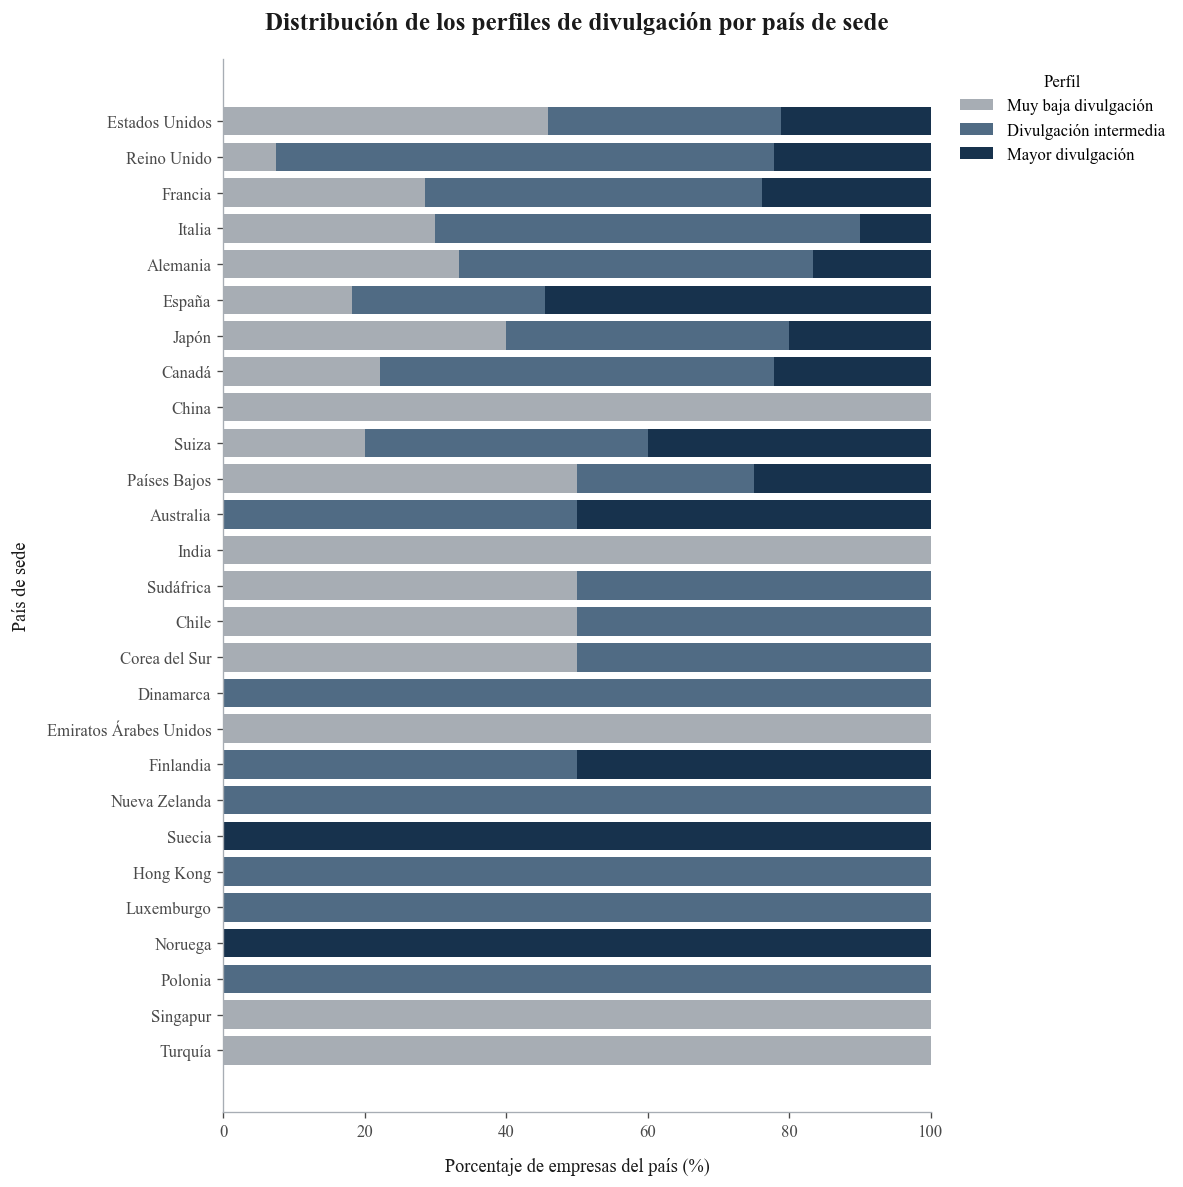

In [26]:
# Visualizamos la distribución porcentual de los tres perfiles
# de divulgación dentro de cada país de sede

# Creamos una copia con la información necesaria para la figura
distribucion_pais_grafica = (
    distribucion_pais_cluster[
        [
            "Pais_sede",
            "Total_empresas",
            "Porcentaje_Muy_baja_divulgacion",
            "Porcentaje_Divulgacion_intermedia",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
    .copy()
)

# Ordenamos los países por número total de empresas
# para mantener primero aquellos con mayor representación
distribucion_pais_grafica = (
    distribucion_pais_grafica
    .sort_values(
        "Total_empresas",
        ascending=True
    )
    .reset_index(drop=True)
)

# Definimos las posiciones de los países
posiciones = np.arange(
    len(distribucion_pais_grafica)
)

# Construimos la figura
fig, ax = plt.subplots(
    figsize=(10, 10)
)

# Primera sección: perfil de muy baja divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ],
    color=GRIS_MEDIO,
    label="Muy baja divulgación"
)

# Segunda sección: perfil de divulgación intermedia
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Divulgacion_intermedia"
    ],
    left=distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ],
    color=AZUL_SECUNDARIO,
    label="Divulgación intermedia"
)

# Calculamos la posición acumulada para la tercera sección
inicio_mayor = (
    distribucion_pais_grafica[
        "Porcentaje_Muy_baja_divulgacion"
    ]
    +
    distribucion_pais_grafica[
        "Porcentaje_Divulgacion_intermedia"
    ]
)

# Tercera sección: perfil de mayor divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica[
        "Porcentaje_Mayor_divulgacion"
    ],
    left=inicio_mayor,
    color=AZUL_MARINO,
    label="Mayor divulgación"
)

# Incorporamos los países
ax.set_yticks(posiciones)

ax.set_yticklabels(
    distribucion_pais_grafica["Pais_sede"]
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Distribución de los perfiles de divulgación por país de sede",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de empresas del país (%)",
    labelpad=10
)

ax.set_ylabel(
    "País de sede",
    labelpad=10
)

# El eje horizontal representa porcentajes
ax.set_xlim(0, 100)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Colocamos la leyenda fuera de la gráfica
# para evitar que se superponga con las barras
ax.legend(
    frameon=False,
    title="Perfil",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "kmeans_distribucion_perfiles_pais"
)

# Mostramos la figura
plt.show()

La distribución por país muestra que **el país de sede no corresponde de manera directa con un único perfil de divulgación de las empresas**. Entre los diez países que cuentan con al menos cinco empresas en la muestra, **nueve presentan empresas en los tres perfiles de divulgación**. La única excepción es **China**, cuyas nueve empresas se encuentran en el perfil de muy baja divulgación. Esto muestra que, para la mayoría de los países con mayor representación, existe heterogeneidad entre las empresas que un promedio nacional puede ocultar.

El caso de **Estados Unidos**, que concentra 85 empresas, muestra claramente esta situación: **39 empresas (45.88%)** pertenecen al perfil de muy baja divulgación, **28 (32.94%)** al perfil intermedio y **18 (21.18%)** al perfil de mayor divulgación. Por lo tanto, un mismo país puede contener empresas con patrones de transparencia considerablemente diferentes.

El clustering también permite matizar los resultados observados previamente para los países europeos. Los cinco países europeos con mayor número de empresas en la muestra (**Reino Unido, Francia, Italia, Alemania y España**) reúnen en conjunto **97 empresas**. De ellas, **53 (54.64%)** pertenecen al perfil de divulgación intermedia, **22 (22.68%)** al perfil de mayor divulgación y **22 (22.68%)** al perfil de muy baja divulgación. Por lo tanto, aun cuando estos países puedan presentar promedios nacionales relativamente elevados en el análisis exploratorio, **la mayoría de las empresas de este conjunto no pertenece al perfil de mayor divulgación**.

La composición tampoco es igual entre estos países. En **Reino Unido**, **70.37%** de las empresas pertenece al perfil intermedio; en **Francia**, **47.62%**; en **Italia**, **60.00%**; y en **Alemania**, **50.00%**. **España** presenta una distribución distinta: **54.55%** de sus empresas se ubica en el perfil de mayor divulgación, mientras que el **45.45% restante** pertenece a los perfiles intermedio o de muy baja divulgación.

Las diferencias entre estos países pueden interpretarse a partir del contexto institucional analizado previamente, aunque **no permiten establecer que la regulación nacional determine la pertenencia a un cluster**. España, Francia, Alemania e Italia compartían una base común de obligaciones europeas de información no financiera para determinadas grandes empresas; sin embargo, la revisión del EDA mostró que algunos países incorporaban además requerimientos nacionales con una correspondencia más directa con los indicadores del *Fashion Transparency Index*. **España**, que presenta la mayor proporción de empresas en el perfil de mayor divulgación entre estos cinco países (**54.55%**), contaba con la Ley 11/2018, que exige a las empresas comprendidas información sobre emisiones, debida diligencia en derechos humanos, proveedores, cuestiones sociales y ambientales y mecanismos de supervisión. Estas materias coinciden con varios de los indicadores que presentan mayores niveles de divulgación en la muestra (Jefatura del Estado, 2018).

En **Francia** y **Alemania** también existen obligaciones específicas estrechamente relacionadas con determinados indicadores del índice. La legislación francesa sobre el *devoir de vigilance* incorpora identificación de riesgos, medidas preventivas, mecanismos de alerta y seguimiento de impactos en operaciones y proveedores, mientras que la legislación alemana de debida diligencia en cadenas de suministro contempla análisis de riesgos, garantías contractuales de proveedores, criterios de selección y procedimientos de queja (República Francesa, 2017; República Federal de Alemania, 2021). Sin embargo, estos requerimientos resultan aplicables únicamente a determinadas empresas y cubren una parte de los 109 indicadores, lo que es consistente con que en ambos países predominen los perfiles intermedios en lugar de observarse una concentración general en el perfil de mayor divulgación.

El caso del **Reino Unido** resulta igualmente ilustrativo. La *Modern Slavery Act* exige a determinadas organizaciones publicar información sobre las medidas adoptadas frente a la esclavitud y la trata en sus operaciones y cadenas de suministro, y durante el periodo analizado también existían obligaciones de divulgación financiera relacionada con el clima para determinadas empresas (UK Parliament, 2015; UK Government, 2022). Esta combinación es consistente con que solamente **7.41%** de las empresas británicas se encuentre en el perfil de muy baja divulgación, aunque **70.37%** permanezca en el perfil intermedio: los requerimientos pueden favorecer la publicación de ciertos tipos de información sin abarcar todo el nivel de detalle considerado por el FTI. En **Italia**, por su parte, la revisión realizada identificó principalmente la base regulatoria europea común; que **60.00%** de sus empresas se encuentre en el perfil intermedio y únicamente **10.00%** en el de mayor divulgación refuerza la conclusión previa de que compartir un marco general de reporte no garantiza por sí solo una elevada divulgación en el conjunto de indicadores.

Asimismo, **China** presenta el contraste más claro. Las nueve empresas chinas se concentran en el perfil de muy baja divulgación, en línea con el resultado observado previamente en el EDA. Para 2023, los requerimientos corporativos revisados incorporaban determinada información ambiental y de responsabilidad social para algunas compañías, pero presentaban una correspondencia limitada con los indicadores más específicos del FTI sobre derechos laborales, condiciones de los trabajadores y prácticas comerciales. Además, las reglas generales de sostenibilidad posteriormente desarrolladas por las bolsas chinas todavía no correspondían al marco vigente durante el periodo analizado. Por ello, la concentración observada es **consistente con una menor coincidencia entre los requerimientos identificados para 2023 y la información específica evaluada por el índice**, sin que esto permita atribuir el resultado exclusivamente al país de sede (China Securities Regulatory Commission, 2021).

Estos resultados muestran una aportación concreta del clustering al análisis: **un promedio elevado por país no implica que la mayoría de las empresas de ese país pertenezca al perfil de mayor divulgación**. El análisis por clusters permite observar la composición interna que queda oculta detrás del promedio nacional y evita interpretar el posicionamiento de un país como una característica uniforme de todas sus empresas.

Por último, los resultados de los países representados por pocas empresas deben interpretarse con cautela, ya que sus porcentajes pueden estar determinados por uno o dos casos.

### Vista integrada de los perfiles identificados con K-Means

Como síntesis de la caracterización anterior, se construye un diagrama de Sankey que integra en una misma visualización la estructura de los tres perfiles obtenidos mediante K-Means, su comportamiento en las categorías Ambiental, Social y Gobernanza y la proporción de información divulgada y no divulgada.

El ancho de los flujos representa el número de observaciones **empresa–indicador**, manteniendo una unidad común a lo largo de toda la visualización. Los porcentajes incorporados en las etiquetas corresponden al nivel promedio de divulgación previamente calculado para cada perfil y categoría.

In [27]:
# Construimos una vista integrada de los perfiles obtenidos
# mediante K-Means utilizando las observaciones empresa-indicador

# Partimos de la matriz en formato largo construida previamente,
# que contiene una fila por empresa, indicador y cluster
sankey_kmeans = (
    X_largo_esg
    .copy()
)

# Calculamos, para cada cluster y categoría,
# el número total de observaciones empresa-indicador
# y cuántas de ellas corresponden a divulgación (1).
resumen_sankey = (
    sankey_kmeans
    .groupby(
        [
            "Cluster_KMeans",
            "Categoria"
        ],
        as_index=False
    )
    .agg(
        Total_observaciones=("Divulga", "size"),
        Divulgadas=("Divulga", "sum")
    )
)

# Calculamos las observaciones no divulgadas
resumen_sankey[
    "No_divulgadas"
] = (
    resumen_sankey[
        "Total_observaciones"
    ]
    -
    resumen_sankey[
        "Divulgadas"
    ]
)

# Calculamos el porcentaje de divulgación
# únicamente para incorporarlo en las etiquetas
resumen_sankey[
    "Porcentaje_divulgacion"
] = (
    resumen_sankey[
        "Divulgadas"
    ]
    /
    resumen_sankey[
        "Total_observaciones"
    ]
    *
    100
).round(2)


display(
    resumen_sankey
)

,Cluster_KMeans,Categoria,Total_observaciones,Divulgadas,No_divulgadas,Porcentaje_divulgacion
0,0,Environment,3731,131,3600,3.510
1,0,Governance,1820,148,1672,8.130
2,0,Social,4368,240,4128,5.490
3,1,Environment,2132,1255,877,58.860
4,1,Governance,1040,624,416,60.000
5,1,Social,2496,1291,1205,51.720
6,2,Environment,4387,1273,3114,29.020
7,2,Governance,2140,749,1391,35.000
8,2,Social,5136,1203,3933,23.420


In [28]:
# Construimos el diagrama de Sankey final para integrar
# los principales resultados de los perfiles de K-Means


# Definimos el orden conceptual de los clusters
# desde el perfil de menor hasta el de mayor divulgación
orden_clusters_sankey = [0, 2, 1]

nombres_perfiles_sankey = {
    0: "Muy baja divulgación",
    2: "Divulgación intermedia",
    1: "Mayor divulgación"
}

# Conservamos los colores utilizados previamente
# para distinguir los perfiles de K-Means
colores_perfiles_sankey = {
    0: AZUL_MARINO,
    2: GRIS_OSCURO,
    1: AZUL_SECUNDARIO
}

# Definimos el orden y la traducción
# de las categorías temáticas
orden_categorias_sankey = [
    "Environment",
    "Social",
    "Governance"
]

nombres_categorias_sankey = {
    "Environment": "Ambiental",
    "Social": "Social",
    "Governance": "Gobernanza"
}

# Definimos nombres breves para los indicadores
# con mayor diferencia dentro de cada categoría
nombres_indicadores_clave = {
    "Environment": (
        "Debida diligencia<br>"
        "ambiental"
    ),
    "Social": (
        "Prevención, mitigación y remediación<br>"
        "de riesgos de derechos humanos"
    ),
    "Governance": (
        "Riesgos, impactos y violaciones<br>"
        "ambientales identificados"
    )
}

# Función auxiliar para utilizar los colores
# de la libreta con distintos niveles de transparencia
def color_con_alpha(color, alpha):

    if (
        isinstance(color, str)
        and color.startswith("#")
        and len(color) == 7
    ):

        rojo = int(color[1:3], 16)
        verde = int(color[3:5], 16)
        azul = int(color[5:7], 16)

        return (
            f"rgba("
            f"{rojo}, {verde}, {azul}, {alpha}"
            f")"
        )

    return color

# Identificamos automáticamente el indicador
# con la mayor diferencia entre perfiles
# dentro de cada categoría temática
indicadores_clave_sankey = (
    promedio_indicadores_cluster[
        promedio_indicadores_cluster[
            "Categoria"
        ]
        .isin(
            orden_categorias_sankey
        )
    ]
    .sort_values(
        "Diferencia_max_min_pp",
        ascending=False
    )
    .drop_duplicates(
        subset="Categoria",
        keep="first"
    )
    .set_index(
        "Categoria"
    )
)

# Calculamos el número total de observaciones
# empresa-indicador posibles en la matriz
total_observaciones_posibles = (
    X.shape[0]
    *
    X.shape[1]
)

# Calculamos el número total de divulgaciones
# efectivamente registradas con valor igual a 1
total_divulgaciones = int(
    resumen_sankey[
        "Divulgadas"
    ]
    .sum()
)

# Calculamos el porcentaje global de divulgación
porcentaje_global_divulgado = (
    total_divulgaciones
    /
    total_observaciones_posibles
    *
    100
)

# Creamos las estructuras necesarias
# para almacenar los nodos del Sankey
etiquetas_nodos = []
colores_nodos = []
posiciones_x = []
posiciones_y = []
hover_nodos = []

indice_nodos = {}

# Función auxiliar para incorporar cada nodo
# y conservar su posición dentro de la figura
def agregar_nodo(
    clave,
    etiqueta,
    color,
    x,
    y,
    hover
):

    indice_nodos[clave] = len(
        etiquetas_nodos
    )

    etiquetas_nodos.append(
        etiqueta
    )

    colores_nodos.append(
        color
    )

    posiciones_x.append(
        x
    )

    posiciones_y.append(
        y
    )

    hover_nodos.append(
        hover
    )

# Incorporamos el nodo inicial.
# El flujo representa únicamente divulgaciones
# efectivamente registradas en la matriz
agregar_nodo(
    "Total",
    (
        "<b>Divulgaciones registradas</b><br>"
        f"{total_divulgaciones:,} de "
        f"{total_observaciones_posibles:,}<br>"
        f"{porcentaje_global_divulgado:.2f}%"
    ),
    GRIS_OSCURO,
    0.02,
    0.50,
    (
        f"{total_divulgaciones:,} observaciones "
        "empresa-indicador presentan valor 1 "
        f"de {total_observaciones_posibles:,} "
        "observaciones posibles."
    )
)

# Definimos las posiciones verticales
# correspondientes a los tres perfiles
posiciones_clusters_y = {
    0: 0.13,
    2: 0.50,
    1: 0.87
}

# Incorporamos los nodos correspondientes
# a los tres perfiles identificados por K-Means
for cluster in orden_clusters_sankey:

    fila_cluster = (
        resumen_general_clusters[
            resumen_general_clusters[
                "Cluster_KMeans"
            ]
            ==
            cluster
        ]
        .iloc[0]
    )

    empresas_cluster = int(
        fila_cluster[
            "Empresas"
        ]
    )

    promedio_cluster = float(
        fila_cluster[
            "Porcentaje_promedio_divulgacion"
        ]
    )

    divulgaciones_cluster = int(
        resumen_sankey[
            resumen_sankey[
                "Cluster_KMeans"
            ]
            ==
            cluster
        ][
            "Divulgadas"
        ]
        .sum()
    )

    agregar_nodo(
        f"Cluster_{cluster}",
        (
            f"<b>{nombres_perfiles_sankey[cluster]}</b><br>"
            f"{empresas_cluster} empresas | "
            f"{promedio_cluster:.2f}%<br>"
            f"{divulgaciones_cluster:,} divulgaciones"
        ),
        colores_perfiles_sankey[
            cluster
        ],
        0.24,
        posiciones_clusters_y[
            cluster
        ],
        (
            f"{nombres_perfiles_sankey[cluster]}: "
            f"{empresas_cluster} empresas, "
            f"{promedio_cluster:.2f}% de divulgación "
            f"promedio y {divulgaciones_cluster:,} "
            "divulgaciones registradas."
        )
    )

# Definimos desplazamientos verticales
# para organizar las categorías dentro de cada perfil
desplazamientos_categorias_y = {
    "Environment": -0.07,
    "Social": 0.00,
    "Governance": 0.07
}

# Incorporamos los nueve nodos correspondientes
# a las categorías temáticas dentro de cada perfil
for cluster in orden_clusters_sankey:

    for categoria in orden_categorias_sankey:

        fila_categoria = (
            resumen_sankey[
                (
                    resumen_sankey[
                        "Cluster_KMeans"
                    ]
                    ==
                    cluster
                )
                &
                (
                    resumen_sankey[
                        "Categoria"
                    ]
                    ==
                    categoria
                )
            ]
            .iloc[0]
        )

        porcentaje_categoria = float(
            fila_categoria[
                "Porcentaje_divulgacion"
            ]
        )

        divulgaciones_categoria = int(
            fila_categoria[
                "Divulgadas"
            ]
        )

        agregar_nodo(
            (
                f"Cluster_{cluster}_"
                f"{categoria}"
            ),
            (
                f"<b>"
                f"{nombres_categorias_sankey[categoria]}"
                f"</b><br>"
                f"{porcentaje_categoria:.2f}%"
            ),
            colores_perfiles_sankey[
                cluster
            ],
            0.51,
            (
                posiciones_clusters_y[
                    cluster
                ]
                +
                desplazamientos_categorias_y[
                    categoria
                ]
            ),
            (
                f"{nombres_perfiles_sankey[cluster]} - "
                f"{nombres_categorias_sankey[categoria]}: "
                f"{porcentaje_categoria:.2f}% de divulgación "
                f"y {divulgaciones_categoria:,} "
                "divulgaciones registradas."
            )
        )

# Definimos posiciones separadas para el último nivel
# con el fin de facilitar la lectura de las etiquetas
posiciones_finales_y = {
    ("Environment", "Clave"): 0.06,
    ("Environment", "Resto"): 0.22,

    ("Social", "Clave"): 0.39,
    ("Social", "Resto"): 0.56,

    ("Governance", "Clave"): 0.73,
    ("Governance", "Resto"): 0.90
}

# Incorporamos un nodo para el indicador con mayor
# diferencia dentro de cada categoría y otro nodo
# que reúne el resto de los indicadores
for categoria in orden_categorias_sankey:

    fila_indicador = (
        indicadores_clave_sankey
        .loc[
            categoria
        ]
    )

    indicador_completo = (
        fila_indicador[
            "Indicador"
        ]
    )

    porcentaje_bajo = float(
        fila_indicador[
            "Cluster_0"
        ]
    )

    porcentaje_intermedio = float(
        fila_indicador[
            "Cluster_2"
        ]
    )

    porcentaje_alto = float(
        fila_indicador[
            "Cluster_1"
        ]
    )

    agregar_nodo(
        f"{categoria}_Clave",
        (
            "<b>Indicador más diferenciador</b><br>"
            f"{nombres_indicadores_clave[categoria]}<br>"
            f"{porcentaje_bajo:.2f}% → "
            f"{porcentaje_intermedio:.2f}% → "
            f"{porcentaje_alto:.2f}%"
        ),
        GRIS_OSCURO,
        0.89,
        posiciones_finales_y[
            (
                categoria,
                "Clave"
            )
        ],
        (
            indicador_completo
            +
            "<br>"
            +
            "Muy baja → intermedia → mayor: "
            +
            f"{porcentaje_bajo:.2f}% → "
            f"{porcentaje_intermedio:.2f}% → "
            f"{porcentaje_alto:.2f}%."
        )
    )

    agregar_nodo(
        f"{categoria}_Resto",
        (
            "<b>Resto de indicadores</b><br>"
            f"{nombres_categorias_sankey[categoria]}"
        ),
        GRIS_MEDIO,
        0.89,
        posiciones_finales_y[
            (
                categoria,
                "Resto"
            )
        ],
        (
            "Divulgaciones correspondientes al resto "
            f"de los indicadores de la categoría "
            f"{nombres_categorias_sankey[categoria]}."
        )
    )

# Creamos las estructuras que almacenarán
# los flujos entre los distintos niveles
fuentes = []
destinos = []
valores = []
colores_flujos = []
descripciones_flujos = []

# Primer nivel:
# total de divulgaciones - perfiles
for cluster in orden_clusters_sankey:

    divulgaciones_cluster = int(
        resumen_sankey[
            resumen_sankey[
                "Cluster_KMeans"
            ]
            ==
            cluster
        ][
            "Divulgadas"
        ]
        .sum()
    )

    fuentes.append(
        indice_nodos[
            "Total"
        ]
    )

    destinos.append(
        indice_nodos[
            f"Cluster_{cluster}"
        ]
    )

    valores.append(
        divulgaciones_cluster
    )

    colores_flujos.append(
        color_con_alpha(
            colores_perfiles_sankey[
                cluster
            ],
            0.38
        )
    )

    descripciones_flujos.append(
        (
            f"Total → "
            f"{nombres_perfiles_sankey[cluster]}"
        )
    )

# Segundo nivel:
# cada perfil - categorías temáticas
for cluster in orden_clusters_sankey:

    for categoria in orden_categorias_sankey:

        fila_categoria = (
            resumen_sankey[
                (
                    resumen_sankey[
                        "Cluster_KMeans"
                    ]
                    ==
                    cluster
                )
                &
                (
                    resumen_sankey[
                        "Categoria"
                    ]
                    ==
                    categoria
                )
            ]
            .iloc[0]
        )

        divulgaciones_categoria = int(
            fila_categoria[
                "Divulgadas"
            ]
        )

        fuentes.append(
            indice_nodos[
                f"Cluster_{cluster}"
            ]
        )

        destinos.append(
            indice_nodos[
                (
                    f"Cluster_{cluster}_"
                    f"{categoria}"
                )
            ]
        )

        valores.append(
            divulgaciones_categoria
        )

        colores_flujos.append(
            color_con_alpha(
                colores_perfiles_sankey[
                    cluster
                ],
                0.32
            )
        )

        descripciones_flujos.append(
            (
                f"{nombres_perfiles_sankey[cluster]}"
                f" → "
                f"{nombres_categorias_sankey[categoria]}"
            )
        )

# Tercer nivel:
# cada categoría - indicador más diferenciador
# y resto de los indicadores de la categoría.
for cluster in orden_clusters_sankey:

    for categoria in orden_categorias_sankey:

        indicador_clave = (
            indicadores_clave_sankey
            .loc[
                categoria,
                "Indicador"
            ]
        )

        subconjunto = (
            X_largo_esg[
                (
                    X_largo_esg[
                        "Cluster_KMeans"
                    ]
                    ==
                    cluster
                )
                &
                (
                    X_largo_esg[
                        "Categoria"
                    ]
                    ==
                    categoria
                )
            ]
        )

        divulgaciones_categoria = int(
            subconjunto[
                "Divulga"
            ]
            .sum()
        )

        divulgaciones_indicador_clave = int(
            subconjunto[
                subconjunto[
                    "Indicador"
                ]
                ==
                indicador_clave
            ][
                "Divulga"
            ]
            .sum()
        )

        divulgaciones_resto = (
            divulgaciones_categoria
            -
            divulgaciones_indicador_clave
        )

        # Incorporamos el flujo hacia el indicador clave.
        # Cuando el indicador registra 0 divulgaciones,
        # la banda desaparece de forma natural.
        if divulgaciones_indicador_clave > 0:

            fuentes.append(
                indice_nodos[
                    (
                        f"Cluster_{cluster}_"
                        f"{categoria}"
                    )
                ]
            )

            destinos.append(
                indice_nodos[
                    f"{categoria}_Clave"
                ]
            )

            valores.append(
                divulgaciones_indicador_clave
            )

            colores_flujos.append(
                color_con_alpha(
                    colores_perfiles_sankey[
                        cluster
                    ],
                    0.72
                )
            )

            descripciones_flujos.append(
                (
                    f"{nombres_perfiles_sankey[cluster]}"
                    f" - "
                    f"{nombres_categorias_sankey[categoria]}"
                    " → indicador más diferenciador"
                )
            )

        # Incorporamos el flujo correspondiente
        # al resto de los indicadores
        if divulgaciones_resto > 0:

            fuentes.append(
                indice_nodos[
                    (
                        f"Cluster_{cluster}_"
                        f"{categoria}"
                    )
                ]
            )

            destinos.append(
                indice_nodos[
                    f"{categoria}_Resto"
                ]
            )

            valores.append(
                divulgaciones_resto
            )

            colores_flujos.append(
                color_con_alpha(
                    colores_perfiles_sankey[
                        cluster
                    ],
                    0.18
                )
            )

            descripciones_flujos.append(
                (
                    f"{nombres_perfiles_sankey[cluster]}"
                    f" - "
                    f"{nombres_categorias_sankey[categoria]}"
                    " → resto de indicadores"
                )
            )

# Construimos la figura
fig = go.Figure(
    data=[
        go.Sankey(

            arrangement="fixed",

            node=dict(
                pad=20,
                thickness=20,

                line=dict(
                    color=GRIS_MEDIO,
                    width=0.6
                ),

                label=etiquetas_nodos,
                color=colores_nodos,

                x=posiciones_x,
                y=posiciones_y,

                customdata=hover_nodos,

                hovertemplate=(
                    "%{customdata}"
                    "<extra></extra>"
                )
            ),

            link=dict(
                source=fuentes,
                target=destinos,
                value=valores,

                color=colores_flujos,

                customdata=descripciones_flujos,

                hovertemplate=(
                    "%{customdata}<br>"
                    "Divulgaciones registradas: "
                    "%{value:,}"
                    "<extra></extra>"
                )
            )
        )
    ]
)

# Incorporamos el título principal
# manteniendo el formato visual de la libreta
fig.update_layout(

    title=dict(
        text=(
            "Vista integrada de los perfiles "
            "identificados con K-Means"
        ),

        x=0.5,
        xanchor="center",

        font=dict(
            family="Times New Roman",
            size=16,
            color=NEGRO
        )
    ),

    font=dict(
        family="Times New Roman",
        size=10,
        color=NEGRO
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    width=1600,
    height=950,

    margin=dict(
        l=55,
        r=180,
        t=165,
        b=50
    )
)

# Incorporamos una aclaración metodológica
# para facilitar la correcta lectura del Sankey
fig.add_annotation(
    x=0.5,
    y=1.075,

    xref="paper",
    yref="paper",

    showarrow=False,

    text=(
        "El ancho de los flujos representa el número de "
        "divulgaciones registradas; los porcentajes de las "
        "etiquetas representan tasas de divulgación."
    ),

    font=dict(
        family="Times New Roman",
        size=11,
        color=GRIS_OSCURO
    )
)

# Incorporamos encabezados para identificar
# claramente los cuatro niveles de la visualización
encabezados_sankey = [
    (
        0.02,
        "Total de divulgaciones"
    ),
    (
        0.24,
        "Perfil"
    ),
    (
        0.51,
        "Categoría temática"
    ),
    (
        0.89,
        "Indicadores"
    )
]


for posicion_x, encabezado in encabezados_sankey:

    fig.add_annotation(
        x=posicion_x,
        y=1.015,

        xref="paper",
        yref="paper",

        showarrow=False,

        text=f"<b>{encabezado}</b>",

        font=dict(
            family="Times New Roman",
            size=12,
            color=NEGRO
        )
    )

# Guardamos una versión interactiva
# dentro de la carpeta de figuras
fig.write_html(
    ruta_figuras
    /
    "kmeans_sankey_perfiles.html"
)

# Guardamos también una versión estática
# en alta resolución para su incorporación al reporte
fig.write_image(
    str(
        ruta_figuras
        /
        "kmeans_sankey_perfiles.png"
    ),
    width=1600,
    height=950,
    scale=2
)


print(
    "Sankey exportado correctamente "
    "en HTML y PNG."
)

# Mostramos la figura
fig.show()

Sankey exportado correctamente en HTML y PNG.


El diagrama de Sankey integra en una sola visualización los distintos niveles utilizados para caracterizar los perfiles de K-Means. Una diferencia particularmente visible se encuentra entre el perfil de **divulgación intermedia** y el de **mayor divulgación**: ambos concentran un número absoluto de divulgaciones muy similar (**3,225 y 3,170**, respectivamente), aunque el primero reúne **107 empresas** y el segundo únicamente **52**. Por lo tanto, un volumen agregado semejante de información publicada puede corresponder a patrones empresariales considerablemente distintos; al considerar el tamaño de cada grupo, sus niveles promedio de divulgación son **27.65% y 55.93%**, respectivamente.

La descomposición por categoría y por indicadores concretos permite observar cómo esta diferencia general se manifiesta en la información publicada. Los tres indicadores destacados corresponden al indicador con **mayor diferencia entre los perfiles dentro de cada categoría temática**. El caso más evidente se presenta en *Prevention Mitigation and Remediation of Human Rights Risks* (prevención, mitigación y remediación de riesgos de derechos humanos): su divulgación es **0% en el perfil de muy baja divulgación**, aumenta a **36.45% en el perfil intermedio** y alcanza **92.31% en el perfil de mayor divulgación**, por lo que el flujo correspondiente desaparece completamente en el primer grupo. De esta manera, el Sankey conecta la gradación general identificada por K-Means con diferencias temáticas y con ejemplos específicos de información que aparece o permanece ausente a medida que cambia el perfil de divulgación.

### Conclusión de los perfiles identificados con K-Means

K-Means identificó tres perfiles de empresas caracterizados principalmente por una gradación en la **intensidad de divulgación: muy baja, intermedia y mayor divulgación**. Estos perfiles no fueron definidos a partir del porcentaje total de cada empresa, sino de la similitud entre sus patrones de respuesta en los **109 indicadores binarios**. El análisis posterior muestra que esta gradación se mantiene de manera consistente en prácticamente toda la matriz, aunque cada perfil conserva diferencias importantes respecto a qué información publica y qué temas permanecen ausentes.

La solución con **k = 3** también mostró una alta estabilidad ante distintas inicializaciones. Sin embargo, su coeficiente de **Silhouette (0.190)** indica que los grupos no se encuentran completamente separados, por lo que se interpretan como una **segmentación exploratoria de los patrones de divulgación** y no como categorías empresariales rígidas.

En conjunto, K-Means permite observar heterogeneidad que los resultados agregados no muestran: empresas con patrones de divulgación distintos pueden quedar resumidas bajo un mismo porcentaje global o nacional, mientras que algunos temas permanecen poco divulgados incluso entre las empresas del perfil de mayor divulgación. La utilidad de esta solución radica, por tanto, en distinguir y caracterizar **patrones empresariales de transparencia** más allá de una clasificación basada únicamente en promedios.

## Clustering jerárquico

El segundo método evaluado es el **clustering jerárquico aglomerativo**. Este procedimiento parte de considerar inicialmente a cada empresa como un grupo independiente y posteriormente une de forma progresiva a las empresas o grupos que presentan patrones de divulgación similares (Murtagh & Contreras, 2012).

A diferencia de K-Means, este método permite representar la secuencia de agrupamiento mediante un **dendrograma**, en el que puede observarse cómo se forman grupos cada vez más amplios y explorar diferentes posibilidades para dividir la estructura resultante. Esta característica puede ser especialmente útil cuando los datos presentan **grupos dentro de otros grupos**. Por ejemplo, en un conjunto de clientes podrían identificarse primero dos grupos generales según su comportamiento de compra y, dentro de uno de ellos, distinguir posteriormente subgrupos con preferencias diferentes. El clustering jerárquico permite examinar estas divisiones en distintos niveles de la misma estructura mediante el dendrograma (Murtagh & Contreras, 2017).

Para desarrollar el análisis, primero se comparan distintos **criterios de enlace** (*linkage*) y posteriormente se evalúan diferentes números de clusters mediante el coeficiente de Silhouette y la interpretación de los perfiles obtenidos.

### Evaluación del criterio de enlace

En el clustering jerárquico, cada empresa comienza formando su propio grupo. Después, el algoritmo va uniendo los grupos de dos en dos hasta construir grupos cada vez más grandes.

En cada paso, el algoritmo debe decidir **qué dos grupos fusionar**. Esta decisión depende del **criterio de enlace** (*linkage*), es decir, de la regla utilizada para evaluar cada posible unión. Los distintos criterios de enlace pueden generar estructuras de agrupamiento diferentes al definir de manera distinta cómo se evalúa la unión entre grupos (Murtagh & Contreras, 2012).

Los criterios considerados aplican reglas diferentes para seleccionar la siguiente fusión:

- **Single:** toma como referencia a las dos empresas más cercanas entre los grupos. Si existe una empresa de un grupo muy próxima a una empresa del otro, la distancia entre ambos grupos se considera pequeña.

- **Complete:** toma como referencia a las dos empresas más alejadas entre los grupos. Dos grupos se consideran cercanos solamente si incluso ese par más separado mantiene una distancia relativamente pequeña.

- **Average:** considera todas las distancias entre las empresas de un grupo y las empresas del otro y calcula su promedio. Si ese promedio es pequeño, los grupos se consideran próximos.

- **Ward:** no utiliza únicamente una distancia entre dos empresas. En su lugar, analiza qué ocurriría si se unieran dos grupos y selecciona la unión que produzca el menor aumento en la variación interna. Es decir, busca que los grupos resultantes permanezcan lo más compactos posible (Ward, 1963).

Por lo tanto, los cuatro criterios siguen el mismo proceso de unión progresiva, pero utilizan distintas formas de determinar **qué dos grupos deben unirse en cada paso**. Como estas reglas pueden producir agrupamientos diferentes, se comparan sus resultados para configuraciones de **2 a 10 clusters** mediante el **coeficiente de Silhouette**. Para mantener la misma representación de los datos empleada en K-Means, todas las configuraciones se evalúan utilizando **distancia euclidiana**.

In [27]:
# Evaluamos distintos criterios de enlace del clustering jerárquico
# para identificar cuáles producen agrupamientos con mejor
# cohesión interna y separación entre grupos.

# Definimos los cuatro criterios de enlace que serán comparados
criterios_enlace = [
    "single",
    "complete",
    "average",
    "ward"
]

# Creamos una lista vacía donde almacenaremos
# los resultados obtenidos en cada configuración
resultados_jerarquico = []

# Recorremos cada criterio de enlace
for linkage_method in criterios_enlace:

    # Para cada criterio evaluamos soluciones
    # desde 2 hasta 10 clusters
    for k in range(2, 11):

        # Construimos el modelo de clustering jerárquico
        modelo = AgglomerativeClustering(

            # Indicamos el número de clusters que queremos formar
            n_clusters=k,

            # Indicamos el criterio utilizado para decidir
            # cómo se van uniendo los grupos
            linkage=linkage_method,

            # Utilizamos distancia euclidiana en todas
            # las configuraciones evaluadas
            metric="euclidean"
        )

        # Ajustamos el modelo utilizando los 109 indicadores
        # y recuperamos el cluster asignado a cada empresa
        etiquetas = modelo.fit_predict(X)

        # Calculamos el coeficiente de Silhouette
        # correspondiente a esta configuración
        silhouette = silhouette_score(
            X,
            etiquetas
        )

        # Guardamos el criterio de enlace,
        # el número de clusters y el resultado obtenido
        resultados_jerarquico.append({
            "Linkage": linkage_method,
            "Clusters": k,
            "Silhouette": silhouette
        })


# Convertimos los resultados en un DataFrame
# para facilitar su revisión y comparación
resultados_jerarquico = pd.DataFrame(
    resultados_jerarquico
)

# Redondeamos el coeficiente para facilitar su lectura
resultados_jerarquico["Silhouette"] = (
    resultados_jerarquico["Silhouette"]
    .round(3)
)

# Mostramos todos los resultados obtenidos
display(resultados_jerarquico)

,Linkage,Clusters,Silhouette
0,single,2,0.213
1,single,3,0.208
2,single,4,0.183
3,single,5,0.101
4,single,6,0.076
5,single,7,0.087
6,single,8,0.091
7,single,9,0.089
8,single,10,0.080
9,complete,2,0.264


Los resultados muestran que **Average obtiene el coeficiente de Silhouette más alto para cada número de clusters evaluado entre 2 y 10**. Su valor máximo se presenta con **2 clusters (0.265)**, seguido de **3 clusters (0.245)** y **4 clusters (0.220)**.

El criterio **Complete** presenta un resultado prácticamente idéntico con 2 clusters (**0.264**), pero obtiene coeficientes menores que Average en las demás configuraciones. **Single** y **Ward** también registran valores inferiores. Por esta razón, **Average se selecciona como criterio de enlace para continuar el análisis**. No obstante, su valor máximo permanece lejos de 1, por lo que no indica una separación completamente marcada entre los grupos.

A partir de este criterio se examina la estructura jerárquica mediante el dendrograma y posteriormente se evalúa con mayor detalle el número de clusters.

### Dendrograma del clustering jerárquico

Una vez seleccionado **Average** como criterio de enlace candidato, se construye el **dendrograma** para observar cómo se van formando los grupos durante el proceso de clustering jerárquico.

El análisis comienza con las **250 empresas separadas**. A partir de sus patrones de divulgación, el algoritmo une primero las empresas o grupos más similares y repite este proceso hasta que todas las observaciones terminan formando un solo grupo.

El dendrograma representa gráficamente este proceso. Las ramas que se unen a una **distancia baja** corresponden a empresas o grupos relativamente similares, mientras que las uniones que ocurren a una **distancia mayor** representan grupos con patrones más diferentes.

Además, el dendrograma permite visualizar diferentes posibilidades para dividir la estructura en clusters. Un corte horizontal realizado a distintas alturas produciría diferentes números de grupos. Sin embargo, debido al número de empresas analizadas, esta gráfica se utiliza principalmente como una referencia visual y no como el único criterio para seleccionar el número final de clusters.

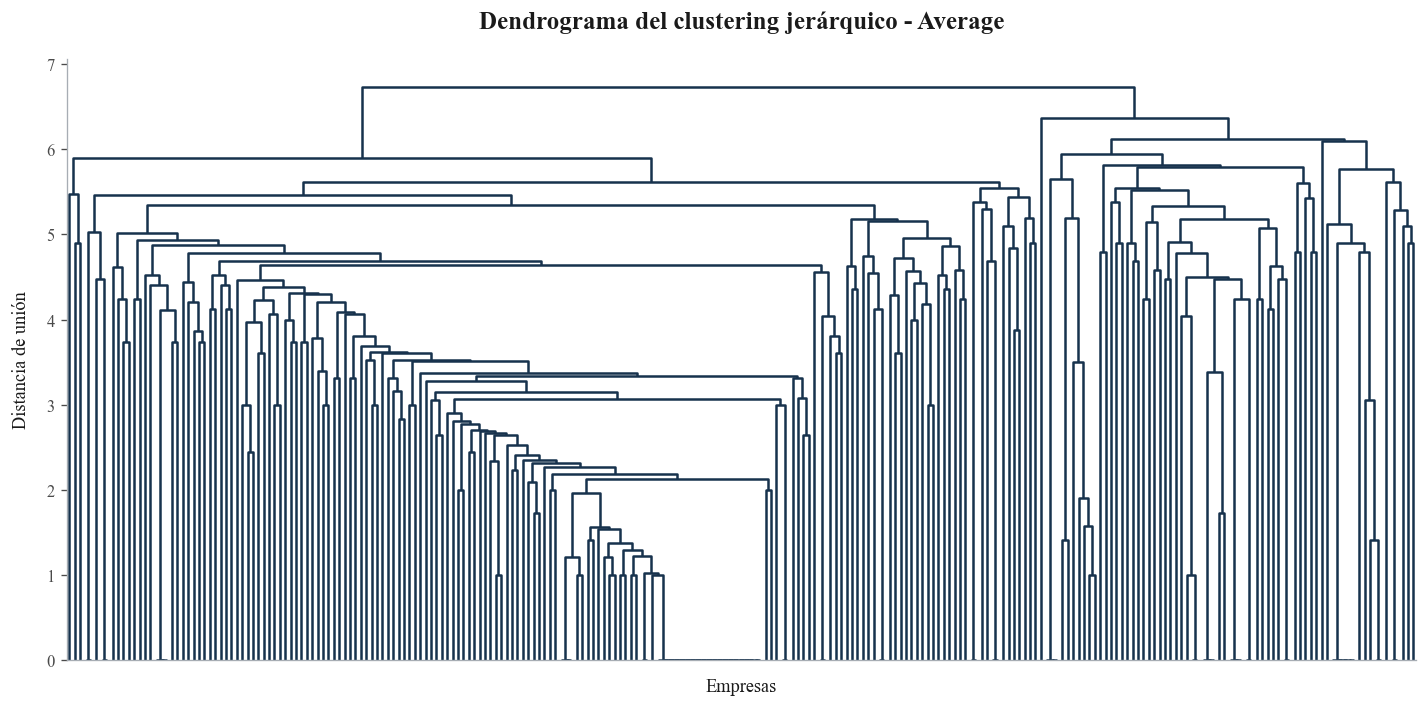

In [28]:
# Construimos la estructura jerárquica utilizando
# el criterio de enlace Average seleccionado anteriormente.

# linkage genera la información necesaria para representar
# cómo se van uniendo progresivamente las empresas y los grupos.
# Utilizamos los mismos 109 indicadores empleados
# en el resto del análisis.
matriz_enlace_average = linkage(
    X,
    method="average",
    metric="euclidean"
)

# Construimos el dendrograma para visualizar
# la estructura jerárquica obtenida
fig, ax = plt.subplots(figsize=(12, 6))

# Representamos las sucesivas uniones entre empresas y grupos
# Como existen 250 empresas, omitimos sus nombres individuales
# para evitar que la gráfica resulte ilegible.
dendrogram(
    matriz_enlace_average,
    no_labels=True,
    color_threshold=0,
    above_threshold_color=AZUL_MARINO,
    ax=ax
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Dendrograma del clustering jerárquico - Average",
    pad=18
)

ax.set_xlabel(
    "Empresas",
    labelpad=10
)

ax.set_ylabel(
    "Distancia de unión",
    labelpad=10
)

# Eliminamos los bordes superiores y derechos
# para conservar el formato visual utilizado
# en las figuras anteriores
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura en alta resolución
guardar_figura(
    fig,
    "jerarquico_dendrograma_average"
)

# Mostramos la figura
plt.show()

En este sentido, el dendrograma muestra que las empresas se van integrando progresivamente en grupos cada vez más amplios. Las primeras uniones ocurren a distancias relativamente bajas, mientras que las últimas combinaciones se producen a distancias mayores, lo que indica que en estas etapas se están uniendo grupos con patrones de divulgación más diferentes.

En la parte superior se observan algunas separaciones entre grupos amplios de empresas; sin embargo, no aparece un único punto de corte que determine de manera evidente el número de clusters. Por esta razón, el dendrograma se utiliza como una herramienta complementaria y la selección del número de grupos se evalúa posteriormente mediante el coeficiente de Silhouette y la interpretación de las soluciones obtenidas.

### Evaluación del número de clusters

Después de seleccionar **Average** como criterio de enlace, se revisa con mayor detalle el número de clusters que podría representar la estructura obtenida.

Para ello, se recuperan los coeficientes de **Silhouette** calculados previamente para las configuraciones de **2 a 10 clusters** utilizando únicamente este criterio de enlace. El objetivo es identificar qué número de grupos presenta una mayor cohesión interna y una mejor separación respecto a los demás.

In [29]:
# Recuperamos únicamente los resultados correspondientes
# al criterio de enlace Average

resultados_average = (
    resultados_jerarquico[
        resultados_jerarquico["Linkage"] == "average"
    ]
    .copy()
)

# Mostramos los resultados para revisar
# cómo cambia Silhouette al aumentar el número de clusters
display(resultados_average)

,Linkage,Clusters,Silhouette
18,average,2,0.265
19,average,3,0.245
20,average,4,0.220
21,average,5,0.218
22,average,6,0.219
23,average,7,0.189
24,average,8,0.179
25,average,9,0.180
26,average,10,0.186


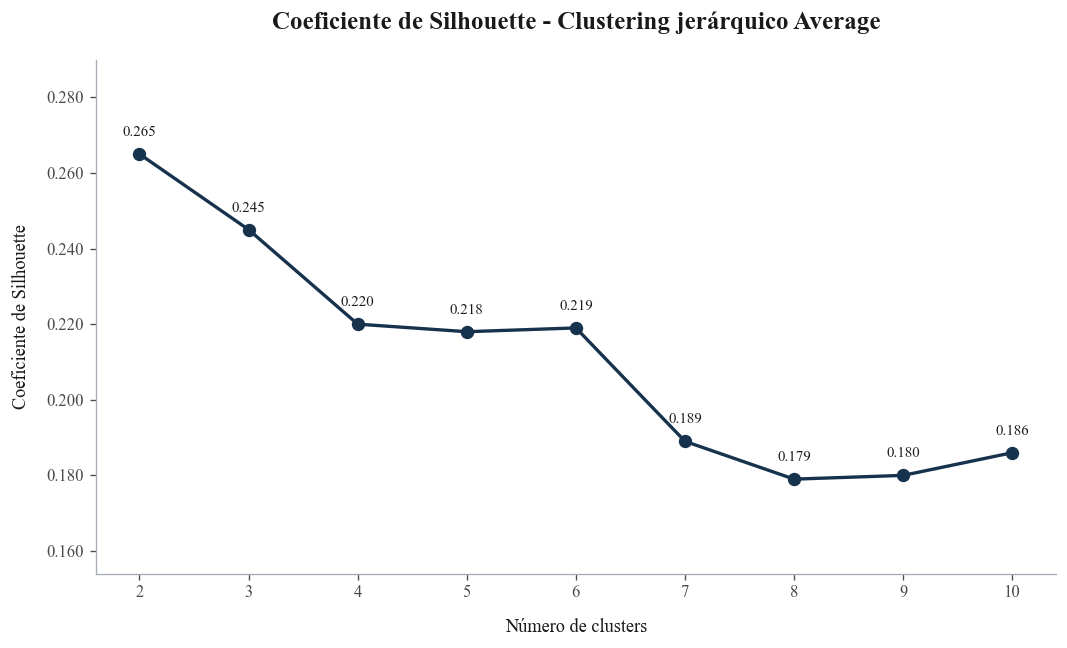

In [30]:
# Visualizamos el coeficiente de Silhouette obtenido
# con Average para cada número de clusters evaluado

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos la gráfica de línea
ax.plot(
    resultados_average["Clusters"],
    resultados_average["Silhouette"],
    color=AZUL_MARINO,
    marker="o",
    markersize=7,
    linewidth=2
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Coeficiente de Silhouette - Clustering jerárquico Average",
    pad=18
)

ax.set_xlabel(
    "Número de clusters",
    labelpad=10
)

ax.set_ylabel(
    "Coeficiente de Silhouette",
    labelpad=10
)

# Mostramos todos los valores de clusters evaluados
ax.set_xticks(
    resultados_average["Clusters"]
)

# Mostramos tres decimales en el eje vertical
ax.yaxis.set_major_formatter(
    StrMethodFormatter("{x:.3f}")
)

# Eliminamos los bordes que no aportan información
# para mantener el formato visual del notebook
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el valor de Silhouette junto a cada punto
for k, silhouette in zip(
    resultados_average["Clusters"],
    resultados_average["Silhouette"]
):

    ax.text(
        k,
        silhouette + 0.004,
        f"{silhouette:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=NEGRO
    )

# Dejamos un pequeño margen alrededor de los valores
ax.set_ylim(
    resultados_average["Silhouette"].min() - 0.025,
    resultados_average["Silhouette"].max() + 0.025
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "jerarquico_average_silhouette"
)

# Mostramos la figura
plt.show()

**Interpretación del coeficiente de Silhouette (Clustering Jerárquico)**

El coeficiente de Silhouette alcanza su valor más alto con **2 clusters (0.265)**. Al aumentar a **3 clusters**, el valor disminuye a **0.245**, mientras que con **4 clusters** se reduce a **0.220**. A partir de ese punto, los coeficientes se mantienen en niveles similares o inferiores.

Por lo tanto, **2 clusters constituye la configuración cuantitativamente más favorable para el criterio Average**. Sin embargo, la solución con **3 clusters conserva un coeficiente relativamente cercano** y podría permitir distinguir un perfil adicional que no sea visible con únicamente dos grupos.

Por esta razón, antes de seleccionar definitivamente el número de clusters, se comparan con mayor detalle las soluciones con **2, 3 y 4 grupos**, considerando tanto su tamaño como sus niveles generales de divulgación.

### Comparación de las soluciones con 2, 3 y 4 clusters

Aunque el coeficiente de Silhouette favorece la solución con **2 clusters**, las configuraciones con **3 y 4 grupos** también se examinan para determinar si una división más detallada permite distinguir perfiles de divulgación adicionales.

Para cada solución se revisa el **número de empresas** que integra cada cluster y su nivel general de divulgación mediante el promedio, la mediana y los valores mínimo y máximo. Esta comparación permite observar si al aumentar el número de grupos se identifican perfiles claramente distintos o si únicamente se subdividen grupos previamente existentes.

In [31]:
# Comparamos las soluciones de clustering jerárquico
# con 2, 3 y 4 clusters utilizando el criterio Average.

# Creamos una lista donde almacenaremos
# el resumen correspondiente a cada configuración
comparacion_jerarquico = []

# Conservamos también las etiquetas obtenidas
# para poder recuperar posteriormente cualquiera
# de las soluciones evaluadas
etiquetas_jerarquico = {}

# Evaluamos las tres configuraciones de interés
for k in [2, 3, 4]:

    # Construimos el modelo de clustering jerárquico.
    # En todos los casos mantenemos Average como
    # criterio de enlace y modificamos únicamente
    # el número de clusters.
    modelo = AgglomerativeClustering(
        n_clusters=k,
        linkage="average",
        metric="euclidean"
    )

    # Ajustamos el modelo utilizando los 109 indicadores
    # y recuperamos el cluster asignado a cada empresa
    etiquetas = modelo.fit_predict(X)

    # Guardamos las etiquetas correspondientes
    # a esta configuración para utilizarlas después
    etiquetas_jerarquico[k] = etiquetas

    # Calculamos el coeficiente de Silhouette
    # correspondiente a la solución actual
    silhouette = silhouette_score(
        X,
        etiquetas
    )

    # Creamos una tabla auxiliar con el cluster asignado
    # y el porcentaje general de divulgación de cada empresa.
    #
    # El porcentaje ya fue calculado previamente a partir
    # de los 109 indicadores binarios.
    resumen_auxiliar = pd.DataFrame({
        "Cluster": etiquetas,
        "Porcentaje_divulgacion":
            porcentaje_divulgacion_empresa.values
    })

    # Resumimos las características generales
    # de cada cluster
    resumen_auxiliar = (
        resumen_auxiliar
        .groupby(
            "Cluster",
            as_index=False
        )
        .agg(
            Empresas=(
                "Porcentaje_divulgacion",
                "size"
            ),
            Promedio_divulgacion=(
                "Porcentaje_divulgacion",
                "mean"
            ),
            Mediana_divulgacion=(
                "Porcentaje_divulgacion",
                "median"
            ),
            Minimo_divulgacion=(
                "Porcentaje_divulgacion",
                "min"
            ),
            Maximo_divulgacion=(
                "Porcentaje_divulgacion",
                "max"
            )
        )
    )

    # Incorporamos el número de clusters evaluado
    resumen_auxiliar.insert(
        0,
        "k",
        k
    )

    # Incorporamos también el coeficiente de Silhouette
    # de la configuración completa
    resumen_auxiliar["Silhouette"] = silhouette

    # Guardamos el resultado antes de continuar
    # con la siguiente configuración
    comparacion_jerarquico.append(
        resumen_auxiliar
    )

# Unimos los resultados de las tres configuraciones
# en una sola tabla
comparacion_jerarquico = pd.concat(
    comparacion_jerarquico,
    ignore_index=True
)

# Definimos las columnas numéricas que queremos redondear
columnas_redondear = [
    "Promedio_divulgacion",
    "Mediana_divulgacion",
    "Minimo_divulgacion",
    "Maximo_divulgacion",
    "Silhouette"
]

# Redondeamos a tres decimales para facilitar la lectura
comparacion_jerarquico[
    columnas_redondear
] = (
    comparacion_jerarquico[
        columnas_redondear
    ]
    .round(3)
)

# Mostramos la comparación completa
display(
    comparacion_jerarquico
)

,k,Cluster,Empresas,Promedio_divulgacion,Mediana_divulgacion,Minimo_divulgacion,Maximo_divulgacion,Silhouette
0,2,0,70,51.298,48.624,22.018,80.734,0.265
1,2,1,180,15.291,14.679,0.000,44.954,0.265
2,3,0,69,51.190,48.624,22.018,80.734,0.245
3,3,1,180,15.291,14.679,0.000,44.954,0.245
4,3,2,1,58.716,58.716,58.716,58.716,0.245
5,4,0,18,68.654,67.890,55.046,80.734,0.220
6,4,1,51,45.026,46.789,22.018,57.798,0.220
7,4,2,1,58.716,58.716,58.716,58.716,0.220
8,4,3,180,15.291,14.679,0.000,44.954,0.220


La solución con **2 clusters** divide a las 250 empresas en dos grupos amplios. El primero reúne **70 empresas** con un promedio de divulgación de **51.30%**, mientras que el segundo concentra **180 empresas** con un promedio considerablemente menor, de **15.29%**. Esta configuración presenta además el coeficiente de Silhouette más alto de las tres alternativas comparadas (**0.265**).

Al aumentar a **3 clusters**, la estructura cambia muy poco. El grupo de **180 empresas permanece sin modificaciones**, mientras que el grupo de mayor divulgación se divide en **69 empresas** con un promedio de **51.19%** y un cluster formado por **una sola empresa**, con **58.72%** de divulgación. Por lo tanto, el tercer cluster no representa un perfil amplio dentro de la muestra, sino el aislamiento de una observación particular.

Con **4 clusters**, el grupo de 180 empresas continúa sin cambios y el cluster de una sola empresa también permanece separado. La principal diferencia es que las otras 69 empresas se dividen en dos grupos: **18 empresas** con un promedio de **68.65%** y **51 empresas** con **45.03%**. Aunque esta división permite distinguir dos niveles dentro del grupo de mayor divulgación, la solución presenta un coeficiente de Silhouette menor (**0.220**) y mantiene un cluster compuesto por una única empresa.

En conjunto, **k = 2 se selecciona como solución candidata para continuar el análisis jerárquico**. Esta configuración presenta el mayor coeficiente de Silhouette (**0.265**), genera dos grupos amplios de **70 y 180 empresas** y evita la formación de un cluster compuesto por una sola observación.

### Recuperación de la solución candidata del clustering jerárquico

Con la configuración seleccionada (**criterio de enlace Average y k = 2**), se recupera la asignación de cada empresa y se incorpora a la información descriptiva para realizar posteriormente la caracterización de los dos perfiles identificados.

In [32]:
# Recuperamos la solución candidata del clustering jerárquico
# utilizando Average y 2 clusters

# Definimos el número de clusters seleccionado
K_JERARQUICO = 2

# Construimos el modelo con la configuración candidata
modelo_jerarquico_candidato = AgglomerativeClustering(

    # Utilizamos dos clusters
    n_clusters=K_JERARQUICO,

    # Mantenemos Average como criterio de enlace
    linkage="average",

    # Utilizamos distancia euclidiana, igual que en
    # la evaluación realizada anteriormente
    metric="euclidean"
)

# Ajustamos el modelo utilizando los 109 indicadores binarios
# y recuperamos el cluster asignado a cada empresa
clusters_jerarquico = (
    modelo_jerarquico_candidato
    .fit_predict(X)
)

# Creamos una copia de la información descriptiva
# para conservar el nombre y país de sede de cada empresa
resultado_jerarquico = informacion_empresas.copy()

# Incorporamos la asignación obtenida mediante
# clustering jerárquico
resultado_jerarquico[
    "Cluster_Jerarquico"
] = clusters_jerarquico

# Mostramos las primeras observaciones
# para verificar que la asignación se haya incorporado
display(
    resultado_jerarquico.head()
)

,Company,Pais_sede,Cluster_Jerarquico
0,AJIO,India,1
1,ALDO,Canadá,1
2,Abercrombie & Fitch,Estados Unidos,1
3,Adidas AG,Alemania,0
4,Aeropostale Inc.,Estados Unidos,1


In [33]:
# Revisamos cuántas empresas fueron asignadas
# a cada uno de los dos clusters identificados

distribucion_clusters_jerarquico = (
    resultado_jerarquico[
        "Cluster_Jerarquico"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Empresas")
)

# Mostramos la distribución obtenida
display(
    distribucion_clusters_jerarquico
)

,Cluster,Empresas
0,0,70
1,1,180


In [34]:
# Exportamos la asignación obtenida para conservarla
# y utilizarla posteriormente en la caracterización
# de los perfiles y en la comparación entre métodos

resultado_jerarquico.to_csv(
    ruta_datos / "resultado_jerarquico_clusters.csv",
    index=False
)

print(
    "Resultado del clustering jerárquico exportado correctamente."
)

Resultado del clustering jerárquico exportado correctamente.


### Interpretación de los perfiles obtenidos con clustering jerárquico

Una vez definida la solución candidata con **2 clusters**, se examinan las características de los grupos obtenidos para determinar qué patrones de divulgación los distinguen. La interpretación comienza con una revisión de su tamaño y nivel general de divulgación; posteriormente se analizan las categorías temáticas y los indicadores que presentan las mayores diferencias entre ambos perfiles.

**Distribución y nivel general de divulgación**

In [35]:
# Incorporamos el porcentaje general de divulgación
# de cada empresa a la solución jerárquica obtenida

analisis_perfiles_jerarquico = resultado_jerarquico.copy()

analisis_perfiles_jerarquico[
    "Porcentaje_divulgacion"
] = porcentaje_divulgacion_empresa.values

# Resumimos el tamaño de cada cluster y su
# porcentaje promedio general de divulgación
resumen_general_jerarquico = (
    analisis_perfiles_jerarquico
    .groupby(
        "Cluster_Jerarquico",
        as_index=False
    )
    .agg(
        Empresas=(
            "Company",
            "nunique"
        ),
        Porcentaje_promedio_divulgacion=(
            "Porcentaje_divulgacion",
            "mean"
        )
    )
)

# Redondeamos los porcentajes para facilitar su lectura
resumen_general_jerarquico[
    "Porcentaje_promedio_divulgacion"
] = (
    resumen_general_jerarquico[
        "Porcentaje_promedio_divulgacion"
    ]
    .round(2)
)

# Mostramos el resultado
display(
    resumen_general_jerarquico
)

,Cluster_Jerarquico,Empresas,Porcentaje_promedio_divulgacion
0,0,70,51.300
1,1,180,15.290


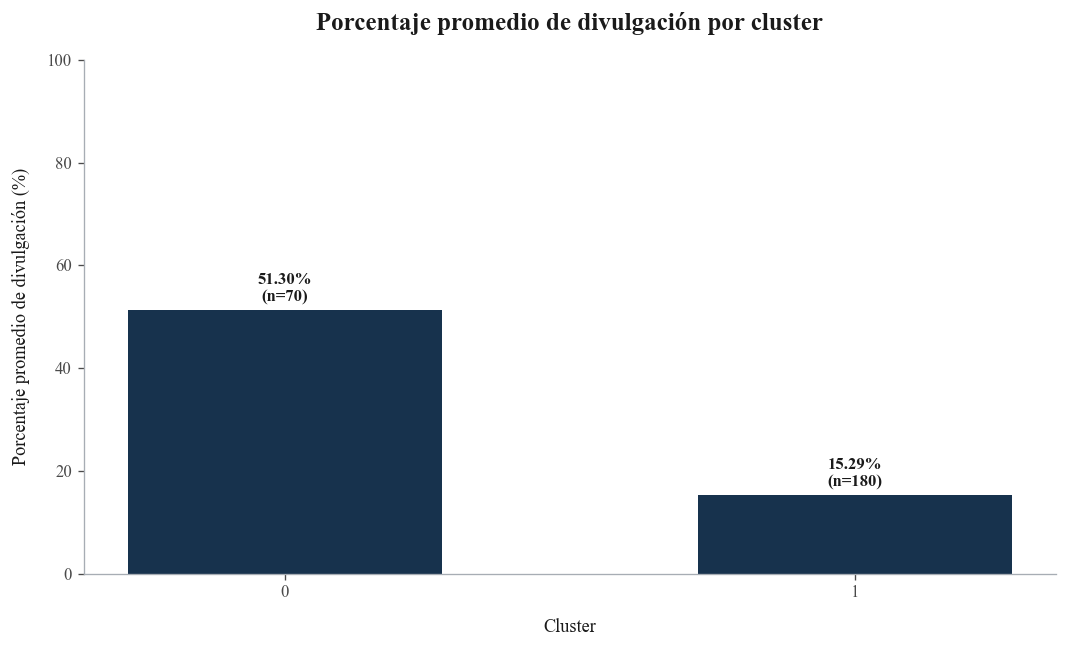

In [36]:
# Visualizamos el nivel promedio general de divulgación
# correspondiente a los dos perfiles identificados

fig, ax = plt.subplots(figsize=(9, 5.5))

# Construimos una barra para cada cluster
barras = ax.bar(
    resumen_general_jerarquico[
        "Cluster_Jerarquico"
    ].astype(str),
    resumen_general_jerarquico[
        "Porcentaje_promedio_divulgacion"
    ],
    color=AZUL_MARINO,
    width=0.55
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por cluster",
    pad=18
)

ax.set_xlabel(
    "Cluster",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Eliminamos los bordes que no aportan información
# para conservar el mismo formato visual del notebook
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje promedio y el número
# de empresas correspondiente a cada grupo
for barra, porcentaje, empresas in zip(
    barras,
    resumen_general_jerarquico[
        "Porcentaje_promedio_divulgacion"
    ],
    resumen_general_jerarquico[
        "Empresas"
    ]
):

    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{porcentaje:.2f}%\n(n={empresas})",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=NEGRO
    )

# Utilizamos la misma escala porcentual
# empleada en la caracterización de K-Means
ax.set_ylim(0, 100)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "jerarquico_divulgacion_promedio_clusters"
)

# Mostramos la figura
plt.show()

 Los dos grupos presentan una diferencia clara en su nivel general de divulgación. El **Cluster 0**, integrado por **70 empresas**, alcanza un promedio de **51.30%**, mientras que el **Cluster 1**, que reúne **180 empresas**, registra un promedio considerablemente menor, de **15.29%**.

Los números asignados a los clusters funcionan únicamente como etiquetas. A partir de sus resultados, la solución jerárquica puede interpretarse inicialmente como una separación entre un perfil de **mayor divulgación** y otro de **menor divulgación**.

Esta solución presenta una **segmentación menos detallada que K-Means**, al resumir a las empresas en dos perfiles generales de divulgación.

**Perfil de divulgación por categoría temática**

La diferencia observada en el nivel general de divulgación permite distinguir inicialmente dos perfiles. Para conocer si esta separación se mantiene en distintas áreas del índice, se compara ahora la divulgación de cada cluster en las categorías **Environment, Social y Governance**.

Esta revisión permite observar si el perfil de mayor divulgación mantiene niveles superiores en las tres categorías o si alguno de los grupos presenta una composición temática particular.

In [37]:
# Creamos una copia de la matriz de indicadores
# e incorporamos el cluster asignado mediante
# clustering jerárquico a cada empresa
X_clusters_jerarquico = X.copy()

X_clusters_jerarquico[
    "Cluster_Jerarquico"
] = clusters_jerarquico

# Transformamos la matriz de formato ancho a formato largo.
# Cada fila representará ahora la combinación:
# empresa - indicador - cluster
X_largo_jerarquico = (
    X_clusters_jerarquico
    .reset_index()
    .melt(
        id_vars=[
            "index",
            "Cluster_Jerarquico"
        ],
        var_name="Indicador",
        value_name="Divulga"
    )
)

# Recuperamos la categoría temática de cada indicador
# utilizando el mapa construido previamente
X_largo_jerarquico[
    "Categoria"
] = (
    X_largo_jerarquico[
        "Indicador"
    ]
    .map(mapa_categorias)
)

# Conservamos únicamente las tres categorías
# utilizadas para caracterizar los perfiles
X_largo_jerarquico_esg = (
    X_largo_jerarquico[
        X_largo_jerarquico[
            "Categoria"
        ].isin(
            [
                "Environment",
                "Social",
                "Governance"
            ]
        )
    ]
    .copy()
)

# Calculamos la proporción promedio de divulgación
# de cada cluster dentro de cada categoría
perfil_categorias_jerarquico = (
    X_largo_jerarquico_esg
    .groupby(
        [
            "Cluster_Jerarquico",
            "Categoria"
        ],
        as_index=False
    )
    ["Divulga"]
    .mean()
)

# Convertimos las proporciones a porcentajes
perfil_categorias_jerarquico[
    "Porcentaje_divulgacion"
] = (
    perfil_categorias_jerarquico[
        "Divulga"
    ]
    .mul(100)
    .round(2)
)

# Conservamos únicamente las columnas necesarias
# para presentar los resultados
perfil_categorias_jerarquico = (
    perfil_categorias_jerarquico[
        [
            "Cluster_Jerarquico",
            "Categoria",
            "Porcentaje_divulgacion"
        ]
    ]
)

# Mostramos los resultados
display(
    perfil_categorias_jerarquico
)

,Cluster_Jerarquico,Categoria,Porcentaje_divulgacion
0,0,Environment,55.230
1,0,Governance,55.790
2,0,Social,46.070
3,1,Environment,14.550
4,1,Governance,20.560
5,1,Social,13.730


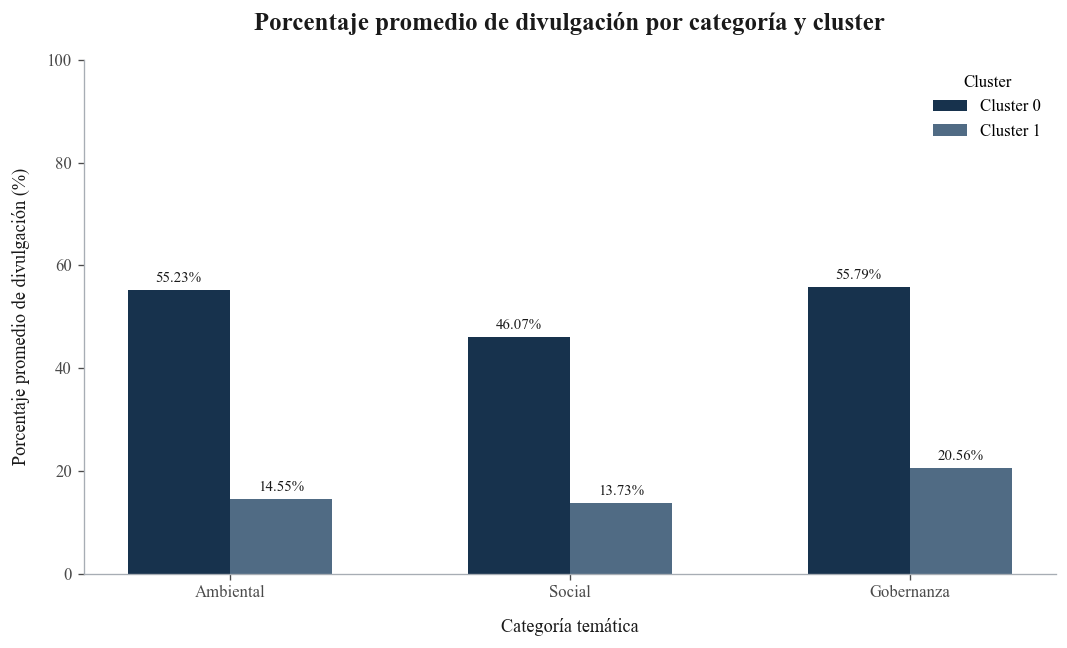

In [38]:
# Reorganizamos los resultados para facilitar
# la construcción de una gráfica de barras agrupadas
perfil_grafica_jerarquico = (
    perfil_categorias_jerarquico
    .pivot(
        index="Categoria",
        columns="Cluster_Jerarquico",
        values="Porcentaje_divulgacion"
    )
    .loc[
        ["Environment", "Social", "Governance"]
    ]
)

# Definimos las posiciones de las categorías
posiciones = np.arange(
    len(perfil_grafica_jerarquico.index)
)

# Definimos el ancho de las barras
# para representar los dos clusters
ancho = 0.30

# Utilizamos la misma paleta visual
# empleada previamente en el notebook
colores_clusters = [
    AZUL_MARINO,
    AZUL_SECUNDARIO
]

# Construimos la figura
fig, ax = plt.subplots(figsize=(9, 5.5))

# Desplazamos las barras para que queden
# centradas alrededor de cada categoría
desplazamientos = [
    -ancho / 2,
    ancho / 2
]

# Guardamos los grupos de barras
# para incorporar posteriormente sus etiquetas
barras_clusters = []

# Graficamos los valores de cada cluster
for cluster, desplazamiento, color in zip(
    [0, 1],
    desplazamientos,
    colores_clusters
):

    barras = ax.bar(
        posiciones + desplazamiento,
        perfil_grafica_jerarquico[cluster],
        width=ancho,
        color=color,
        label=f"Cluster {cluster}"
    )

    barras_clusters.append(barras)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Porcentaje promedio de divulgación por categoría y cluster",
    pad=18
)

ax.set_xlabel(
    "Categoría temática",
    labelpad=10
)

ax.set_ylabel(
    "Porcentaje promedio de divulgación (%)",
    labelpad=10
)

# Incorporamos los nombres de las categorías
# utilizando su traducción al español
ax.set_xticks(posiciones)

ax.set_xticklabels(
    ["Ambiental", "Social", "Gobernanza"]
)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Añadimos el porcentaje sobre cada barra
for barras in barras_clusters:

    for barra in barras:

        valor = barra.get_height()

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            color=NEGRO
        )

# Establecemos el eje vertical entre 0 y 100
ax.set_ylim(0, 100)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster"
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos
guardar_figura(
    fig,
    "jerarquico_perfil_categorias_clusters"
)

# Mostramos la figura
plt.show()

Los dos perfiles mantienen diferencias importantes en las tres categorías temáticas. El **Cluster 0**, correspondiente al perfil de mayor divulgación, presenta **55.79% en Gobernanza, 55.23% en Ambiental y 46.07% en Social**. En cambio, el **Cluster 1**, asociado con el perfil de menor divulgación, registra **20.56% en Gobernanza, 14.55% en Ambiental y 13.73% en Social**.

En ambos clusters se conserva el mismo orden entre categorías: **Gobernanza presenta el porcentaje más alto, seguida de Ambiental y Social**. Sin embargo, la diferencia entre los dos perfiles es considerable en las tres dimensiones y alcanza **40.68 puntos porcentuales en Ambiental, 35.23 en Gobernanza y 32.34 en Social**.

Por lo tanto, la solución jerárquica distingue principalmente a las empresas por la **intensidad general de su divulgación**, más que por la presencia de perfiles temáticos opuestos. El siguiente análisis permite identificar en qué indicadores específicos se concentran las mayores diferencias entre ambos grupos.

**Indicadores que más diferencian los perfiles**

Para precisar qué información distingue con mayor claridad a los dos perfiles, se comparan los porcentajes de divulgación de los **109 indicadores individuales** entre ambos clusters.

Para cada indicador se calcula la diferencia absoluta entre el porcentaje registrado por el Cluster 0 y el Cluster 1. Los indicadores con las diferencias más amplias permiten identificar los temas en los que la separación entre ambos perfiles resulta más marcada.

In [39]:
# Calculamos el porcentaje de divulgación de cada indicador
# dentro de cada uno de los dos clusters jerárquicos

perfil_indicadores_jerarquico = (
    X_largo_jerarquico
    .groupby(
        [
            "Indicador",
            "Cluster_Jerarquico"
        ],
        as_index=False
    )
    ["Divulga"]
    .mean()
)

# Convertimos las proporciones a porcentajes
perfil_indicadores_jerarquico[
    "Porcentaje_divulgacion"
] = (
    perfil_indicadores_jerarquico[
        "Divulga"
    ]
    .mul(100)
)

# Reorganizamos la información para que cada fila
# corresponda a un indicador y cada columna a un cluster
comparacion_indicadores_jerarquico = (
    perfil_indicadores_jerarquico
    .pivot(
        index="Indicador",
        columns="Cluster_Jerarquico",
        values="Porcentaje_divulgacion"
    )
    .reset_index()
)

# Renombramos las columnas para facilitar su interpretación
comparacion_indicadores_jerarquico.columns = [
    "Indicador",
    "Cluster_0",
    "Cluster_1"
]

# Calculamos la diferencia absoluta entre ambos perfiles
comparacion_indicadores_jerarquico[
    "Diferencia_pp"
] = (
    comparacion_indicadores_jerarquico[
        "Cluster_0"
    ]
    -
    comparacion_indicadores_jerarquico[
        "Cluster_1"
    ]
).abs()

# Ordenamos los indicadores desde la diferencia
# más grande hasta la más pequeña
comparacion_indicadores_jerarquico = (
    comparacion_indicadores_jerarquico
    .sort_values(
        "Diferencia_pp",
        ascending=False
    )
)

# Seleccionamos los diez indicadores que presentan
# las mayores diferencias entre los dos perfiles
top10_diferencias_jerarquico = (
    comparacion_indicadores_jerarquico
    .head(10)
    .copy()
)

# Redondeamos los porcentajes para facilitar su lectura
columnas_redondear = [
    "Cluster_0",
    "Cluster_1",
    "Diferencia_pp"
]

top10_diferencias_jerarquico[
    columnas_redondear
] = (
    top10_diferencias_jerarquico[
        columnas_redondear
    ]
    .round(2)
)

# Incorporamos la categoría temática correspondiente
# a cada uno de los indicadores
top10_diferencias_jerarquico[
    "Categoria"
] = (
    top10_diferencias_jerarquico[
        "Indicador"
    ]
    .map(mapa_categorias)
)


# Mostramos los resultados 
display(
    top10_diferencias_jerarquico[
        [
            "Indicador",
            "Categoria",
            "Cluster_0",
            "Cluster_1",
            "Diferencia_pp"
        ]
    ]
)

,Indicador,Categoria,Cluster_0,Cluster_1,Diferencia_pp
30,Fashion Revolution+Discloses Progress on Susta...,Environment,97.140,21.110,76.030
96,"Fashion Revolution+Scope, Process and Accredit...",Environment,97.140,22.780,74.370
32,Fashion Revolution+Discloses Progress to Reduc...,Environment,80.000,6.110,73.890
20,Fashion Revolution+Discloses Evidence of Devel...,Environment,90.000,17.220,72.780
104,Fashion Revolution+Targets to Reduce Textiles ...,Environment,84.290,13.330,70.950
9,Fashion Revolution+Describes Environmental Due...,Environment,98.570,30.000,68.570
103,Fashion Revolution+Sustainable Materials Strategy,Environment,98.570,32.780,65.790
76,Fashion Revolution+Prevention Mitigation and R...,Governance,78.570,12.780,65.790
92,Fashion Revolution+Reports on Efforts to Impro...,Social,87.140,21.670,65.480
22,Fashion Revolution+Discloses Gender Equality A...,Social,77.140,12.220,64.920


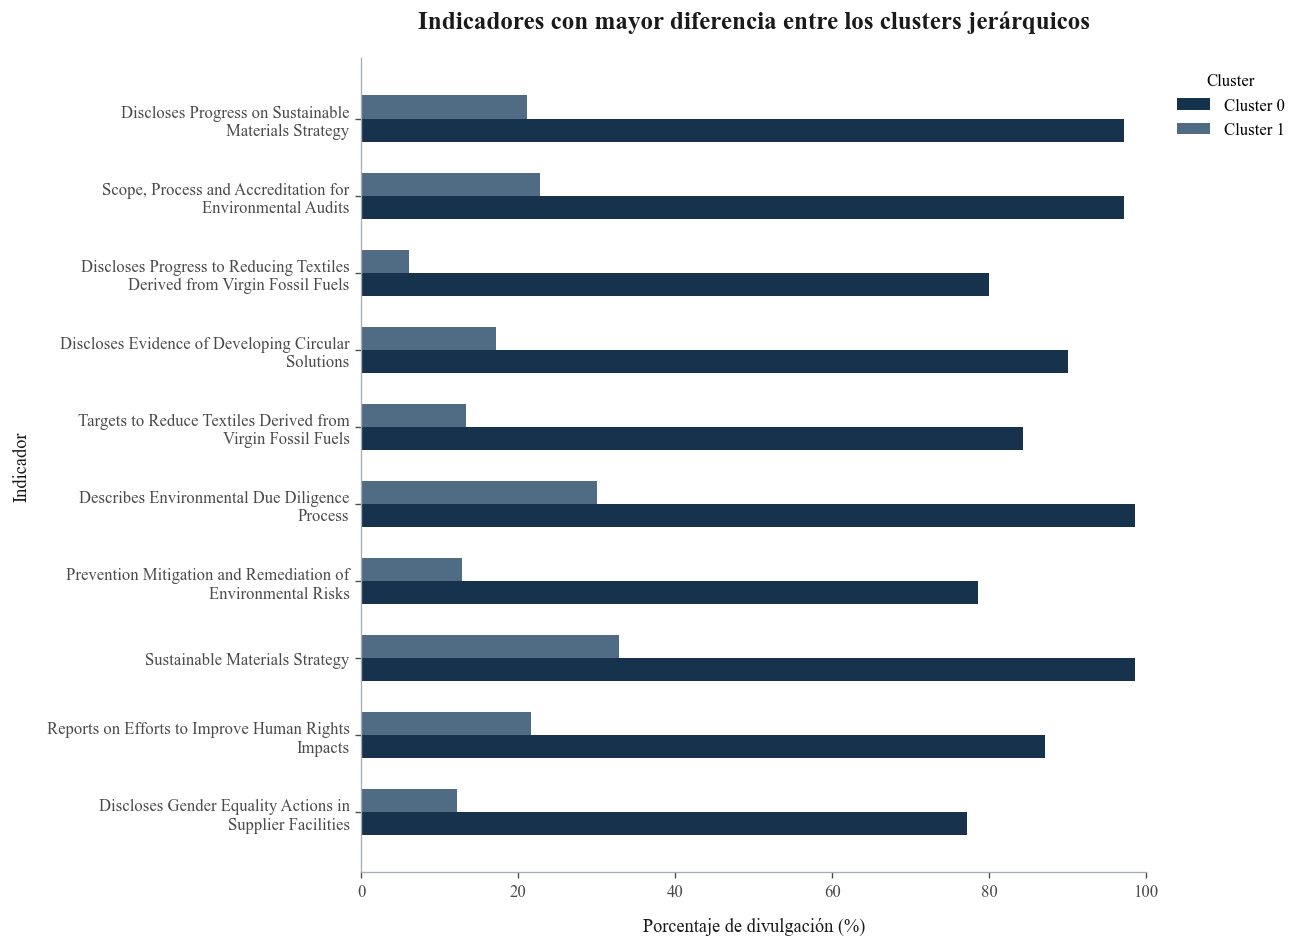

In [40]:
# Preparamos los diez indicadores con mayores diferencias
# para construir una gráfica comparable con la de K-Means

top_10_grafica_jerarquico = (
    top10_diferencias_jerarquico
    .copy()
)

# Eliminamos el prefijo "Fashion Revolution+"
# para hacer más legibles los nombres
top_10_grafica_jerarquico[
    "Indicador_visual"
] = (
    top_10_grafica_jerarquico[
        "Indicador"
    ]
    .str.replace(
        "Fashion Revolution+",
        "",
        regex=False
    )
)

# Dividimos los nombres largos en varias líneas
top_10_grafica_jerarquico[
    "Indicador_visual"
] = (
    top_10_grafica_jerarquico[
        "Indicador_visual"
    ]
    .apply(
        lambda texto: textwrap.fill(
            texto,
            width=42
        )
    )
)

# Ordenamos de menor a mayor diferencia
# para que la mayor aparezca en la parte superior
top_10_grafica_jerarquico = (
    top_10_grafica_jerarquico
    .sort_values(
        "Diferencia_pp",
        ascending=True
    )
    .reset_index(drop=True)
)

# Definimos las posiciones de los indicadores
posiciones = np.arange(
    len(top_10_grafica_jerarquico)
)

# Definimos el alto de las barras
alto = 0.30

# Construimos la figura
fig, ax = plt.subplots(
    figsize=(11, 8)
)

# Representamos el porcentaje del Cluster 0
barras_0 = ax.barh(
    posiciones - alto / 2,
    top_10_grafica_jerarquico["Cluster_0"],
    height=alto,
    color=AZUL_MARINO,
    label="Cluster 0"
)

# Representamos el porcentaje del Cluster 1
barras_1 = ax.barh(
    posiciones + alto / 2,
    top_10_grafica_jerarquico["Cluster_1"],
    height=alto,
    color=AZUL_SECUNDARIO,
    label="Cluster 1"
)

# Incorporamos los nombres de los indicadores
ax.set_yticks(posiciones)

ax.set_yticklabels(
    top_10_grafica_jerarquico[
        "Indicador_visual"
    ]
)

# Incorporamos el título y los nombres de los ejes
ax.set_title(
    "Indicadores con mayor diferencia entre los clusters jerárquicos",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de divulgación (%)",
    labelpad=10
)

ax.set_ylabel(
    "Indicador",
    labelpad=10
)

# Establecemos el eje horizontal entre 0 y 100
ax.set_xlim(0, 100)

# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)

# Incorporamos la leyenda
ax.legend(
    frameon=False,
    title="Cluster",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

# Ajustamos los márgenes
fig.tight_layout()

# Guardamos la figura
guardar_figura(
    fig,
    "jerarquico_top_10_diferencias_indicadores"
)

# Mostramos la figura
plt.show()

Los diez indicadores con mayores diferencias entre los dos perfiles presentan brechas de entre **64.92 y 76.03 puntos porcentuales**. De ellos, **siete pertenecen a Environment, dos a Social y uno a Governance**, por lo que las diferencias más amplias se concentran principalmente en indicadores ambientales. Aunque Gobernanza presentó el mayor nivel promedio de divulgación en ambos clusters, solo uno de los diez indicadores con mayores diferencias pertenece a esta categoría.

Así, entre los indicadores que más distinguen a los grupos se encuentran *Discloses Progress on Sustainable Materials Strategy* (divulga avances en la estrategia de materiales sostenibles), *Scope, Process and Accreditation for Environmental Audits* (alcance, proceso y acreditación de auditorías ambientales), *Discloses Progress to Reducing Textiles Derived from Virgin Fossil Fuels* (divulga avances en la reducción de textiles derivados de combustibles fósiles vírgenes), *Discloses Evidence of Developing Circular Solutions* (divulga evidencia del desarrollo de soluciones circulares) y *Targets to Reduce Textiles Derived from Virgin Fossil Fuels* (objetivos para reducir textiles derivados de combustibles fósiles vírgenes). También aparecen indicadores relacionados con **debida diligencia ambiental, prevención, mitigación y remediación de riesgos de derechos humanos, esfuerzos para mejorar sus impactos e igualdad de género**.

En estos diez indicadores, el **Cluster 0**, correspondiente al perfil de mayor divulgación, registra porcentajes de entre **77.14% y 98.57%**. En contraste, el **Cluster 1**, asociado con el perfil de menor divulgación, presenta valores de entre **6.11% y 32.78%**. Esto muestra que la separación entre ambos perfiles no se limita a su porcentaje general de divulgación, sino que también se refleja con claridad en información específica sobre **materiales sostenibles, circularidad, reducción del uso de combustibles fósiles, auditorías, debida diligencia ambiental y gestión de riesgos de derechos humanos**.

**Comprobación del patrón de divulgación en los 109 indicadores**

Hasta este punto, el **Cluster 0** presenta un nivel general de divulgación superior al Cluster 1, tanto en el promedio total como en las tres categorías temáticas. Para comprobar si esta diferencia se mantiene también a nivel de los indicadores individuales, se revisa el porcentaje de divulgación de los **109 indicadores** en ambos perfiles.

Esta verificación permite determinar si la separación obtenida mediante clustering jerárquico corresponde de manera consistente a un perfil de mayor y otro de menor divulgación, o si existen indicadores específicos en los que el patrón se invierte.

In [42]:
# Comprobamos si el patrón general observado entre los dos clusters
# se mantiene también en cada uno de los 109 indicadores

# De acuerdo con los resultados anteriores:
# Cluster 0 = mayor divulgación
# Cluster 1 = menor divulgación
comparacion_indicadores_jerarquico[
    "Orden_esperado"
] = (
    comparacion_indicadores_jerarquico[
        "Cluster_0"
    ]
    >=
    comparacion_indicadores_jerarquico[
        "Cluster_1"
    ]
)

# Contamos cuántos indicadores mantienen
# el orden observado entre ambos perfiles
indicadores_orden_jerarquico = (
    comparacion_indicadores_jerarquico[
        "Orden_esperado"
    ]
    .sum()
)

# Recuperamos el número total de indicadores
indicadores_total_jerarquico = len(
    comparacion_indicadores_jerarquico
)

# Mostramos el número de indicadores
# que conservan el patrón general
print(
    "Indicadores que mantienen el orden "
    "Cluster 0 >= Cluster 1:",
    indicadores_orden_jerarquico,
    "de",
    indicadores_total_jerarquico
)

# Identificamos los indicadores en los que
# el perfil de menor divulgación supera al de mayor divulgación
excepciones_jerarquico = (
    comparacion_indicadores_jerarquico[
        ~comparacion_indicadores_jerarquico[
            "Orden_esperado"
        ]
    ]
    .copy()
)


print(
    "Indicadores que no mantienen este orden:",
    len(excepciones_jerarquico)
)

# Incorporamos la categoría temática
# para facilitar la interpretación de las excepciones
excepciones_jerarquico[
    "Categoria"
] = (
    excepciones_jerarquico[
        "Indicador"
    ]
    .map(mapa_categorias)
)

Indicadores que mantienen el orden Cluster 0 >= Cluster 1: 109 de 109
Indicadores que no mantienen este orden: 0


La separación entre los dos perfiles se mantiene en los **109 indicadores analizados**. En todos ellos, el porcentaje de divulgación del **Cluster 0** es igual o superior al registrado por el **Cluster 1**; por lo tanto, no se identificó ningún indicador en el que el perfil de menor divulgación supere al perfil de mayor divulgación.

Este resultado confirma que la estructura obtenida mediante clustering jerárquico responde de manera muy consistente a una diferencia en la **intensidad de divulgación**. El Cluster 0 no presenta únicamente un promedio general más alto, sino que mantiene niveles iguales o superiores a los del Cluster 1 a lo largo de toda la matriz de indicadores. En consecuencia, los dos grupos pueden caracterizarse con claridad como un perfil de **mayor divulgación** y otro de **menor divulgación**.

**Indicadores con mayor y menor divulgación dentro de cada perfil**

Una vez comprobado que el perfil de mayor divulgación mantiene porcentajes iguales o superiores en los **109 indicadores**, se examinan ahora los extremos de cada cluster.

Para cada perfil se identifican los **diez indicadores con mayor porcentaje de divulgación** y los **diez con menor porcentaje**. Esta revisión permite conocer qué información aparece con mayor frecuencia dentro de cada grupo y, al mismo tiempo, detectar los temas que continúan poco divulgados incluso entre las empresas pertenecientes al perfil de mayor divulgación.

In [43]:
# Identificamos los indicadores con mayor y menor
# porcentaje de divulgación dentro de cada perfil jerárquico

# Partimos de la comparación construida previamente,
# que contiene el porcentaje de divulgación
# de cada indicador en ambos clusters
perfil_indicadores_extremos_jerarquico = (
    comparacion_indicadores_jerarquico
    .copy()
)

# Incorporamos la categoría temática correspondiente
# a cada indicador
perfil_indicadores_extremos_jerarquico[
    "Categoria"
] = (
    perfil_indicadores_extremos_jerarquico[
        "Indicador"
    ]
    .map(mapa_categorias)
)

# Relacionamos cada cluster con la columna
# que contiene sus porcentajes de divulgación
columnas_perfiles_jerarquico = {
    0: "Cluster_0",
    1: "Cluster_1"
}

# Creamos estructuras donde almacenaremos
# los indicadores más y menos divulgados
top_indicadores_jerarquico = {}
bottom_indicadores_jerarquico = {}

# Recorremos los dos perfiles
for cluster, columna in columnas_perfiles_jerarquico.items():

    # Seleccionamos los diez indicadores
    # con mayor divulgación dentro del cluster
    top_indicadores_jerarquico[cluster] = (
        perfil_indicadores_extremos_jerarquico[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=False
        )
        .head(10)
        .reset_index(drop=True)
    )

    # Seleccionamos los diez indicadores
    # con menor divulgación dentro del cluster
    bottom_indicadores_jerarquico[cluster] = (
        perfil_indicadores_extremos_jerarquico[
            [
                "Indicador",
                "Categoria",
                columna
            ]
        ]
        .sort_values(
            columna,
            ascending=True
        )
        .head(10)
        .reset_index(drop=True)
    )

# Mostramos los resultados correspondientes
# a cada uno de los dos perfiles
for cluster in [0, 1]:

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MAYOR DIVULGACIÓN"
    )

    display(
        top_indicadores_jerarquico[
            cluster
        ]
    )

    print(
        f"\nCLUSTER {cluster} - "
        "INDICADORES CON MENOR DIVULGACIÓN"
    )

    display(
        bottom_indicadores_jerarquico[
            cluster
        ]
    )


CLUSTER 0 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+New Production Facility Cri...,Social,100.000
1,Fashion Revolution+Describes Human Rights Due ...,Social,100.000
2,Fashion Revolution+Supply Chain Policies Align...,Governance,100.000
3,Fashion Revolution+Plan for Improving Environm...,Environment,98.571
4,Fashion Revolution+Describes Environmental Due...,Environment,98.571
5,Fashion Revolution+Sustainable Materials Strategy,Environment,98.571
6,Fashion Revolution+Discloses Progress on Susta...,Environment,97.143
7,"Fashion Revolution+Scope, Process and Accredit...",Environment,97.143
8,Fashion Revolution+Reports on Efforts to Impro...,Environment,97.143
9,Fashion Revolution+Human Rights Risks Impacts ...,Social,95.714



CLUSTER 0 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_0
0,Fashion Revolution+Publishes Standard Supplier...,Governance,1.429
1,Fashion Revolution+Commitment to Degrowth,Environment,1.429
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,1.429
3,Fashion Revolution+Discloses Progress toward t...,Social,2.857
4,Fashion Revolution+Discloses Strategy to Achie...,Social,4.286
5,Fashion Revolution+Publishes Percentage or Num...,Social,4.286
6,Fashion Revolution+Discloses Number of Collect...,Social,4.286
7,Fashion Revolution+Discloses Percentage of Wor...,Environment,5.714
8,Fashion Revolution+Reports on Minimum Wage Pai...,Social,5.714
9,Fashion Revolution+Discloses Free on Board (FO...,Governance,7.143



CLUSTER 1 - INDICADORES CON MAYOR DIVULGACIÓN


,Indicador,Categoria,Cluster_1
0,Fashion Revolution+Supply Chain Policies Align...,Governance,65.556
1,Fashion Revolution+Supply Chain Policies Are C...,Governance,62.778
2,Fashion Revolution+Plan for Improving Environm...,Environment,61.111
3,Fashion Revolution+Grievance Mechanism - Direc...,Social,57.778
4,Fashion Revolution+Implementation of Board Lev...,Governance,56.111
5,Fashion Revolution+Describes Human Rights Due ...,Social,55.000
6,Fashion Revolution+Grievance Mechanism - Suppl...,Social,50.000
7,Fashion Revolution+New Production Facility Cri...,Social,49.444
8,Fashion Revolution+Accountable Board Member Id...,Governance,47.778
9,Fashion Revolution+Reports on Efforts to Impro...,Environment,47.222



CLUSTER 1 - INDICADORES CON MENOR DIVULGACIÓN


,Indicador,Categoria,Cluster_1
0,Fashion Revolution+Publishes Percentage of Wor...,Social,0.000
1,Fashion Revolution+Discloses Proportion of Wor...,Social,0.000
2,Fashion Revolution+Publishes Percentage or Num...,Social,0.000
3,Fashion Revolution+Discloses Number of Collect...,Social,0.000
4,Fashion Revolution+Discloses Percentage of Wor...,Environment,0.000
5,Fashion Revolution+Reports on Minimum Wage Pai...,Social,0.000
6,Fashion Revolution+Discloses Free on Board (FO...,Governance,0.000
7,Fashion Revolution+Discloses Quantity of Order...,Social,0.000
8,Fashion Revolution+Discloses Quantity of Order...,Social,0.000
9,Fashion Revolution+Discloses Coal Use,Environment,0.556


El análisis de los indicadores extremos permite precisar las características de los dos perfiles identificados mediante clustering jerárquico. La diferencia entre ambos grupos no se limita a su porcentaje promedio general, sino que también se observa en **qué información alcanza niveles elevados de divulgación y qué temas permanecen prácticamente ausentes dentro de cada perfil**.

En el **Cluster 0**, correspondiente al perfil de mayor divulgación, los diez indicadores más frecuentes presentan porcentajes entre **95.71% y 100%**. Tres alcanzan **100%**: *New Production Facility Criteria* (criterios para nuevas instalaciones de producción), *Describes Human Rights Due Diligence Process* (describe el proceso de debida diligencia en derechos humanos) y *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales). También destacan indicadores relacionados con **planes y debida diligencia ambiental, estrategias de materiales sostenibles, auditorías ambientales, seguimiento de avances e identificación de riesgos de derechos humanos**. De los diez indicadores con mayor divulgación en este perfil, **seis pertenecen a Environment, tres a Social y uno a Governance**.

Sin embargo, el alto nivel general de este cluster **no implica una divulgación elevada en todos los temas**. Sus diez indicadores menos frecuentes registran únicamente entre **1.43% y 7.14%**. En este grupo aparecen principalmente indicadores relacionados con **salarios dignos, remuneración de trabajadores, acuerdos y pagos a proveedores y determinadas prácticas de compra**. Por lo tanto, incluso entre las empresas del perfil de mayor divulgación permanecen áreas específicas con una presencia muy reducida de información pública.

El **Cluster 1**, correspondiente al perfil de menor divulgación, presenta una situación distinta. Incluso sus diez indicadores más frecuentes alcanzan porcentajes de solo **47.22% a 65.56%**. Los valores más altos corresponden a *Supply Chain Policies Align with International Standards* (las políticas de la cadena de suministro se alinean con estándares internacionales), con **65.56%**; *Supply Chain Policies Are Contractual* (las políticas de la cadena de suministro forman parte de los contratos con proveedores), con **62.78%**; y *Plan for Improving Environmental Impacts* (plan para mejorar los impactos ambientales), con **61.11%**. También aparecen mecanismos de queja, responsabilidades a nivel del consejo, debida diligencia en derechos humanos y criterios para nuevas instalaciones de producción. En este caso, los diez indicadores principales se distribuyen entre **cuatro de Governance, cuatro de Social y dos de Environment**.

La baja divulgación del Cluster 1 se hace todavía más evidente al observar sus indicadores menos frecuentes: **nueve de los diez registran 0%**, mientras que el restante alcanza únicamente **0.56%**. Estos indicadores se concentran principalmente en información social específica, como **salarios, formas de remuneración y condiciones laborales**, además de algunos aspectos ambientales y de prácticas comerciales.

En conjunto, los resultados muestran dos perfiles claramente diferenciados. El **Cluster 0** presenta una divulgación muy amplia en determinados procesos, políticas y mecanismos formales, aunque conserva vacíos importantes en temas específicos. El **Cluster 1**, en cambio, mantiene niveles considerablemente menores incluso en sus indicadores más frecuentes y presenta una ausencia prácticamente total de información en varios indicadores. Esto refuerza la interpretación obtenida previamente: la solución jerárquica distingue principalmente a las empresas según la **intensidad de su divulgación**, aunque el análisis de los extremos permite identificar con mayor precisión **qué información caracteriza y qué información permanece ausente dentro de cada perfil**.

**Contraste entre la divulgación global y los perfiles jerárquicos**

Los diez indicadores con mayor y menor divulgación global fueron identificados previamente durante la caracterización de K-Means. Debido a que estos porcentajes se calculan sobre las mismas **250 empresas** y los mismos **109 indicadores**, no es necesario volver a estimarlos.

A continuación, se recuperan esos mismos indicadores y se incorporan únicamente los porcentajes correspondientes a los dos perfiles jerárquicos, con el propósito de observar cómo se distribuye la divulgación global entre el perfil de mayor divulgación y el de menor divulgación.

In [46]:
# Recuperamos los indicadores globales identificados previamente
# y añadimos los porcentajes correspondientes
# a los dos perfiles jerárquicos

top_10_global_jerarquico = (
    top_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global"
        ]
    ]
    .merge(
        comparacion_indicadores_jerarquico[
            [
                "Indicador",
                "Cluster_0",
                "Cluster_1"
            ]
        ],
        on="Indicador",
        how="left"
    )
)

bottom_10_global_jerarquico = (
    bottom_10_global[
        [
            "Indicador",
            "Categoria",
            "Porcentaje_global"
        ]
    ]
    .merge(
        comparacion_indicadores_jerarquico[
            [
                "Indicador",
                "Cluster_0",
                "Cluster_1"
            ]
        ],
        on="Indicador",
        how="left"
    )
)


# Calculamos la diferencia entre los dos perfiles
for tabla in [
    top_10_global_jerarquico,
    bottom_10_global_jerarquico
]:

    tabla["Diferencia_perfiles_pp"] = (
        tabla["Cluster_0"]
        -
        tabla["Cluster_1"]
    ).abs()

    tabla[
        [
            "Porcentaje_global",
            "Cluster_0",
            "Cluster_1",
            "Diferencia_perfiles_pp"
        ]
    ] = (
        tabla[
            [
                "Porcentaje_global",
                "Cluster_0",
                "Cluster_1",
                "Diferencia_perfiles_pp"
            ]
        ]
        .round(2)
    )


print(
    "INDICADORES CON MAYOR DIVULGACIÓN GLOBAL"
)

display(
    top_10_global_jerarquico
)


print(
    "INDICADORES CON MENOR DIVULGACIÓN GLOBAL"
)

display(
    bottom_10_global_jerarquico
)

INDICADORES CON MAYOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Diferencia_perfiles_pp
0,Fashion Revolution+Supply Chain Policies Align...,Governance,75.200,100.000,65.560,34.440
1,Fashion Revolution+Plan for Improving Environm...,Environment,71.600,98.570,61.110,37.460
2,Fashion Revolution+Supply Chain Policies Are C...,Governance,71.200,92.860,62.780,30.080
3,Fashion Revolution+Describes Human Rights Due ...,Social,67.600,100.000,55.000,45.000
4,Fashion Revolution+Grievance Mechanism - Direc...,Social,67.200,91.430,57.780,33.650
5,Fashion Revolution+Implementation of Board Lev...,Governance,66.000,91.430,56.110,35.320
6,Fashion Revolution+New Production Facility Cri...,Social,63.600,100.000,49.440,50.560
7,Fashion Revolution+Reports on Efforts to Impro...,Environment,61.200,97.140,47.220,49.920
8,Fashion Revolution+Grievance Mechanism - Suppl...,Social,61.200,90.000,50.000,40.000
9,Fashion Revolution+Discloses Content of Scope ...,Environment,59.600,92.860,46.670,46.190


INDICADORES CON MENOR DIVULGACIÓN GLOBAL


,Indicador,Categoria,Porcentaje_global,Cluster_0,Cluster_1,Diferencia_perfiles_pp
0,Fashion Revolution+Commitment to Degrowth,Environment,0.800,1.430,0.560,0.870
1,Fashion Revolution+Publishes Standard Supplier...,Governance,0.800,1.430,0.560,0.870
2,Fashion Revolution+Discloses Policy on Up-Fron...,Governance,0.800,1.430,0.560,0.870
3,Fashion Revolution+Discloses Number of Collect...,Social,1.200,4.290,0.000,4.290
4,Fashion Revolution+Publishes Percentage or Num...,Social,1.200,4.290,0.000,4.290
5,Fashion Revolution+Discloses Progress toward t...,Social,1.600,2.860,1.110,1.750
6,Fashion Revolution+Reports on Minimum Wage Pai...,Social,1.600,5.710,0.000,5.710
7,Fashion Revolution+Discloses Percentage of Wor...,Environment,1.600,5.710,0.000,5.710
8,Fashion Revolution+Discloses Strategy to Achie...,Social,2.000,4.290,1.110,3.170
9,Fashion Revolution+Discloses Free on Board (FO...,Governance,2.000,7.140,0.000,7.140


La comparación entre los porcentajes globales y los perfiles jerárquicos muestra que los indicadores con mayor divulgación en el conjunto de la muestra no presentan el mismo comportamiento en ambos clusters. Entre los **diez indicadores con mayor divulgación global**, cuyos porcentajes se encuentran entre **59.60% y 75.20%**, el **Cluster 0** registra valores de entre **90.00% y 100%**, mientras que el **Cluster 1** alcanza únicamente entre **46.67% y 65.56%**. Las diferencias entre ambos perfiles oscilan entre **30.08 y 50.56 puntos porcentuales**.

Por ejemplo, *New Production Facility Criteria* (criterios para nuevas instalaciones de producción) presenta una divulgación global de **63.60%**, pero alcanza **100%** dentro del perfil de mayor divulgación y **49.44%** en el perfil de menor divulgación, una diferencia de **50.56 puntos porcentuales**. De manera similar, *Reports on Efforts to Improve Environmental Impacts* (reporta esfuerzos para mejorar los impactos ambientales) pasa de un porcentaje global de **61.20%** a **97.14%** en el Cluster 0 y **47.22%** en el Cluster 1.

Estos resultados muestran que un porcentaje global relativamente alto puede ocultar **diferencias importantes entre tipos de empresas**. Parte de la elevada divulgación observada en el conjunto de las 250 compañías se concentra en el perfil de mayor divulgación, mientras que las empresas del Cluster 1 presentan porcentajes considerablemente menores incluso en varios de los indicadores mejor posicionados globalmente.

El comportamiento cambia al observar los **diez indicadores con menor divulgación global**. En este grupo, cuyos porcentajes agregados se encuentran entre **0.80% y 2.00%**, los valores permanecen muy reducidos en ambos perfiles. El Cluster 0 alcanza como máximo **7.14%**, mientras que el Cluster 1 no supera **1.11%** y registra **0% en cinco de los diez indicadores**.

Entre estos temas aparecen nuevamente indicadores relacionados con **salarios dignos, modalidades de remuneración, acuerdos y pagos a proveedores y prácticas comerciales específicas**. Por lo tanto, su baja divulgación no se explica únicamente por la presencia de empresas pertenecientes al perfil de menor divulgación: estos temas continúan siendo poco reportados incluso dentro del grupo que presenta los mayores niveles de transparencia.

En este contexto, el clustering jerárquico permite distinguir **dos situaciones diferentes detrás de los porcentajes globales**. En algunos indicadores con alta divulgación agregada existen brechas amplias entre los perfiles, mientras que los indicadores con menor divulgación permanecen prácticamente ausentes en ambos grupos. Así, la segmentación permite identificar qué niveles globales esconden heterogeneidad entre empresas y qué temas presentan una baja divulgación más generalizada.

### Distribución de los perfiles por país de sede

Después de caracterizar los dos perfiles a partir de sus patrones de divulgación, se incorpora el **país de sede** como una variable descriptiva externa al agrupamiento. Esta información no fue utilizada para construir los clusters, por lo que su análisis permite observar cómo se distribuyen posteriormente las empresas de cada país entre el perfil de **mayor divulgación (Cluster 0)** y el de **menor divulgación (Cluster 1)**.

Para cada país se calcula tanto el **número de empresas asignadas a cada perfil** como el porcentaje que representan dentro del total nacional. De esta manera, es posible identificar si las empresas con una misma sede se concentran principalmente en uno de los dos grupos o si presentan patrones de divulgación heterogéneos.

In [44]:
# Analizamos la distribución de las empresas de cada país
# entre los dos perfiles identificados mediante
# clustering jerárquico

# Contamos el número de empresas correspondiente
# a cada combinación de país y cluster
distribucion_pais_jerarquico = (
    resultado_jerarquico
    .groupby(
        [
            "Pais_sede",
            "Cluster_Jerarquico"
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

# Reordenamos los clusters de acuerdo con
# los perfiles identificados previamente:
# Cluster 1 = menor divulgación
# Cluster 0 = mayor divulgación
distribucion_pais_jerarquico = (
    distribucion_pais_jerarquico
    .reindex(
        columns=[1, 0],
        fill_value=0
    )
)

# Renombramos las columnas utilizando
# los perfiles que representan
distribucion_pais_jerarquico.columns = [
    "Menor_divulgacion",
    "Mayor_divulgacion"
]

# Calculamos el número total de empresas
# correspondiente a cada país
distribucion_pais_jerarquico[
    "Total_empresas"
] = (
    distribucion_pais_jerarquico[
        [
            "Menor_divulgacion",
            "Mayor_divulgacion"
        ]
    ]
    .sum(axis=1)
)

# Calculamos el peso porcentual de cada perfil
# dentro del total de empresas de cada país
for perfil in [
    "Menor_divulgacion",
    "Mayor_divulgacion"
]:

    distribucion_pais_jerarquico[
        f"Porcentaje_{perfil}"
    ] = (
        distribucion_pais_jerarquico[
            perfil
        ]
        /
        distribucion_pais_jerarquico[
            "Total_empresas"
        ]
        *
        100
    )

# Redondeamos los porcentajes
# para facilitar su presentación
columnas_porcentaje_jerarquico = [
    "Porcentaje_Menor_divulgacion",
    "Porcentaje_Mayor_divulgacion"
]

distribucion_pais_jerarquico[
    columnas_porcentaje_jerarquico
] = (
    distribucion_pais_jerarquico[
        columnas_porcentaje_jerarquico
    ]
    .round(2)
)

# Recuperamos el país como una columna
distribucion_pais_jerarquico = (
    distribucion_pais_jerarquico
    .reset_index()
)

# Ordenamos los países comenzando por aquellos
# con mayor número de empresas en la muestra
distribucion_pais_jerarquico = (
    distribucion_pais_jerarquico
    .sort_values(
        [
            "Total_empresas",
            "Pais_sede"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

# Organizamos las columnas de manera que primero
# aparezcan los conteos y después los porcentajes
distribucion_pais_jerarquico = (
    distribucion_pais_jerarquico[
        [
            "Pais_sede",
            "Total_empresas",
            "Menor_divulgacion",
            "Mayor_divulgacion",
            "Porcentaje_Menor_divulgacion",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
)

# Mostramos la distribución completa
display(
    distribucion_pais_jerarquico
)

# Comprobamos que se mantengan las
# 250 empresas y los 27 países de la muestra
print(
    "Total de empresas:",
    distribucion_pais_jerarquico[
        "Total_empresas"
    ].sum()
)

print(
    "Total de países:",
    distribucion_pais_jerarquico[
        "Pais_sede"
    ].nunique()
)

,Pais_sede,Total_empresas,Menor_divulgacion,Mayor_divulgacion,Porcentaje_Menor_divulgacion,Porcentaje_Mayor_divulgacion
0,Estados Unidos,85,67,18,78.820,21.180
1,Reino Unido,27,18,9,66.670,33.330
2,Francia,21,11,10,52.380,47.620
3,Italia,20,15,5,75.000,25.000
4,Alemania,18,13,5,72.220,27.780
5,España,11,5,6,45.450,54.550
6,Japón,10,7,3,70.000,30.000
7,Canadá,9,6,3,66.670,33.330
8,China,9,9,0,100.000,0.000
9,Suiza,5,3,2,60.000,40.000


Total de empresas: 250
Total de países: 27


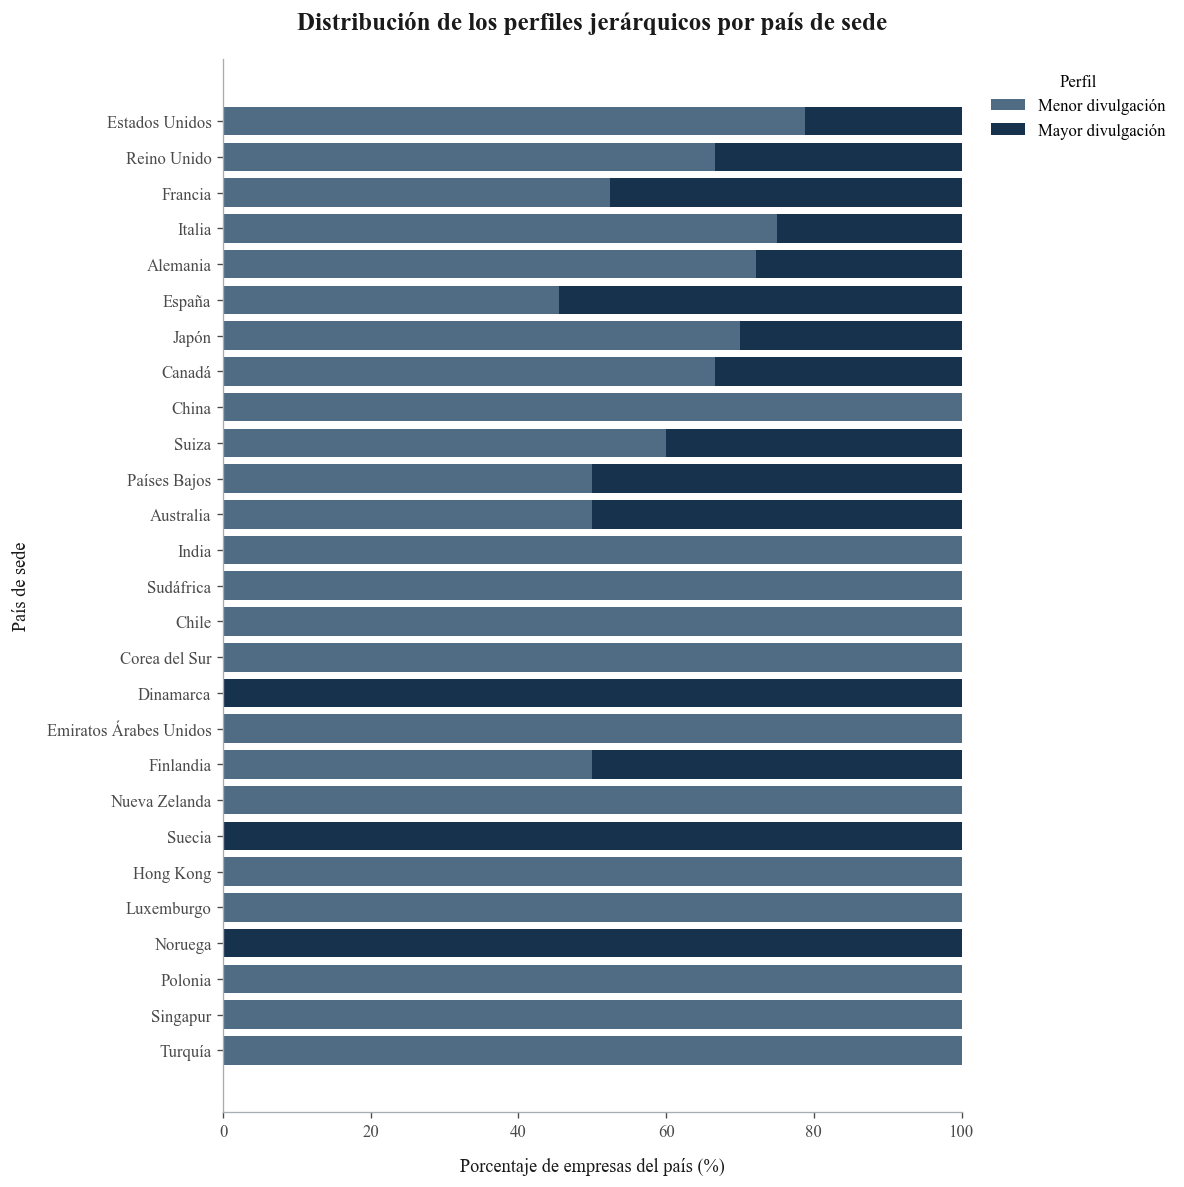

In [45]:
# Visualizamos la composición porcentual de los dos
# perfiles jerárquicos dentro de cada país de sede

# Conservamos las variables necesarias
# para construir la figura
distribucion_pais_grafica_jerarquico = (
    distribucion_pais_jerarquico[
        [
            "Pais_sede",
            "Total_empresas",
            "Porcentaje_Menor_divulgacion",
            "Porcentaje_Mayor_divulgacion"
        ]
    ]
    .copy()
)


# Ordenamos de menor a mayor número de empresas
# para que los países con mayor representación
# aparezcan en la parte superior de la gráfica
distribucion_pais_grafica_jerarquico = (
    distribucion_pais_grafica_jerarquico
    .sort_values(
        "Total_empresas",
        ascending=True
    )
    .reset_index(drop=True)
)


# Definimos una posición para cada país
posiciones = np.arange(
    len(
        distribucion_pais_grafica_jerarquico
    )
)


# Construimos la figura
fig, ax = plt.subplots(
    figsize=(10, 10)
)


# Primera sección:
# perfil de menor divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica_jerarquico[
        "Porcentaje_Menor_divulgacion"
    ],
    color=AZUL_SECUNDARIO,
    label="Menor divulgación"
)


# Segunda sección:
# perfil de mayor divulgación
ax.barh(
    posiciones,
    distribucion_pais_grafica_jerarquico[
        "Porcentaje_Mayor_divulgacion"
    ],
    left=distribucion_pais_grafica_jerarquico[
        "Porcentaje_Menor_divulgacion"
    ],
    color=AZUL_MARINO,
    label="Mayor divulgación"
)


# Incorporamos los nombres de los países
ax.set_yticks(
    posiciones
)

ax.set_yticklabels(
    distribucion_pais_grafica_jerarquico[
        "Pais_sede"
    ]
)


# Incorporamos título y nombres de los ejes
ax.set_title(
    "Distribución de los perfiles jerárquicos por país de sede",
    pad=18
)

ax.set_xlabel(
    "Porcentaje de empresas del país (%)",
    labelpad=10
)

ax.set_ylabel(
    "País de sede",
    labelpad=10
)


# Utilizamos una escala de 0 a 100
# porque cada barra representa la composición
# porcentual completa de un país
ax.set_xlim(
    0,
    100
)


# Eliminamos los bordes que no aportan información
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRIS_MEDIO)
ax.spines["bottom"].set_color(GRIS_MEDIO)


# Colocamos la leyenda fuera de la gráfica
ax.legend(
    frameon=False,
    title="Perfil",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)


# Ajustamos los márgenes
fig.tight_layout()


# Guardamos la figura
guardar_figura(
    fig,
    "jerarquico_distribucion_perfiles_pais"
)


# Mostramos la figura
plt.show()

La distribución por país muestra que los dos perfiles jerárquicos **no se concentran de manera uniforme según el país de sede**. Entre los diez países con al menos cinco empresas en la muestra, **nueve presentan compañías en ambos perfiles**. La única excepción es **China**, cuyas nueve empresas pertenecen al perfil de menor divulgación. Por lo tanto, para la mayoría de los países con mayor representación existe heterogeneidad entre las empresas que un promedio nacional puede ocultar.

Esta situación se observa con claridad en **Estados Unidos**, que reúne 85 empresas: **67 (78.82%)** pertenecen al perfil de menor divulgación y **18 (21.18%)** al de mayor divulgación. Entre los demás países con mayor representación también predominan, en general, las empresas del perfil de menor divulgación: representan **66.67% en Reino Unido, 75.00% en Italia, 72.22% en Alemania, 70.00% en Japón y 66.67% en Canadá**. Francia presenta una distribución más equilibrada, con **52.38%** de sus empresas en el perfil de menor divulgación y **47.62%** en el de mayor divulgación.

**España** constituye una excepción dentro de los países con mayor número de empresas, ya que **6 de sus 11 compañías (54.55%)** pertenecen al perfil de mayor divulgación. Por su parte, **China** concentra el **100%** de sus nueve empresas en el perfil de menor divulgación. Estas diferencias muestran que la composición de los perfiles varía entre países, pero también que dentro de una misma sede nacional pueden coexistir empresas con patrones de divulgación distintos.

Al considerar conjuntamente los cinco países europeos con mayor representación (**Reino Unido, Francia, Italia, Alemania y España**), se reúnen **97 empresas**. De ellas, **62 (63.92%)** pertenecen al perfil de menor divulgación y **35 (36.08%)** al de mayor divulgación. Por lo tanto, aunque algunos de estos países presentaron niveles promedio relativamente elevados en el análisis exploratorio, la solución jerárquica confirma que **un promedio nacional alto no implica que la mayoría de sus empresas pertenezca al perfil de mayor divulgación**.

En este contexto, la lectura institucional es consistente con la obtenida mediante K-Means. **España y Francia presentan las mayores proporciones de empresas en el perfil jerárquico de mayor divulgación entre los cinco países europeos con mayor representación**, mientras que en Reino Unido, Alemania e Italia predomina el perfil de menor divulgación. Como se analizó previamente, España, Francia y Alemania cuentan con requerimientos nacionales que presentan una correspondencia relativamente directa con diversos indicadores del FTI, mientras que Reino Unido combina obligaciones específicas sobre cadena de suministro, gobierno corporativo y clima y, para Italia, la revisión identificó principalmente la base común europea de información no financiera (Jefatura del Estado, 2018; República Francesa, 2017; República Federal de Alemania, 2021; UK Parliament, 2015; UK Government, 2022). No obstante, la solución jerárquica resume estas diferencias en únicamente dos perfiles, por lo que ofrece una separación más general y pierde parte de la gradación que K-Means permite distinguir entre empresas de divulgación muy baja, intermedia y mayor.

Finalmente, los porcentajes correspondientes a países con pocas empresas deben interpretarse con cautela. Casos como Dinamarca, Noruega o Suecia presentan una elevada proporción de empresas en el perfil de mayor divulgación, pero están representados únicamente por una o dos compañías, por lo que estos porcentajes no permiten caracterizar de manera general a las empresas de dichos países.

### Conclusión de los perfiles identificados con clustering jerárquico

El clustering jerárquico identificó dos perfiles caracterizados principalmente por una diferencia en la **intensidad de divulgación: mayor y menor divulgación**. Esta separación es particularmente consistente, ya que el perfil de mayor divulgación mantiene porcentajes iguales o superiores en los **109 indicadores analizados**, mientras que ambos grupos conservan una estructura temática similar entre Ambiental, Social y Gobernanza.

A pesar de esta diferencia general, el perfil de mayor divulgación también presenta vacíos importantes en temas específicos, especialmente en información relacionada con salarios, remuneración, prácticas de compra y relaciones con proveedores. Por lo tanto, la pertenencia al perfil de mayor divulgación representa una mayor amplitud de información publicada, pero no una divulgación elevada en todos los indicadores.

En este sentido, la solución jerárquica proporciona una **segmentación más amplia y menos detallada que K-Means**, al concentrar a las empresas en dos perfiles generales. Para los datos del *Fashion Transparency Index 2023*, el método permitió identificar con claridad esta división, pero **no reveló subgrupos caracterizados por patrones temáticos claramente distintos**. Ambos perfiles conservan una estructura semejante entre categorías: Gobernanza presenta el mayor nivel relativo de divulgación, mientras que Ambiental y Social mantienen niveles menores, y el perfil de mayor divulgación presenta porcentajes iguales o superiores al de menor divulgación en los **109 indicadores analizados**. Por lo tanto, las diferencias entre las empresas se relacionan principalmente con **cuánta información divulgan en general**, más que con la existencia de grupos especializados en distintos temas.

El clustering jerárquico habría resultado especialmente informativo si los datos hubieran presentado una estructura de **grupos dentro de otros grupos**. Por ejemplo, si dentro de un grupo general de empresas con mayor divulgación hubiera aparecido de manera consistente un subgrupo caracterizado principalmente por una elevada divulgación Ambiental y otro por una elevada divulgación Social o de Gobernanza, el dendrograma habría permitido identificar tanto el grupo general como estos subgrupos con características propias. Sin embargo, este comportamiento no se observó de manera clara en el *Fashion Transparency Index 2023*: al aumentar el número de clusters aparecieron soluciones más desequilibradas, incluida una agrupación formada por una sola empresa. Por ello, para este conjunto de datos, la principal aportación del clustering jerárquico consiste en identificar una separación amplia entre empresas de menor y mayor divulgación. Su relación con los tres perfiles obtenidos mediante K-Means se examinará posteriormente en la comparación entre métodos.

### *Referencias*

China Securities Regulatory Commission. (2021). Revisión de los requisitos de los informes anuales y semestrales de compañías públicas. https://www.csrc.gov.cn/csrc/c100028/cb25156c4913f4c9ea6b658cad8011f17/content.shtml

Hennig, C. (2017). *Cluster validation by measurement of clustering characteristics relevant to the user*. arXiv. https://doi.org/10.48550/arXiv.1703.09282

Jefatura del Estado, España. (2018). Ley 11/2018, en materia de información no financiera y diversidad. https://www.boe.es/buscar/doc.php?id=BOE-A-2018-17989

MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. In L. M. Le Cam & J. Neyman (Eds.), *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability* (Vol. 1, pp. 281–297). University of California Press. https://digicoll.lib.berkeley.edu/record/113015?v=pdf

Murtagh, F., & Contreras, P. (2012). Algorithms for hierarchical clustering: an overview. *WIREs Data Mining and Knowledge Discovery, 2*(1), 86–97. https://doi.org/10.1002/widm.53

Murtagh, F., & Contreras, P. (2017). Algorithms for hierarchical clustering: an overview, II. WIREs Data Mining and Knowledge Discovery, 7(6), e1219. https://doi.org/10.1002/widm.1219

República Federal de Alemania. (2021). Gesetz über die unternehmerischen Sorgfaltspflichten zur Vermeidung von Menschenrechtsverletzungen in Lieferketten (LkSG). Sección 6: https://www.gesetze-im-internet.de/lksg/__6.html Sección 8: https://www.gesetze-im-internet.de/lksg/__8.html

República Francesa. (2017). Code de commerce, art. L. 225-102-4 — devoir de vigilance. https://www.legifrance.gouv.fr/codes/article_lc/LEGIARTI000035181820/2021-01-01

Romano, S., Vinh, N. X., Bailey, J., & Verspoor, K. (2016). Adjusting for chance clustering comparison measures. *Journal of Machine Learning Research, 17*(134), 1–32. https://www.jmlr.org/papers/v17/15-627.html

Rousseeuw, P. J. (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics, 20*, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7

Schubert, E. (2023). Stop using the elbow criterion for k-means and how to choose the number of clusters instead. *ACM SIGKDD Explorations Newsletter, 25*(1), 36–42. https://doi.org/10.1145/3606274.3606278

UK Government. (2022). Companies (Strategic Report) (Climate-related Financial Disclosure) Regulations 2022. https://www.legislation.gov.uk/uksi/2022/31/contents?view=plain

UK Parliament. (2015). Modern Slavery Act 2015, section 54. https://www.legislation.gov.uk/ukpga/2015/30/section/54?view=plain

Ward, J. H., Jr. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236–244. https://doi.org/10.1080/01621459.1963.10500845